# Task 1 — Part A: Exploratory Data Analysis


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2

PROJECT_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.load_data import load_task1_inputs
from src.eda import (
    audit_task1_inputs,
    sample_inventory_table,
    plot_run_timeline,
    compute_sample_metrics,
    flag_sample_outliers,
    plot_global_signal_health,
    summarise_sample_metrics,
)

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)

### Load Task 1 input tables
We load the four Task 1 input files:
- the sample-by-feature peak area matrix,
- the feature metadata with RT and m/z descriptors,
- the acquisition list with class, batch, and run order,
- the exogenous standards table.

The loading function also handles the acquisition-list filename typo present in the dataset (`intership` vs `internship`).

In [2]:
inputs = load_task1_inputs(PROJECT_ROOT)

data_matrix = inputs["data_matrix"]
feature_metadata = inputs["feature_metadata"]
acquisition_list = inputs["acquisition_list"]
exogenous_standards = inputs["exogenous_standards"]

display(inputs["paths"])
display(data_matrix.head())
display(feature_metadata.head())
display(acquisition_list.head())
display(exogenous_standards.head())

,table,path
0,data_matrix,C:\Users\zakar\OneDrive\Bureau\ml-internship\d...
1,feature_metadata,C:\Users\zakar\OneDrive\Bureau\ml-internship\d...
2,acquisition_list,C:\Users\zakar\OneDrive\Bureau\ml-internship\d...
3,exogenous_standards,C:\Users\zakar\OneDrive\Bureau\ml-internship\d...


,sample,FT-000,FT-001,FT-002,FT-003,FT-004,FT-005,FT-006,FT-007,FT-008,FT-009,FT-010,FT-011,FT-012,FT-013,FT-014,FT-015,FT-016,FT-017,FT-018,FT-019,FT-020,FT-021,FT-022,FT-023,FT-024,FT-025,FT-026,FT-027,FT-028,FT-029,FT-030,FT-031,FT-032,FT-033,FT-034,FT-035,FT-036,FT-037,FT-038,FT-039,FT-040,FT-041,FT-042,FT-043,FT-044,FT-045,FT-046,FT-047,FT-048,...,FT-202,FT-203,FT-204,FT-205,FT-206,FT-207,FT-208,FT-209,FT-210,FT-211,FT-212,FT-213,FT-214,FT-215,FT-216,FT-217,FT-218,FT-219,FT-220,FT-221,FT-222,FT-223,FT-224,FT-225,FT-226,FT-227,FT-228,FT-229,FT-230,FT-231,FT-232,FT-233,FT-234,FT-235,FT-236,FT-237,FT-238,FT-239,FT-240,FT-241,FT-242,FT-243,FT-244,FT-245,FT-246,FT-247,FT-248,FT-249,FT-250,FT-251
0,20241106-297-Blank1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,4.061663,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.756059,2.756059,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,20241106-297-Blank2,0.0,0.000000,0.0,5.770641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.635321,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,4.870818,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,4.557424,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.534493,0.0,0.0,0.0
2,20241106-297-Blank3,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.097052,9.097052,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.234709,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.469501,0.0,0.0,0.0
3,20241106-297-Blank4,0.0,5.497865,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,5.171206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,3.785037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,20241106-297-Blank5,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.272072,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


,feature,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-000,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
1,FT-001,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
2,FT-002,889.649931,889.702216,889.601547,0.025552,609.099742,627.717251,611.746501,606.426553,596.789046,1.324647
3,FT-003,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-004,888.645365,888.696941,888.600202,0.026161,609.255652,632.996442,612.008732,606.778809,595.461688,1.254684


,sample,class,id,order,batch
0,20241106-297-Blank1,B,20241106-297-Blank1,1,1
1,20241106-297-Blank2,B,20241106-297-Blank2,2,1
2,20241106-297-Blank3,B,20241106-297-Blank3,3,1
3,20241106-297-Blank4,B,20241106-297-Blank4,102,1
4,20241106-297-Blank5,B,20241106-297-Blank5,103,1


,compound_id,mz,Retention_time
0,GU4,886.40,610
1,GU5,1048.45,753
2,GU14,1253.96,1500
3,GU15,1334.99,1551


### Step 0 — Audit identifier alignment and sample inventory
We now check whether:
- sample IDs match between the data matrix and acquisition list,
- feature IDs match between the data matrix and feature metadata,
- there are duplicates or missing metadata,
- batch composition is consistent with the README expectation that batch 2 contains no biological samples.

In [3]:
audit_report = audit_task1_inputs(
    data_matrix=data_matrix,
    feature_metadata=feature_metadata,
    acquisition_list=acquisition_list,
)

audit_summary = pd.Series(
    {
        "n_samples_data_matrix": audit_report["n_samples_data_matrix"],
        "n_samples_acquisition_list": audit_report["n_samples_acquisition_list"],
        "n_features_data_matrix": audit_report["n_features_data_matrix"],
        "n_features_feature_metadata": audit_report["n_features_feature_metadata"],
        "sample_id_match": audit_report["sample_id_match"],
        "feature_id_match": audit_report["feature_id_match"],
        "n_missing_order_positions": len(audit_report["missing_order_positions"]),
    },
    name="value",
)

display(audit_summary.to_frame())

print("Missing order positions:", audit_report["missing_order_positions"])
print("Duplicate samples in data matrix:", audit_report["sample_duplicates_data_matrix"])
print("Duplicate samples in acquisition list:", audit_report["sample_duplicates_acquisition_list"])
print("Duplicate features in feature metadata:", audit_report["feature_duplicates_feature_metadata"])
print("Missing samples in acquisition list:", audit_report["missing_samples_in_acquisition_list"])
print("Missing samples in data matrix:", audit_report["missing_samples_in_data_matrix"])
print("Missing features in feature metadata:", audit_report["missing_features_in_feature_metadata"])
print("Missing features in data matrix:", audit_report["missing_features_in_data_matrix"])

display(audit_report["sample_inventory"])
display(audit_report["batch_biological_summary"])
display(sample_inventory_table(acquisition_list))

,value
n_samples_data_matrix,124
n_samples_acquisition_list,124
n_features_data_matrix,252
n_features_feature_metadata,252
sample_id_match,True
feature_id_match,True
n_missing_order_positions,2


Missing order positions: [5, 6]
Duplicate samples in data matrix: []
Duplicate samples in acquisition list: []
Duplicate features in feature metadata: []
Missing samples in acquisition list: []
Missing samples in data matrix: []
Missing features in feature metadata: []
Missing features in data matrix: []


,batch,class,n_samples
0,1,B,6
1,1,Dunn,27
2,1,French,26
3,1,LMU,26
4,1,QC,11
5,1,SS,1
6,1,dQC,5
7,2,B,5
8,2,QC,11
9,2,SS,1


,batch,n_biological_samples
0,1,79
1,2,0


class,B,SS,dQC,QC,Dunn,French,LMU
batch,,,,,,,
1,6,1,5,11,27,26,26
2,5,1,5,11,0,0,0


### Step 1 — Reconstruct the experiment timeline
We now visualize run order by class and batch to determine:
- whether blanks and QC-related samples appear where expected,
- whether QCs are interleaved through the run,
- whether biological classes are balanced across run order,
- and whether run order may confound later class comparisons.

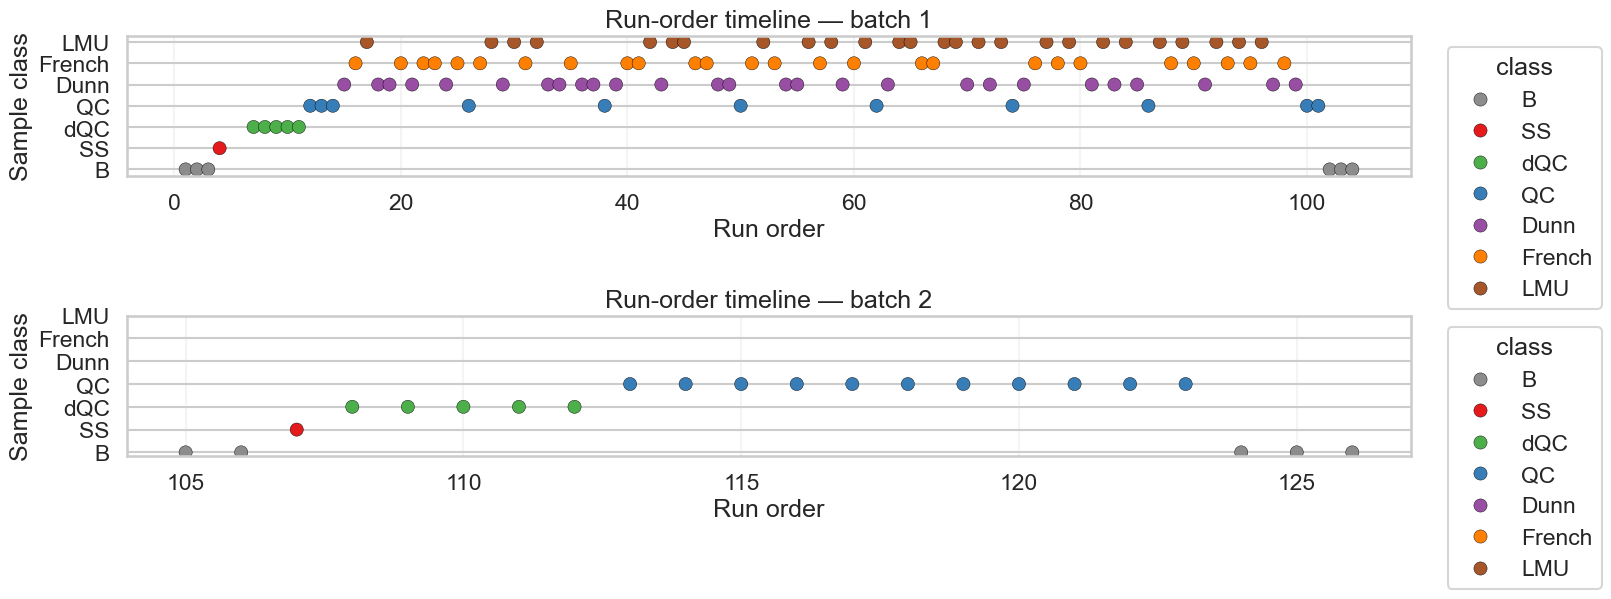

In [4]:
fig = plot_run_timeline(acquisition_list)
plt.show()

### Step 2 — Compute sample-level global signal metrics
We now summarize each sample by:
- total signal across all features,
- number of detected features,
- fraction of zero-valued features,
- and correlation to the median profile of its own class.

These summaries help identify obvious outliers, global class differences, and potential run-order drift before moving to feature-level analysis.

In [5]:
sample_metrics = compute_sample_metrics(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    detection_threshold=0.0,  # for now, Step 2 uses a simple non-zero definition
)

sample_metrics = flag_sample_outliers(sample_metrics)

display(sample_metrics.head())
display(summarise_sample_metrics(sample_metrics))
display(
    sample_metrics.loc[sample_metrics["any_outlier_flag"]]
    .sort_values(["batch", "order"])
    .reset_index(drop=True)
)

,sample,total_signal,log10_total_signal_plus1,detected_features,detection_rate,zero_fraction,mean_feature_intensity_nonzero,class,id,order,batch,spearman_corr_to_class_median,log10_total_signal_plus1_robust_z,detected_features_robust_z,zero_fraction_robust_z,spearman_corr_to_class_median_robust_z,outlier_total_signal,outlier_detected_features,outlier_zero_fraction,outlier_class_profile,any_outlier_flag
0,20241106-297-Blank1,28.531648,1.470288,6,0.023810,0.976190,4.755275,B,20241106-297-Blank1,1,1,NaN,-52.039039,-82.28900,82.28900,NaN,True,True,True,False,True
1,20241106-297-Blank2,29.551665,1.485035,6,0.023810,0.976190,4.925277,B,20241106-297-Blank2,2,1,NaN,-51.864247,-82.28900,82.28900,NaN,True,True,True,False,True
2,20241106-297-Blank3,63.799221,1.811570,9,0.035714,0.964286,7.088802,B,20241106-297-Blank3,3,1,NaN,-47.993972,-81.27725,81.27725,NaN,True,True,True,False,True
3,20241106-297-Experimental_Blank,241703.338905,5.383284,64,0.253968,0.746032,3776.614670,SS,20241106-297-Experimental_Blank,4,1,0.975795,-5.659998,-62.72850,62.72850,NaN,True,True,True,False,True
4,20241106-297-Diluted-QC1,557833.773434,5.746506,251,0.996032,0.003968,2222.445312,dQC,20241106-297-Diluted-QC1,7,1,0.988398,-1.354896,0.33725,-0.33725,NaN,False,False,False,False,False


,batch,class,n_samples,median_total_signal,mean_total_signal,median_detected_features,mean_detected_features,median_zero_fraction,mean_corr_to_class_median
0,1,B,6,24.680257,26.663723,5.5,4.833333,0.978175,NaN
1,1,Dunn,27,813127.569783,815796.883189,251.0,250.407407,0.003968,0.983770
2,1,French,26,768329.059938,774511.868791,252.0,251.500000,0.000000,0.984857
3,1,LMU,26,741400.934603,747289.831068,249.0,248.384615,0.011905,0.969052
4,1,QC,11,773821.399796,795185.964492,251.0,250.545455,0.003968,0.865408
5,1,SS,1,241703.338905,241703.338905,64.0,64.000000,0.746032,0.975795
6,1,dQC,5,633451.301376,663226.167046,251.0,250.200000,0.003968,0.967417
7,2,B,5,237.807278,279.129831,9.0,8.800000,0.964286,NaN
8,2,QC,11,10735.503398,11402.702554,77.0,73.909091,0.694444,0.227225
9,2,SS,1,12718.923203,12718.923203,15.0,15.000000,0.940476,0.392210


,sample,total_signal,log10_total_signal_plus1,detected_features,detection_rate,zero_fraction,mean_feature_intensity_nonzero,class,id,order,batch,spearman_corr_to_class_median,log10_total_signal_plus1_robust_z,detected_features_robust_z,zero_fraction_robust_z,spearman_corr_to_class_median_robust_z,outlier_total_signal,outlier_detected_features,outlier_zero_fraction,outlier_class_profile,any_outlier_flag
0,20241106-297-Blank1,28.531648,1.470288,6,0.023810,0.976190,4.755275,B,20241106-297-Blank1,1,1,NaN,-52.039039,-82.28900,82.28900,NaN,True,True,True,False,True
1,20241106-297-Blank2,29.551665,1.485035,6,0.023810,0.976190,4.925277,B,20241106-297-Blank2,2,1,NaN,-51.864247,-82.28900,82.28900,NaN,True,True,True,False,True
2,20241106-297-Blank3,63.799221,1.811570,9,0.035714,0.964286,7.088802,B,20241106-297-Blank3,3,1,NaN,-47.993972,-81.27725,81.27725,NaN,True,True,True,False,True
3,20241106-297-Experimental_Blank,241703.338905,5.383284,64,0.253968,0.746032,3776.614670,SS,20241106-297-Experimental_Blank,4,1,0.975795,-5.659998,-62.72850,62.72850,NaN,True,True,True,False,True
4,20241106-297-Blank4,20.828866,1.339031,5,0.019841,0.980159,4.165773,B,20241106-297-Blank4,102,1,NaN,-53.594766,-82.62625,82.62625,NaN,True,True,True,False,True
5,20241106-297-Blank5,7.272072,0.917614,1,0.003968,0.996032,7.272072,B,20241106-297-Blank5,103,1,NaN,-58.589635,-83.97525,83.97525,NaN,True,True,True,False,True
6,20241106-297-Blank6,9.998865,1.041348,2,0.007937,0.992063,4.999432,B,20241106-297-Blank6,104,1,NaN,-57.123076,-83.63800,83.63800,NaN,True,True,True,False,True
7,20241113-300-Blank1,79.512487,1.905863,9,0.035714,0.964286,8.834721,B,20241113-300-Blank1,105,2,NaN,-46.876353,-81.27725,81.27725,NaN,True,True,True,False,True
8,20241113-300-Blank2,411.902597,2.615848,11,0.043651,0.956349,37.445691,B,20241113-300-Blank2,106,2,NaN,-38.461218,-80.60275,80.60275,NaN,True,True,True,False,True
9,20241113-300-Experimental_Blank,12718.923203,4.104484,15,0.059524,0.940476,847.928214,SS,20241113-300-Experimental_Blank,107,2,0.392210,-20.817055,-79.25375,79.25375,NaN,True,True,True,False,True


C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:301: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:313: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


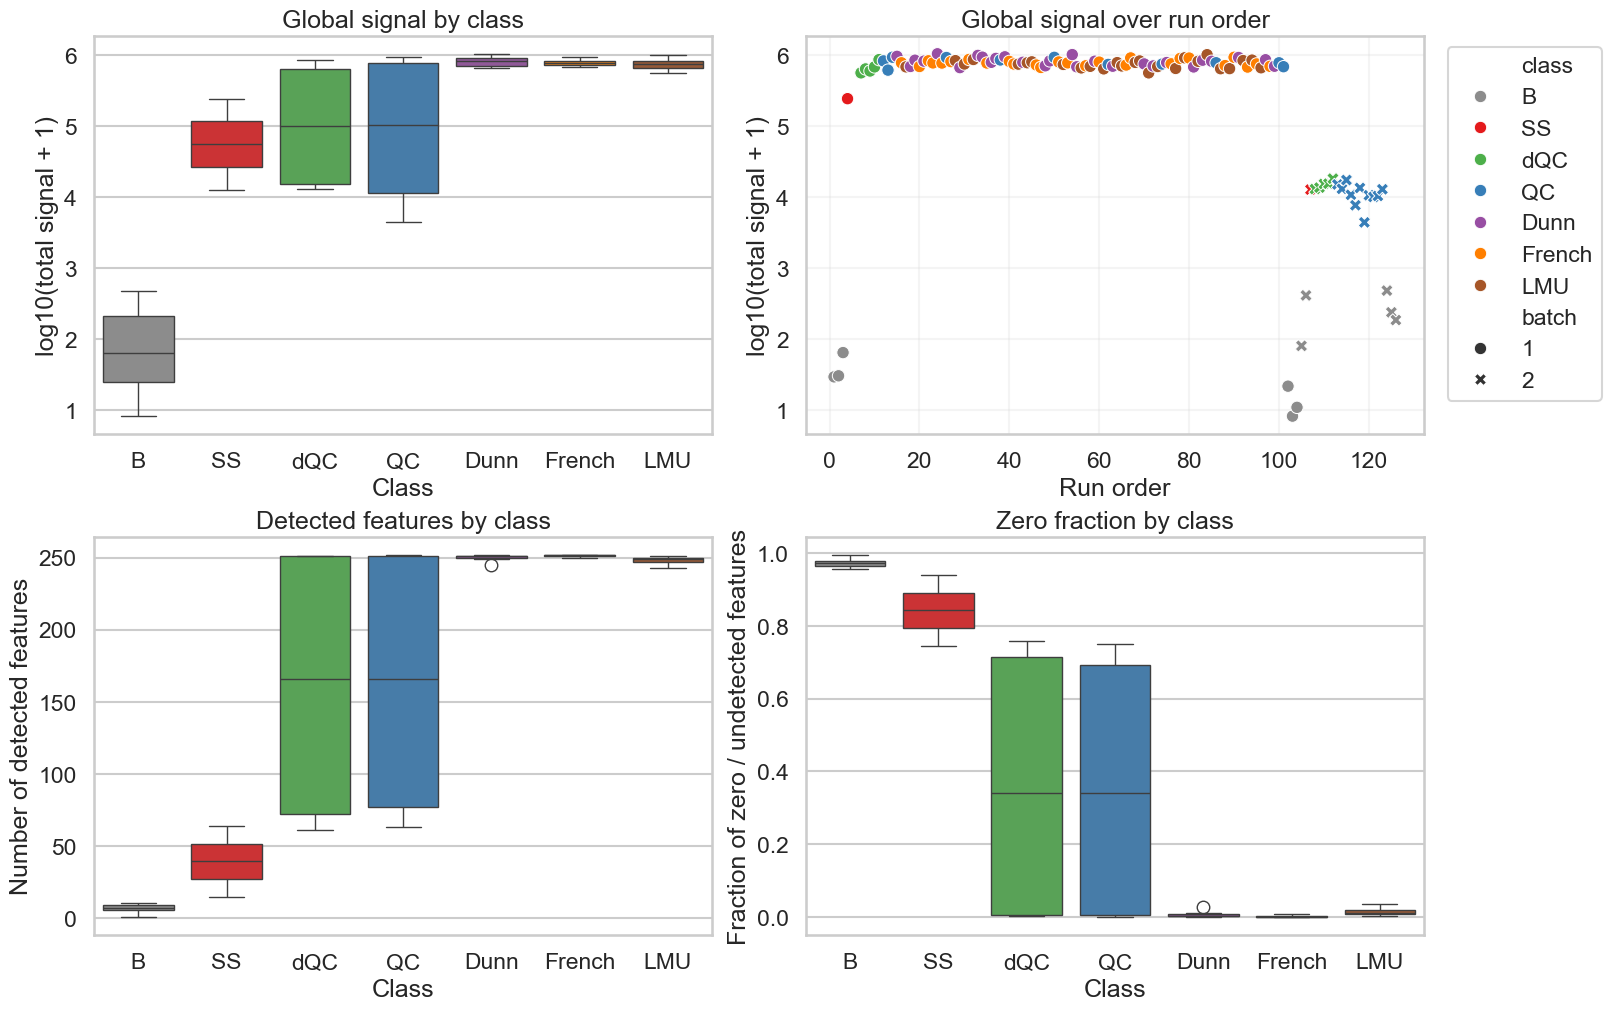

In [6]:
fig = plot_global_signal_health(sample_metrics)
plt.show()

## Interpretation — global signal, class behavior, and sample-level outliers

At the sample level, the classes separate in a biologically and technically meaningful way.

Blanks have very low total signal and almost no detected features, which is expected. The experimental blank (`SS`) is higher than true blanks, again expected, because it contains exogenous standards and serves as a system-suitability sample rather than a pure contamination control.

Within batch 1, the biological classes (`Dunn`, `French`, `LMU`) all have very high total signal and near-complete feature detection. Batch 1 `QC` and `dQC` are close to the biological samples, which is also expected because pooled QC material is a mixture of the study samples. The diluted QC is slightly lower on average than QC / biology, which is consistent with dilution.

The major anomaly appears in batch 2: both `QC` and `dQC` have much lower total signal and far fewer detected features than batch 1. This is not a subtle drift; it is a large batch-level drop in signal intensity and feature support.

The automatic outlier table therefore needs interpretation, not blind filtering. Blanks and experimental blanks are flagged because they are intentionally different from biological samples, not because they are erroneous. In the biological-only PCA, only a small number of batch 1 biological samples look moderately unusual, so there is no evidence of a broad biological sample-quality collapse.

**Conclusion:** batch 1 looks usable and internally coherent; batch 2 is on a clearly different technical scale.

In [7]:
from src.eda import (
    audit_task1_inputs,
    sample_inventory_table,
    plot_run_timeline,
    compute_sample_metrics,
    flag_sample_outliers,
    plot_global_signal_health,
    summarise_sample_metrics,
    compute_qc_feature_metrics,
    summarise_qc_metrics,
    compute_qc_sample_correlations,
    plot_qc_correlation_heatmap,
    plot_qc_cv_distribution,
    compute_qc_pca,
    plot_qc_pca,
    plot_top_qc_drift_features,
    plot_positive_intensity_distributions,
    threshold_sensitivity_table,
    compute_feature_detection_metrics,
    plot_detection_rate_by_class,
    plot_detection_landscape,
    compute_contamination_metrics,
    plot_contamination_overview,
    compute_blank_carryover_proxy,
    match_exogenous_standards,
    compute_standard_tracking,
    summarise_standard_tracking,
    plot_standard_tracking,
)

## Step 3 — QC-centered stability analysis

We use repeated QC and dQC injections as a technical reference to quantify measurement stability.
This step focuses on:
- feature-wise QC coefficient of variation (CV),
- sample-sample correlation among QCs,
- multivariate QC structure over run order,
- and feature-level drift proxies with respect to run order.

In [8]:
QC_CLASSES = ("QC", "dQC")
QC_CV_THRESHOLD = 30.0

qc_feature_metrics = compute_qc_feature_metrics(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    feature_metadata=feature_metadata,
    qc_classes=QC_CLASSES,
    detection_threshold=0.0,
)

qc_summary = summarise_qc_metrics(
    qc_feature_metrics=qc_feature_metrics,
    cv_threshold=QC_CV_THRESHOLD,
)

qc_corr, qc_sample_info = compute_qc_sample_correlations(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    qc_classes=QC_CLASSES,
)

qc_pca_scores, qc_pca_explained = compute_qc_pca(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    qc_classes=QC_CLASSES,
)

display(qc_summary.to_frame())
display(qc_feature_metrics.head(10))
display(
    qc_feature_metrics.sort_values("qc_cv_pct", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
display(qc_sample_info.head())
display(qc_pca_scores.head())

C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:424: RuntimeWarning: invalid value encountered in divide
  out[f"qc_cv_pct_batch{batch}"] = np.where(batch_mean > 0, 100.0 * batch_std / batch_mean, np.nan)


,value
n_features,252.000000
median_qc_cv_pct,107.855573
mean_qc_cv_pct,112.568026
n_features_qc_cv_below_threshold,0.000000
fraction_features_qc_cv_below_threshold,0.000000
median_qc_detection_rate,0.562500


,feature,n_qc_samples,qc_detection_rate,qc_mean_intensity,qc_median_intensity,qc_std_intensity,qc_cv_pct,qc_mean_intensity_batch1,qc_cv_pct_batch1,qc_mean_intensity_batch2,qc_cv_pct_batch2,qc_order_spearman_rho,qc_order_spearman_abs,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-003,32,1.00000,4304.957220,3917.181350,1427.167490,33.151723,3676.387148,8.424932,4933.527292,36.656859,0.298021,0.298021,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
1,FT-001,32,1.00000,2538.171460,2359.549403,976.860464,38.486780,2225.536944,7.934346,2850.805976,46.170113,0.228006,0.228006,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
2,FT-081,32,1.00000,944.874841,940.233993,424.787159,44.956976,1235.966330,24.344558,653.783352,48.758229,-0.502933,0.502933,1225.305159,1225.383205,1225.241092,0.035400,1299.089715,1313.362815,1301.245625,1296.385905,1286.553745,1.277793
3,FT-000,32,1.00000,1588.179590,1535.529676,715.071911,45.024625,1524.569351,8.530528,1651.789828,61.477512,-0.133431,0.133431,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
4,FT-175,32,1.00000,669.804616,601.605789,527.767361,78.794226,1152.152452,21.926185,187.456781,66.387893,-0.692449,0.692449,844.087034,844.132378,844.041375,0.024632,962.997451,978.576151,965.591400,960.298923,948.830658,1.376532
5,FT-083,32,1.00000,1792.480183,1580.357877,1470.822093,82.055138,3183.904455,16.514410,401.055911,63.139653,-0.662757,0.662757,1224.804265,1224.876042,1224.740236,0.034634,1299.279167,1319.738579,1301.371106,1296.826881,1284.575737,1.191958
6,FT-248,32,1.00000,447.535867,331.006166,376.523658,84.132622,782.343776,28.139995,112.727958,65.102683,-0.640762,0.640762,925.136196,925.183723,925.091923,0.024345,1057.851741,1064.927980,1060.490508,1055.485902,1046.123490,1.362119
7,FT-196,32,1.00000,698.211029,553.457513,606.667404,86.888831,1255.000236,23.657012,141.421822,74.553057,-0.655792,0.655792,1079.216602,1079.279903,1079.162473,0.030930,1212.162690,1228.100009,1214.808575,1209.527818,1198.610528,1.253577
8,FT-215,32,0.84375,18.584512,10.105804,17.559376,94.483925,33.187575,39.175447,3.981449,91.428034,-0.771577,0.771577,1089.027713,1089.084097,1088.973816,0.031877,1422.771628,1429.112757,1425.693322,1419.283552,1415.301223,1.443795
9,FT-232,32,1.00000,530.022638,339.145744,529.580740,99.916627,1013.021818,28.050424,47.023458,73.110061,-0.664589,0.664589,1151.762506,1151.827813,1151.700332,0.033736,1245.240779,1258.885828,1247.717035,1242.597249,1232.076402,1.318578


,feature,n_qc_samples,qc_detection_rate,qc_mean_intensity,qc_median_intensity,qc_std_intensity,qc_cv_pct,qc_mean_intensity_batch1,qc_cv_pct_batch1,qc_mean_intensity_batch2,qc_cv_pct_batch2,qc_order_spearman_rho,qc_order_spearman_abs,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-173,32,0.46875,1072.336656,0.000000,4021.051255,374.980304,2140.430822,260.047054,4.242490,231.620522,-0.632418,0.632418,887.645627,887.678467,887.600614,0.023116,639.907400,651.919421,643.893839,635.770774,634.336944,1.909012
1,FT-132,32,0.53125,91.700575,18.296741,249.549050,272.134662,183.035962,181.942435,0.365188,400.000000,-0.807984,0.807984,1088.354986,1088.423559,1088.296632,0.034139,1438.809837,1443.922299,1441.288860,1435.897107,1431.058061,1.160635
2,FT-141,32,0.50000,444.298491,30.820044,1128.896094,254.085062,888.596981,167.398515,0.000000,NaN,-0.787903,0.787903,1223.295151,1223.368163,1223.223485,0.037032,1273.683493,1281.605744,1276.293562,1270.708652,1268.696712,1.306203
3,FT-199,32,0.90625,104.093348,31.440924,253.742615,243.764487,200.389576,167.921484,7.797120,90.987031,-0.733407,0.733407,1223.794330,1223.847789,1223.732886,0.032090,1273.446642,1280.967369,1276.269530,1270.774468,1268.557217,1.287028
4,FT-013,32,0.43750,180.579324,0.000000,438.271516,242.703043,360.905665,158.590271,0.252984,400.000000,-0.699498,0.699498,1210.827050,1210.896593,1210.757497,0.034829,899.723393,910.341839,902.505364,896.739952,892.597835,1.520345
5,FT-126,32,0.75000,58.840599,12.102811,129.663155,220.363418,113.854181,147.679487,3.827016,112.594039,-0.706708,0.706708,1089.358935,1089.414818,1089.302112,0.031465,1439.054183,1443.902579,1441.775372,1435.925620,1431.709453,1.587631
6,FT-079,32,0.56250,43.035127,10.824530,82.591142,191.915647,85.729076,117.851727,0.341178,301.311475,-0.726326,0.726326,1077.209362,1077.278063,1077.145710,0.033821,1186.459409,1193.399425,1189.507364,1183.667336,1179.035132,1.460963
7,FT-174,32,0.53125,18.969562,3.190865,36.122853,190.425338,37.484657,118.221798,0.454467,275.182755,-0.758452,0.758452,1210.830470,1210.900611,1210.763404,0.039324,928.694830,936.654435,933.254237,923.405274,921.758979,2.229371
8,FT-246,32,0.37500,95.605104,0.000000,173.926269,181.921531,191.210208,108.471098,0.000000,NaN,-0.563585,0.563585,886.640677,886.688516,886.593355,0.025146,640.780607,655.650127,645.218960,636.134805,634.661402,1.843087
9,FT-183,32,0.96875,203.332574,82.280417,358.230244,176.179467,385.206653,114.439764,21.458495,82.783940,-0.673021,0.673021,1026.192891,1026.253869,1026.133604,0.029959,1107.040420,1118.291007,1109.781604,1104.496140,1102.969804,1.482488


,sample,batch,class,order
0,20241106-297-Diluted-QC1,1,dQC,7
1,20241106-297-Diluted-QC2,1,dQC,8
2,20241106-297-Diluted-QC3,1,dQC,9
3,20241106-297-Diluted-QC4,1,dQC,10
4,20241106-297-Diluted-QC5,1,dQC,11


,sample,batch,class,order,PC1,PC2
0,20241106-297-Diluted-QC1,1,dQC,7,12.790860,0.164943
1,20241106-297-Diluted-QC2,1,dQC,8,13.740584,-0.344269
2,20241106-297-Diluted-QC3,1,dQC,9,13.959384,0.214173
3,20241106-297-Diluted-QC4,1,dQC,10,14.690870,-0.529868
4,20241106-297-Diluted-QC5,1,dQC,11,16.056929,0.014067


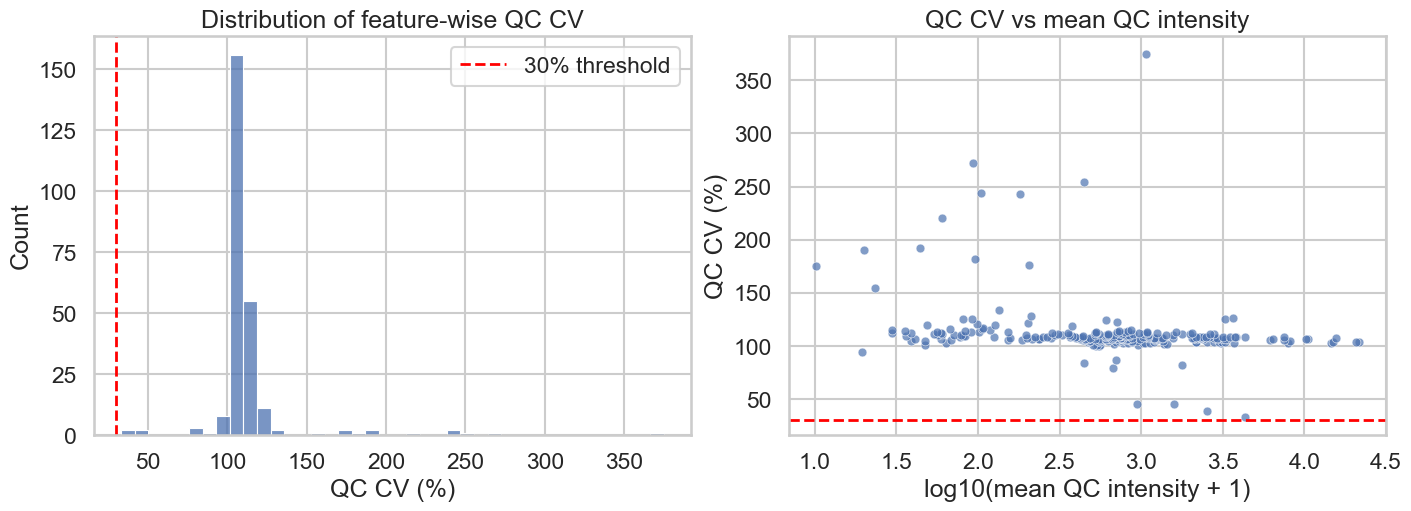

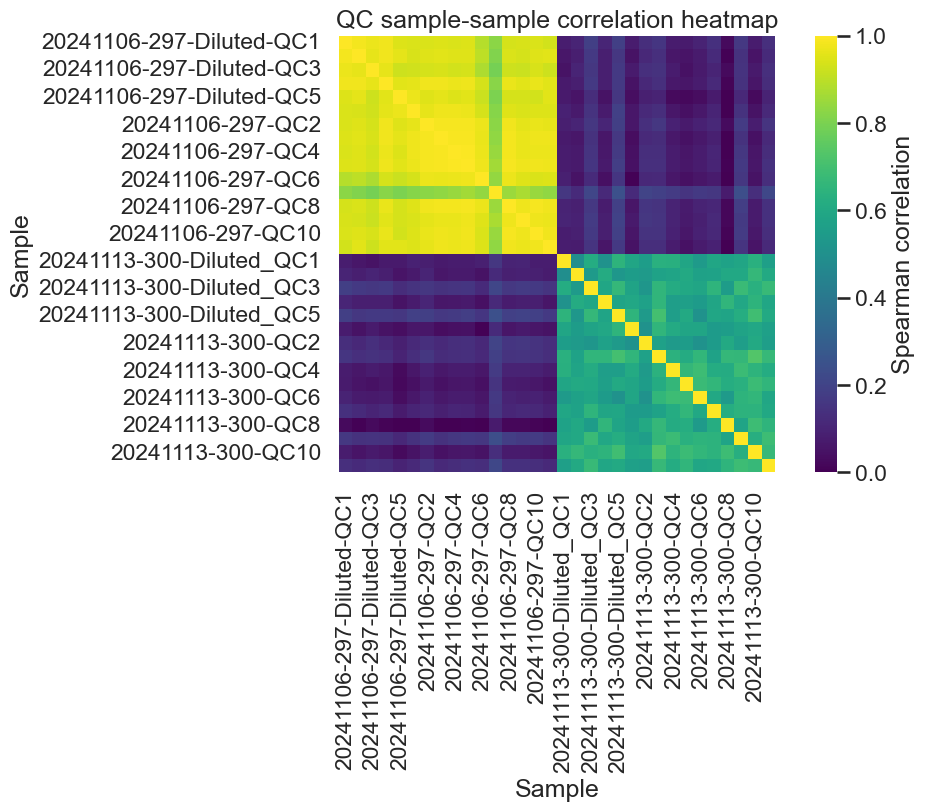

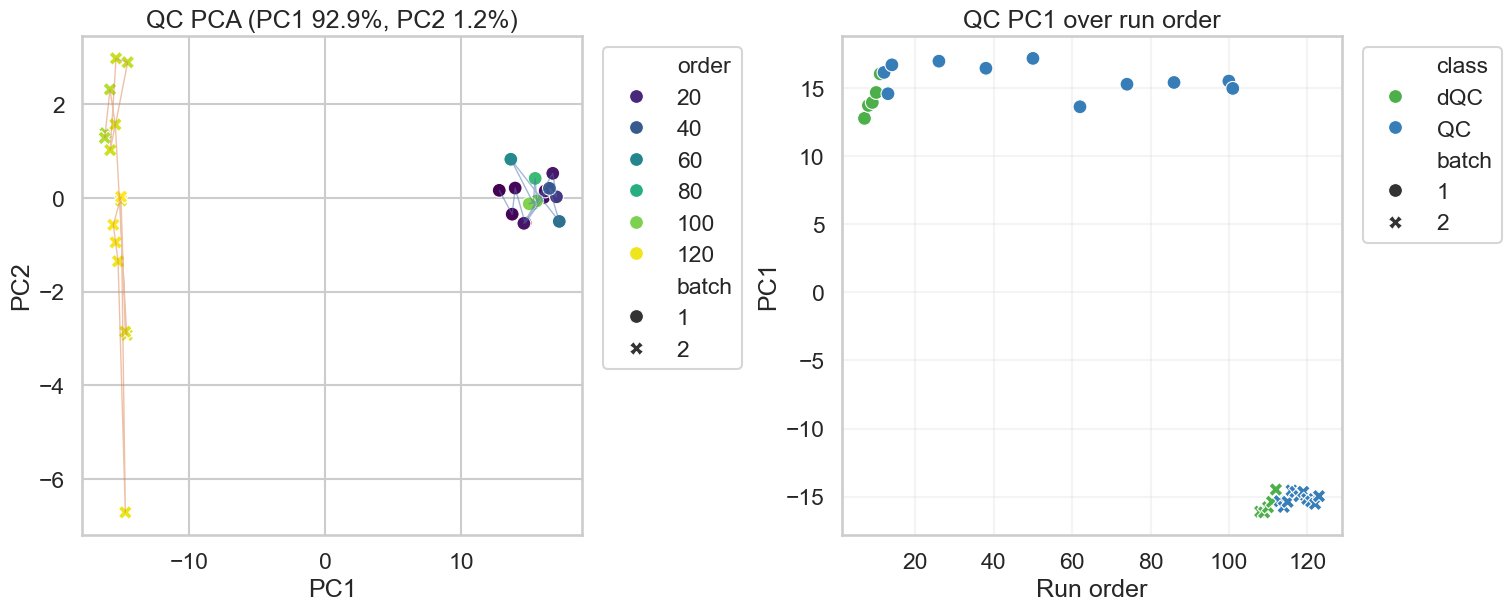

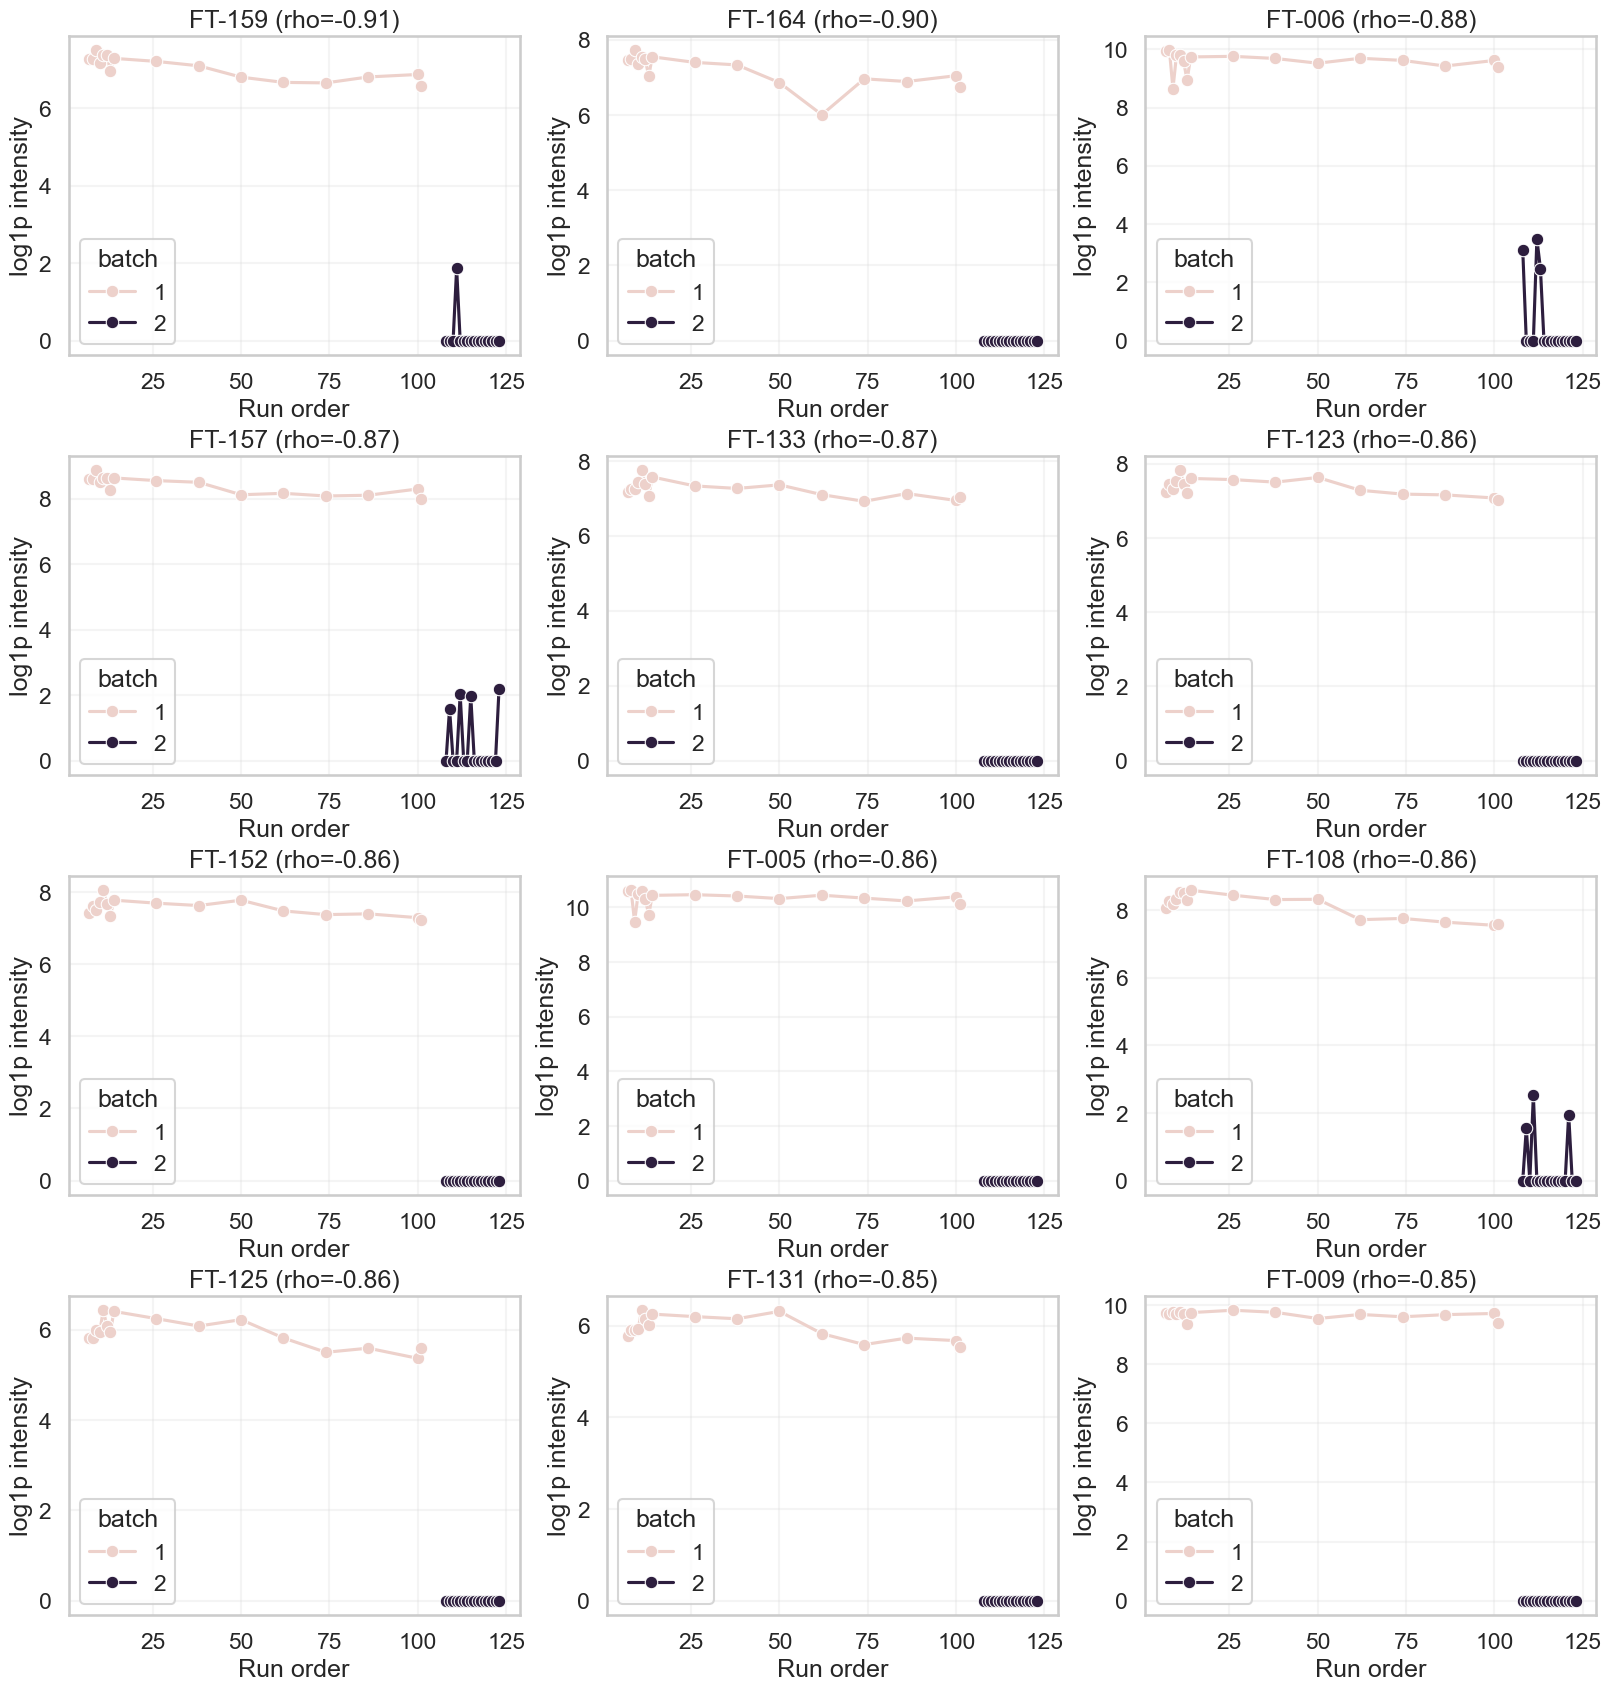

In [9]:
fig = plot_qc_cv_distribution(qc_feature_metrics, cv_threshold=QC_CV_THRESHOLD)
plt.show()

fig = plot_qc_correlation_heatmap(qc_corr, qc_sample_info)
plt.show()

fig = plot_qc_pca(qc_pca_scores, qc_pca_explained)
plt.show()

fig = plot_top_qc_drift_features(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    qc_feature_metrics=qc_feature_metrics,
    qc_classes=QC_CLASSES,
    top_n=12,
)
plt.show()

## Interpretation — QC reproducibility and measurement stability

The QC diagnostics show a strong split between *within-batch* behavior and *between-batch* behavior.

The pooled QC summary across both batches is poor: the median feature-wise QC CV is about 108%, no feature satisfies the <30% QC-CV target, and the QC heatmap separates almost perfectly into two blocks corresponding to batch 1 and batch 2. QC PCA tells the same story: the first principal component explains almost all variation and primarily separates the two batches, not a smooth gradual drift.

This means that the dominant technical effect is **batch regime change**, not mild within-batch drift. Many of the strongest “drift” features are simply features that are strong in batch 1 and near-zero in batch 2.

That said, batch 1 by itself looks much more reasonable. In batch 1, QC and dQC signals are strong, repeatedly detected, and broadly stable over run order. So the poor all-batch QC metrics do **not** imply that batch 1 is unusable; they imply that **batch 1 and batch 2 should not be pooled as if they were equivalent technical replicates**.

**Conclusion:** measurement stability is poor across the full experiment, but acceptable enough within batch 1 to continue biomarker discovery there. Batch 2 behaves like a failed or heavily shifted technical batch.

## Step 4 — Detection landscape and missingness

We now examine detection support across features, RT/m/z space, and classes.
We first compare several candidate intensity thresholds and then compute feature-wise detection rates using a selected working threshold.

In [10]:
threshold_grid = (0.0, 1.0, 10.0, 100.0, 1000.0)

threshold_table = threshold_sensitivity_table(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    thresholds=threshold_grid,
)

display(threshold_table)

,class,batch,mean,median,min,max,threshold
0,B,1,0.019180,0.021825,0.003968,0.035714,0.0
1,Dunn,1,0.993680,0.996032,0.972222,1.000000,0.0
2,French,1,0.998016,1.000000,0.992063,1.000000,0.0
3,LMU,1,0.985653,0.988095,0.964286,0.996032,0.0
4,QC,1,0.994228,0.996032,0.984127,1.000000,0.0
5,SS,1,0.253968,0.253968,0.253968,0.253968,0.0
6,dQC,1,0.992857,0.996032,0.984127,0.996032,0.0
7,B,2,0.034921,0.035714,0.027778,0.043651,0.0
8,QC,2,0.293290,0.305556,0.250000,0.333333,0.0
9,SS,2,0.059524,0.059524,0.059524,0.059524,0.0


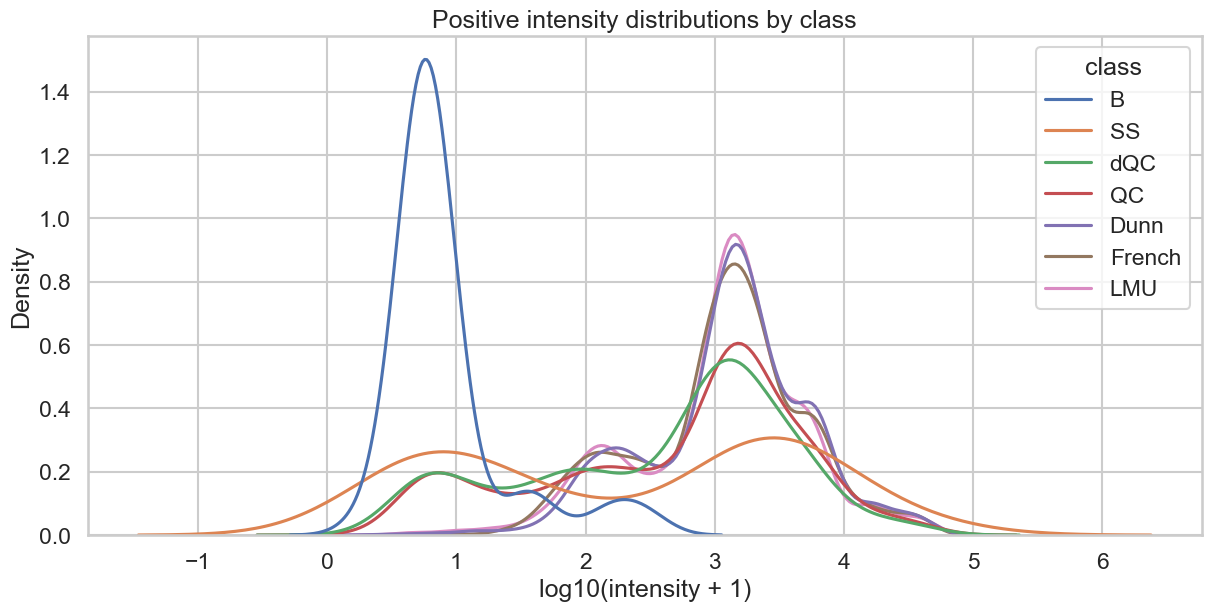

In [11]:
fig = plot_positive_intensity_distributions(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
)
plt.show()

In [12]:
# Working threshold for the rest of Step 4–6.
# Keep this explicit so we can revisit it later if needed.
DETECTION_THRESHOLD = 0.0

feature_detection_metrics = compute_feature_detection_metrics(
    data_matrix=data_matrix,
    feature_metadata=feature_metadata,
    acquisition_list=acquisition_list,
    detection_threshold=DETECTION_THRESHOLD,
)

display(feature_detection_metrics.head(10))
display(
    feature_detection_metrics[
        [
            "feature",
            "mz",
            "rt",
            "detection_rate__all",
            "detection_rate__blank",
            "detection_rate__qc_like",
            "detection_rate__biological",
        ]
    ].head(15)
)

,feature,detection_rate__all,detection_rate__B,detection_rate__SS,detection_rate__dQC,detection_rate__QC,detection_rate__Dunn,detection_rate__French,detection_rate__LMU,detection_rate__biological,detection_rate__qc_like,detection_rate__blank,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-001,0.951613,0.454545,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.454545,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
1,FT-000,0.943548,0.363636,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.363636,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
2,FT-003,0.943548,0.363636,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.363636,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
3,FT-084,0.911290,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.000000,1224.297876,1224.366749,1224.236563,0.035584,1257.737601,1268.237524,1259.574526,1255.568365,1246.972210,1.100626
4,FT-218,0.911290,0.090909,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.090909,945.149953,945.200369,945.098867,0.026011,1013.699715,1026.837697,1016.552909,1010.915967,999.975636,1.416637
5,FT-248,0.911290,0.181818,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.181818,925.136196,925.183723,925.091923,0.024345,1057.851741,1064.927980,1060.490508,1055.485902,1046.123490,1.362119
6,FT-025,0.903226,0.000000,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.000000,843.080106,843.127763,843.038162,0.024763,963.243959,988.175199,965.763907,960.736200,947.918079,1.304724
7,FT-035,0.903226,0.090909,0.5,0.9,1.0,1.0,1.0,1.0,1.0,0.96875,0.090909,924.125817,924.180160,924.077759,0.027241,1057.660785,1064.725997,1060.338482,1055.031178,1043.029404,1.238042
8,FT-036,0.903226,0.000000,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.000000,924.125833,924.179885,924.080169,0.026461,1071.432189,1092.473555,1073.928504,1068.937951,1064.729301,1.246331
9,FT-085,0.903226,0.090909,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.00000,0.090909,1224.297597,1224.367680,1224.236097,0.033889,1299.562235,1326.700804,1301.653365,1297.271576,1284.415723,1.108348


,feature,mz,rt,detection_rate__all,detection_rate__blank,detection_rate__qc_like,detection_rate__biological
0,FT-001,357.109546,543.839157,0.951613,0.454545,1.00000,1.0
1,FT-000,359.108768,543.846374,0.943548,0.363636,1.00000,1.0
2,FT-003,355.111928,543.995269,0.943548,0.363636,1.00000,1.0
3,FT-084,1224.297876,1257.737601,0.911290,0.000000,1.00000,1.0
4,FT-218,945.149953,1013.699715,0.911290,0.090909,1.00000,1.0
5,FT-248,925.136196,1057.851741,0.911290,0.181818,1.00000,1.0
6,FT-025,843.080106,963.243959,0.903226,0.000000,1.00000,1.0
7,FT-035,924.125817,1057.660785,0.903226,0.090909,0.96875,1.0
8,FT-036,924.125833,1071.432189,0.903226,0.000000,1.00000,1.0
9,FT-085,1224.297597,1299.562235,0.903226,0.090909,1.00000,1.0


C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:816: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


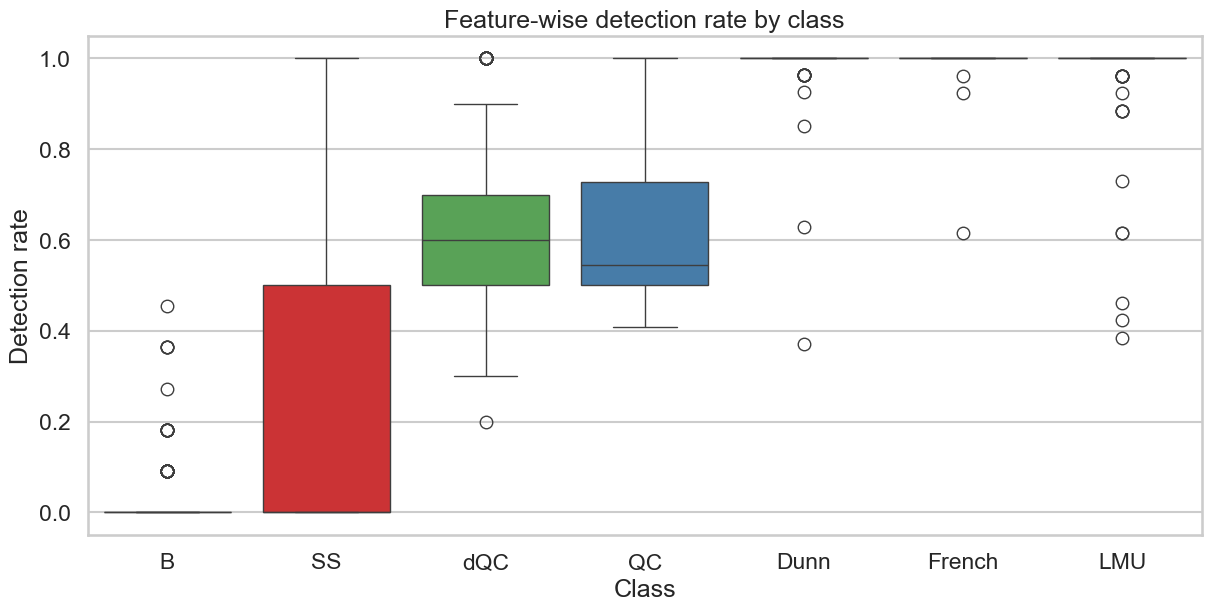

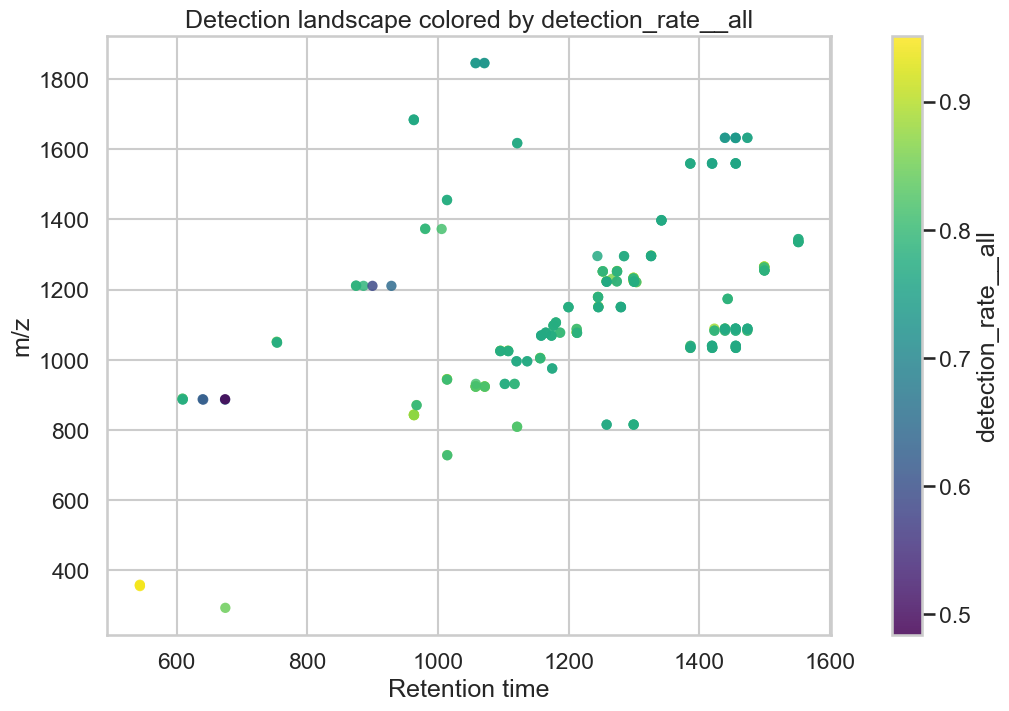

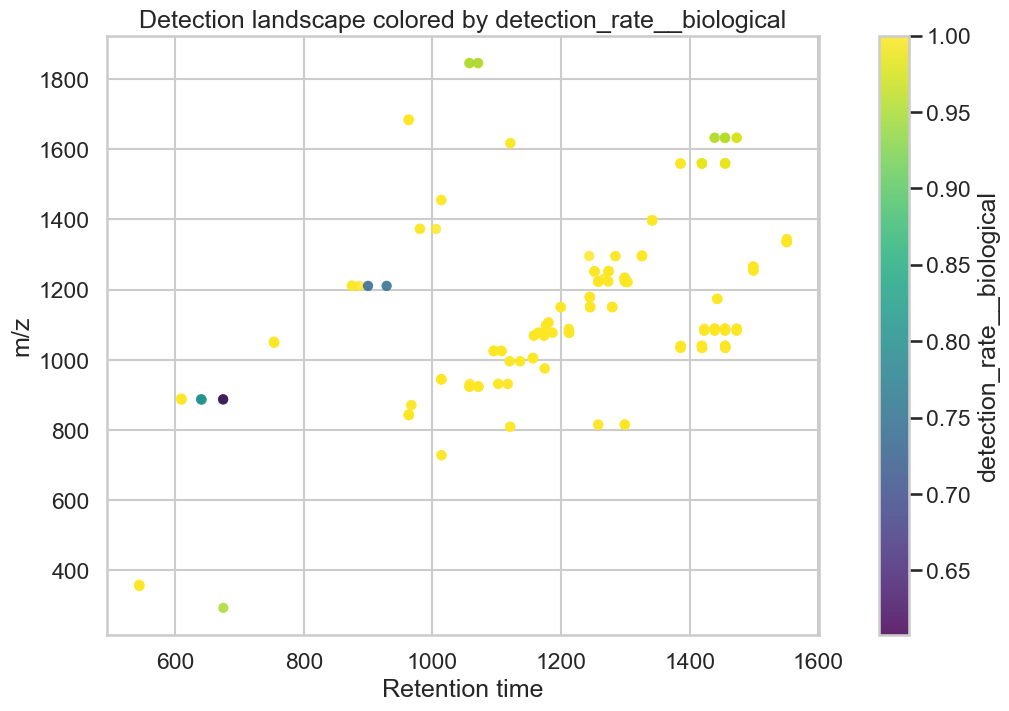

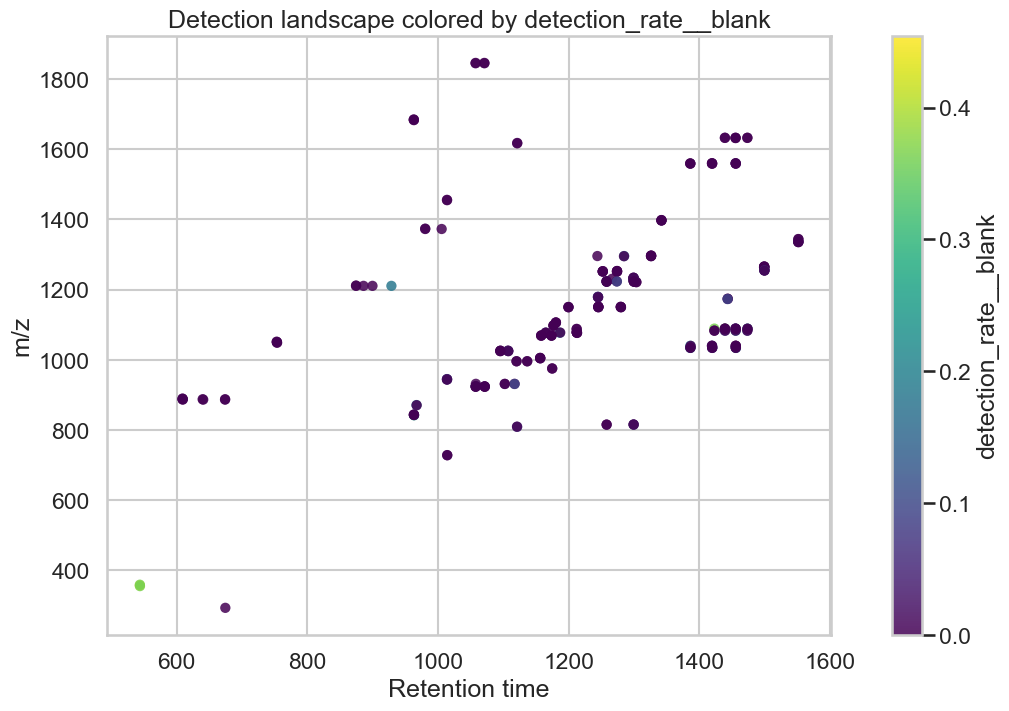

In [13]:
fig = plot_detection_rate_by_class(feature_detection_metrics)
plt.show()

fig = plot_detection_landscape(feature_detection_metrics, rate_col="detection_rate__all")
plt.show()

fig = plot_detection_landscape(feature_detection_metrics, rate_col="detection_rate__biological")
plt.show()

fig = plot_detection_landscape(feature_detection_metrics, rate_col="detection_rate__blank")
plt.show()

## Interpretation — detection support across RT, m/z, and classes

Using a zero threshold for the first exploratory pass is acceptable because it preserves the full structure of the data, but the threshold-sensitivity table is more informative than the raw zero-threshold view.

At thresholds 0 and 1, batch 1 biological samples and batch 1 QC-like samples have almost complete support. Even at a threshold of 10, batch 1 biological classes still retain very high detection support, while blanks collapse toward zero and batch 2 technical samples remain weak. This suggests that a small positive threshold such as 10 is a reasonable later choice if we want to suppress background without materially harming the batch 1 biological signal.

The feature-level detection plots show that most biologically relevant features are detected consistently in the biological classes, while blanks have very low support. The main technical contrast is again batch 2: its QC-like samples detect far fewer features than batch 1, especially once the threshold becomes more stringent.

The RT / m/z landscape also suggests that the signal is not randomly scattered. Most strong features lie in a structured region of the chromatographic space, with only a smaller set of low-mass / early-RT features behaving more like weak or background signals.

**Conclusion:** detection support in batch 1 is strong and compatible with later feature filtering. QC-like classes behave as expected in batch 1, but not in batch 2.

## Step 5 — Contamination and blank behavior

We compare blank, QC-like, and biological samples feature-wise to identify signals that are blank-dominant and therefore plausible contaminants or background artifacts.
We also compute a simple blank carryover proxy based on the preceding injection within each batch.

In [14]:
contamination_metrics = compute_contamination_metrics(
    data_matrix=data_matrix,
    feature_metadata=feature_metadata,
    acquisition_list=acquisition_list,
    detection_threshold=DETECTION_THRESHOLD,
    blank_ratio_threshold=1.0,
    min_blank_detection_rate=0.1,
)

blank_carryover_proxy = compute_blank_carryover_proxy(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
)

display(contamination_metrics.head(10))
display(
    contamination_metrics.sort_values("log10_blank_to_bio_ratio", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(blank_carryover_proxy.head(20))

,feature,blank_mean_intensity,blank_median_intensity,blank_detection_rate,qc_mean_intensity,qc_median_intensity,qc_detection_rate,bio_mean_intensity,bio_median_intensity,bio_detection_rate,blank_to_qc_ratio,blank_to_bio_ratio,log10_blank_to_qc_ratio,log10_blank_to_bio_ratio,blank_dominant_flag,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-215,1.910710,0.0,0.363636,18.584512,10.105804,0.84375,36.013865,34.986762,1.000000,0.148623,0.078638,-0.827914,-1.104365,False,1089.027713,1089.084097,1088.973816,0.031877,1422.771628,1429.112757,1425.693322,1419.283552,1415.301223,1.443795
1,FT-174,0.967837,0.0,0.181818,18.969562,3.190865,0.53125,49.213280,12.789079,0.746835,0.098542,0.039190,-1.006379,-1.406829,False,1210.830470,1210.900611,1210.763404,0.039324,928.694830,936.654435,933.254237,923.405274,921.758979,2.229371
2,FT-251,0.000000,0.0,0.000000,9.210994,0.000000,0.34375,25.889987,6.363869,0.607595,0.097934,0.037189,-1.009068,-1.429591,False,887.647221,887.681260,887.589508,0.025487,674.305633,681.823713,677.574583,670.838965,666.880031,1.658414
3,FT-079,1.391524,0.0,0.181818,43.035127,10.824530,0.56250,76.873448,66.683905,1.000000,0.054309,0.030710,-1.265125,-1.512715,False,1077.209362,1077.278063,1077.145710,0.033821,1186.459409,1193.399425,1189.507364,1183.667336,1179.035132,1.460963
4,FT-216,1.946361,0.0,0.363636,58.179541,30.057274,0.78125,121.223660,116.462451,1.000000,0.049787,0.024106,-1.302886,-1.617869,False,1089.030600,1089.095920,1088.972675,0.031323,1438.932118,1444.116680,1440.781202,1436.371539,1431.385181,1.168489
5,FT-001,48.332744,0.0,0.454545,2538.171460,2359.549403,1.00000,2230.623428,2233.979171,1.000000,0.019429,0.022106,-1.711557,-1.655486,False,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
6,FT-003,56.964631,0.0,0.363636,4304.957220,3917.181350,1.00000,3662.649152,3628.490842,1.000000,0.013461,0.015822,-1.870907,-1.800751,False,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
7,FT-245,0.539264,0.0,0.090909,46.345609,18.377667,0.81250,97.435227,93.149441,1.000000,0.032511,0.015637,-1.487967,-1.805838,False,1083.021308,1083.085385,1082.952438,0.036750,1473.133025,1482.318571,1476.168916,1469.970118,1466.929509,1.491661
8,FT-238,0.000000,0.0,0.000000,37.613167,18.060692,0.56250,69.264723,65.105015,1.000000,0.025898,0.014232,-1.586735,-1.846737,False,1083.342210,1083.415665,1083.287606,0.033256,1423.037280,1429.803952,1425.293978,1420.203550,1414.910642,1.413258
9,FT-249,0.000000,0.0,0.000000,28.722900,13.040867,0.50000,69.505563,68.855068,1.000000,0.033644,0.014183,-1.473091,-1.848223,False,1069.709184,1069.780424,1069.644986,0.032195,1158.068152,1163.637293,1160.474373,1155.226101,1149.945018,1.242633


,feature,blank_mean_intensity,blank_median_intensity,blank_detection_rate,qc_mean_intensity,qc_median_intensity,qc_detection_rate,bio_mean_intensity,bio_median_intensity,bio_detection_rate,blank_to_qc_ratio,blank_to_bio_ratio,log10_blank_to_qc_ratio,log10_blank_to_bio_ratio,blank_dominant_flag,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-215,1.910710,0.0,0.363636,18.584512,10.105804,0.84375,36.013865,34.986762,1.000000,0.148623,0.078638,-0.827914,-1.104365,False,1089.027713,1089.084097,1088.973816,0.031877,1422.771628,1429.112757,1425.693322,1419.283552,1415.301223,1.443795
1,FT-174,0.967837,0.0,0.181818,18.969562,3.190865,0.53125,49.213280,12.789079,0.746835,0.098542,0.039190,-1.006379,-1.406829,False,1210.830470,1210.900611,1210.763404,0.039324,928.694830,936.654435,933.254237,923.405274,921.758979,2.229371
2,FT-251,0.000000,0.0,0.000000,9.210994,0.000000,0.34375,25.889987,6.363869,0.607595,0.097934,0.037189,-1.009068,-1.429591,False,887.647221,887.681260,887.589508,0.025487,674.305633,681.823713,677.574583,670.838965,666.880031,1.658414
3,FT-079,1.391524,0.0,0.181818,43.035127,10.824530,0.56250,76.873448,66.683905,1.000000,0.054309,0.030710,-1.265125,-1.512715,False,1077.209362,1077.278063,1077.145710,0.033821,1186.459409,1193.399425,1189.507364,1183.667336,1179.035132,1.460963
4,FT-216,1.946361,0.0,0.363636,58.179541,30.057274,0.78125,121.223660,116.462451,1.000000,0.049787,0.024106,-1.302886,-1.617869,False,1089.030600,1089.095920,1088.972675,0.031323,1438.932118,1444.116680,1440.781202,1436.371539,1431.385181,1.168489
5,FT-001,48.332744,0.0,0.454545,2538.171460,2359.549403,1.00000,2230.623428,2233.979171,1.000000,0.019429,0.022106,-1.711557,-1.655486,False,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
6,FT-003,56.964631,0.0,0.363636,4304.957220,3917.181350,1.00000,3662.649152,3628.490842,1.000000,0.013461,0.015822,-1.870907,-1.800751,False,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
7,FT-245,0.539264,0.0,0.090909,46.345609,18.377667,0.81250,97.435227,93.149441,1.000000,0.032511,0.015637,-1.487967,-1.805838,False,1083.021308,1083.085385,1082.952438,0.036750,1473.133025,1482.318571,1476.168916,1469.970118,1466.929509,1.491661
8,FT-238,0.000000,0.0,0.000000,37.613167,18.060692,0.56250,69.264723,65.105015,1.000000,0.025898,0.014232,-1.586735,-1.846737,False,1083.342210,1083.415665,1083.287606,0.033256,1423.037280,1429.803952,1425.293978,1420.203550,1414.910642,1.413258
9,FT-249,0.000000,0.0,0.000000,28.722900,13.040867,0.50000,69.505563,68.855068,1.000000,0.033644,0.014183,-1.473091,-1.848223,False,1069.709184,1069.780424,1069.644986,0.032195,1158.068152,1163.637293,1160.474373,1155.226101,1149.945018,1.242633


,feature,carryover_spearman_rho,n_blank_contexts
0,FT-001,0.765942,9
1,FT-027,0.547723,9
2,FT-141,0.547723,9
3,FT-189,0.547723,9
4,FT-218,0.547723,9
5,FT-112,0.410792,9
6,FT-136,0.410792,9
7,FT-174,0.410792,9
8,FT-000,0.401663,9
9,FT-244,0.296683,9


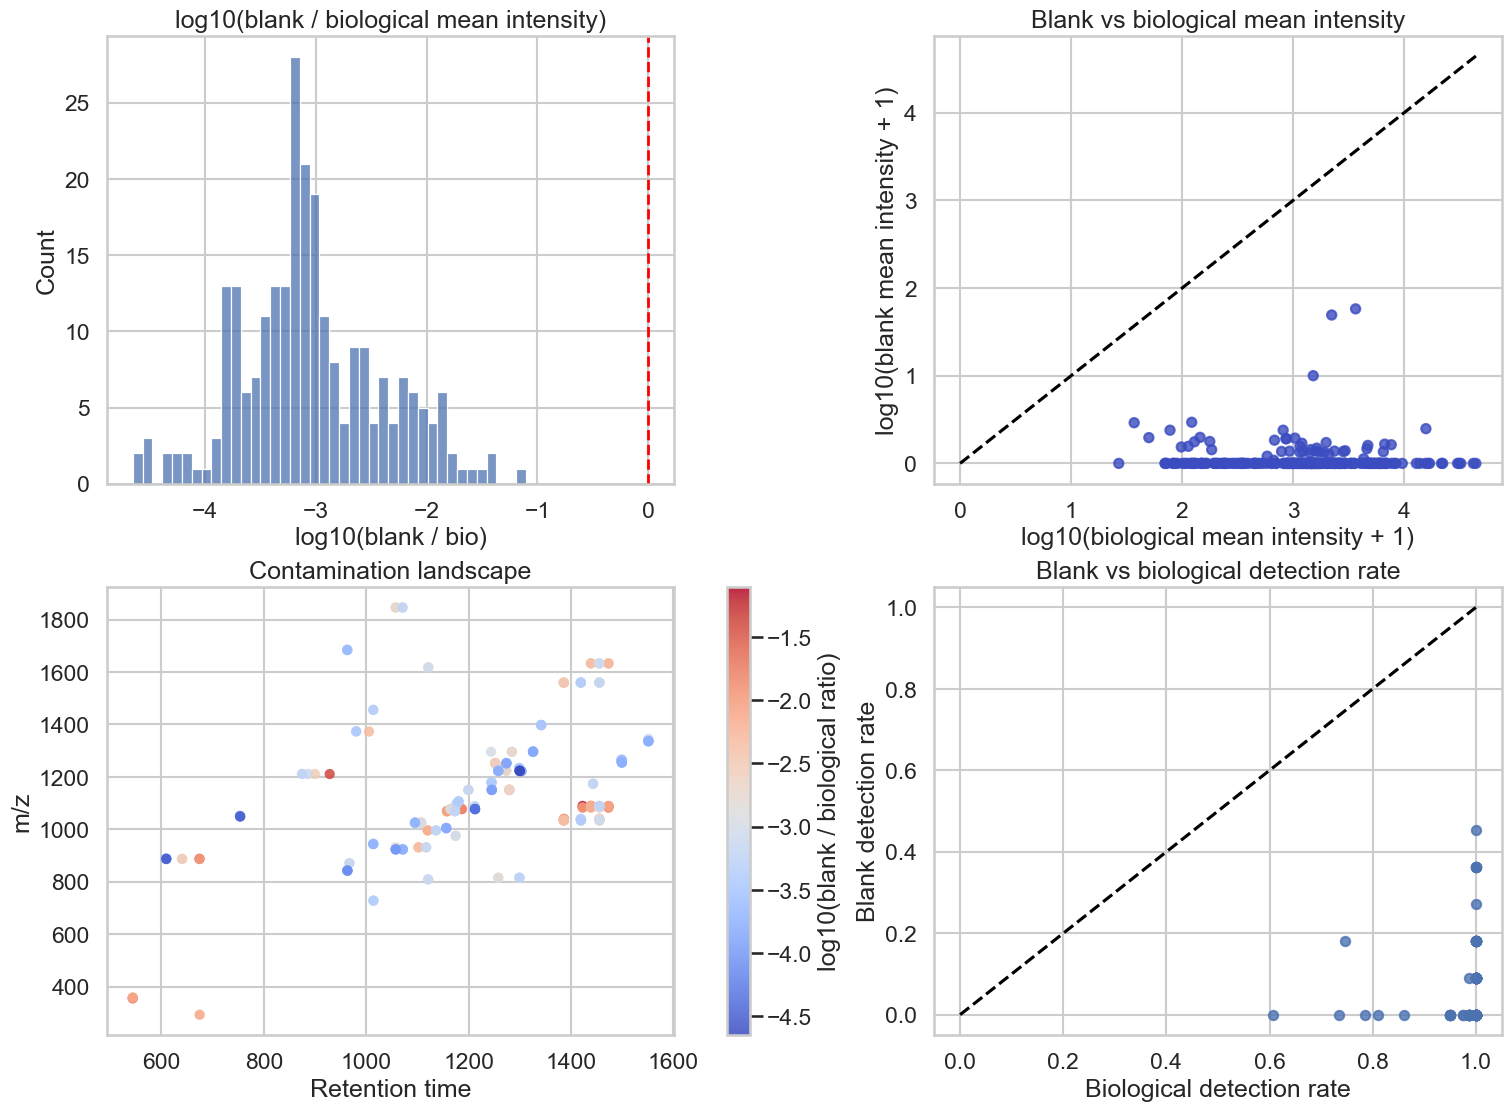

In [15]:
fig = plot_contamination_overview(contamination_metrics)
plt.show()

## Interpretation — contamination and blank behavior

Contamination does not appear to be the dominant problem in this experiment.

Most features have blank-to-biological ratios far below 1, and under the current contamination rule no feature is classified as blank-dominant. In the blank-vs-biological detection plot, many features are consistently present in biological samples while absent from blanks, which is the desired pattern.

That said, contamination is not zero. A small subset of features shows non-negligible blank detection or blank intensity, and the carryover proxy identifies a few features whose blank intensity may depend on the preceding sample signal. These are good candidates for later caution flags, especially when they also occur in low-mass regions or have weak biological support.

A practical mitigation strategy for the next phase is:
1. deprioritize or remove features with unusually high blank detection or suspicious blank-to-sample ratios,
2. flag features with strong carryover-proxy scores for sensitivity analysis,
3. be especially cautious with low-mass features and weakly supported peaks,
4. keep blanks in the workflow as contamination sentinels rather than treating them as outliers to ignore.

**Conclusion:** contamination is present but limited. It is manageable and is not the main reason the full experiment becomes unstable; the larger issue is the batch 2 signal collapse.

## Step 6 — Standards and system suitability tracking

We match the exogenous standards table to observed features using nearest-neighbor matching in RT/m/z space, then track the matched feature intensities over run order and across sample classes.

In [16]:
standard_matches = match_exogenous_standards(
    feature_metadata=feature_metadata,
    exogenous_standards=exogenous_standards,
    ppm_tolerance=5000.0,
    rt_tolerance=90.0,
)

standard_tracking = compute_standard_tracking(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    standard_matches=standard_matches,
)

standard_tracking_summary = summarise_standard_tracking(standard_tracking)

display(standard_matches)
display(standard_tracking_summary)
display(standard_tracking.head(20))

,compound_id,feature,standard_mz,mz,mz_delta,ppm_delta,standard_rt,rt,rt_delta,match_score,within_ppm_tolerance,within_rt_tolerance
0,GU14,FT-162,1253.96,1254.277029,0.317029,252.822345,1500.0,1499.404825,-0.595175,0.057178,True,True
1,GU15,FT-169,1334.99,1335.323637,0.333637,249.917300,1551.0,1551.257112,0.257112,0.052840,True,True
2,GU4,FT-005,886.40,886.632460,0.232460,262.251649,610.0,609.461289,-0.538711,0.058436,True,True
3,GU5,FT-010,1048.45,1048.724800,0.274800,262.100974,753.0,753.824614,0.824614,0.061583,True,True


,compound_id,matched_feature,batch,class,n_samples,mean_intensity,median_intensity,mean_log10_intensity_plus1
0,GU14,FT-162,1,B,6,0.000000,0.000000,0.000000
1,GU14,FT-162,1,Dunn,27,5675.728670,5637.599930,3.747979
2,GU14,FT-162,1,French,26,5946.051392,5787.443643,3.769734
3,GU14,FT-162,1,LMU,26,5860.709308,5540.633981,3.762806
4,GU14,FT-162,1,QC,11,5575.712969,5672.599879,3.741442
5,GU14,FT-162,1,SS,1,5538.812594,5538.812594,3.743495
6,GU14,FT-162,1,dQC,5,5651.710569,5403.200684,3.748945
7,GU14,FT-162,2,B,5,0.000000,0.000000,0.000000
8,GU14,FT-162,2,QC,11,0.000000,0.000000,0.000000
9,GU14,FT-162,2,SS,1,0.000000,0.000000,0.000000


,sample,intensity,class,batch,order,compound_id,matched_feature,log10_intensity_plus1,ppm_delta,rt_delta
0,20241106-297-Blank1,0.000000,B,1,1,GU14,FT-162,0.000000,252.822345,-0.595175
1,20241106-297-Blank2,0.000000,B,1,2,GU14,FT-162,0.000000,252.822345,-0.595175
2,20241106-297-Blank3,0.000000,B,1,3,GU14,FT-162,0.000000,252.822345,-0.595175
3,20241106-297-Experimental_Blank,5538.812594,SS,1,4,GU14,FT-162,3.743495,252.822345,-0.595175
4,20241106-297-Diluted-QC1,5342.736470,dQC,1,7,GU14,FT-162,3.727845,252.822345,-0.595175
5,20241106-297-Diluted-QC2,5403.200684,dQC,1,8,GU14,FT-162,3.732731,252.822345,-0.595175
6,20241106-297-Diluted-QC3,6988.489491,dQC,1,9,GU14,FT-162,3.844445,252.822345,-0.595175
7,20241106-297-Diluted-QC4,4842.249301,dQC,1,10,GU14,FT-162,3.685137,252.822345,-0.595175
8,20241106-297-Diluted-QC5,5681.876896,dQC,1,11,GU14,FT-162,3.754568,252.822345,-0.595175
9,20241106-297-QC1,5516.709087,QC,1,12,GU14,FT-162,3.741759,252.822345,-0.595175


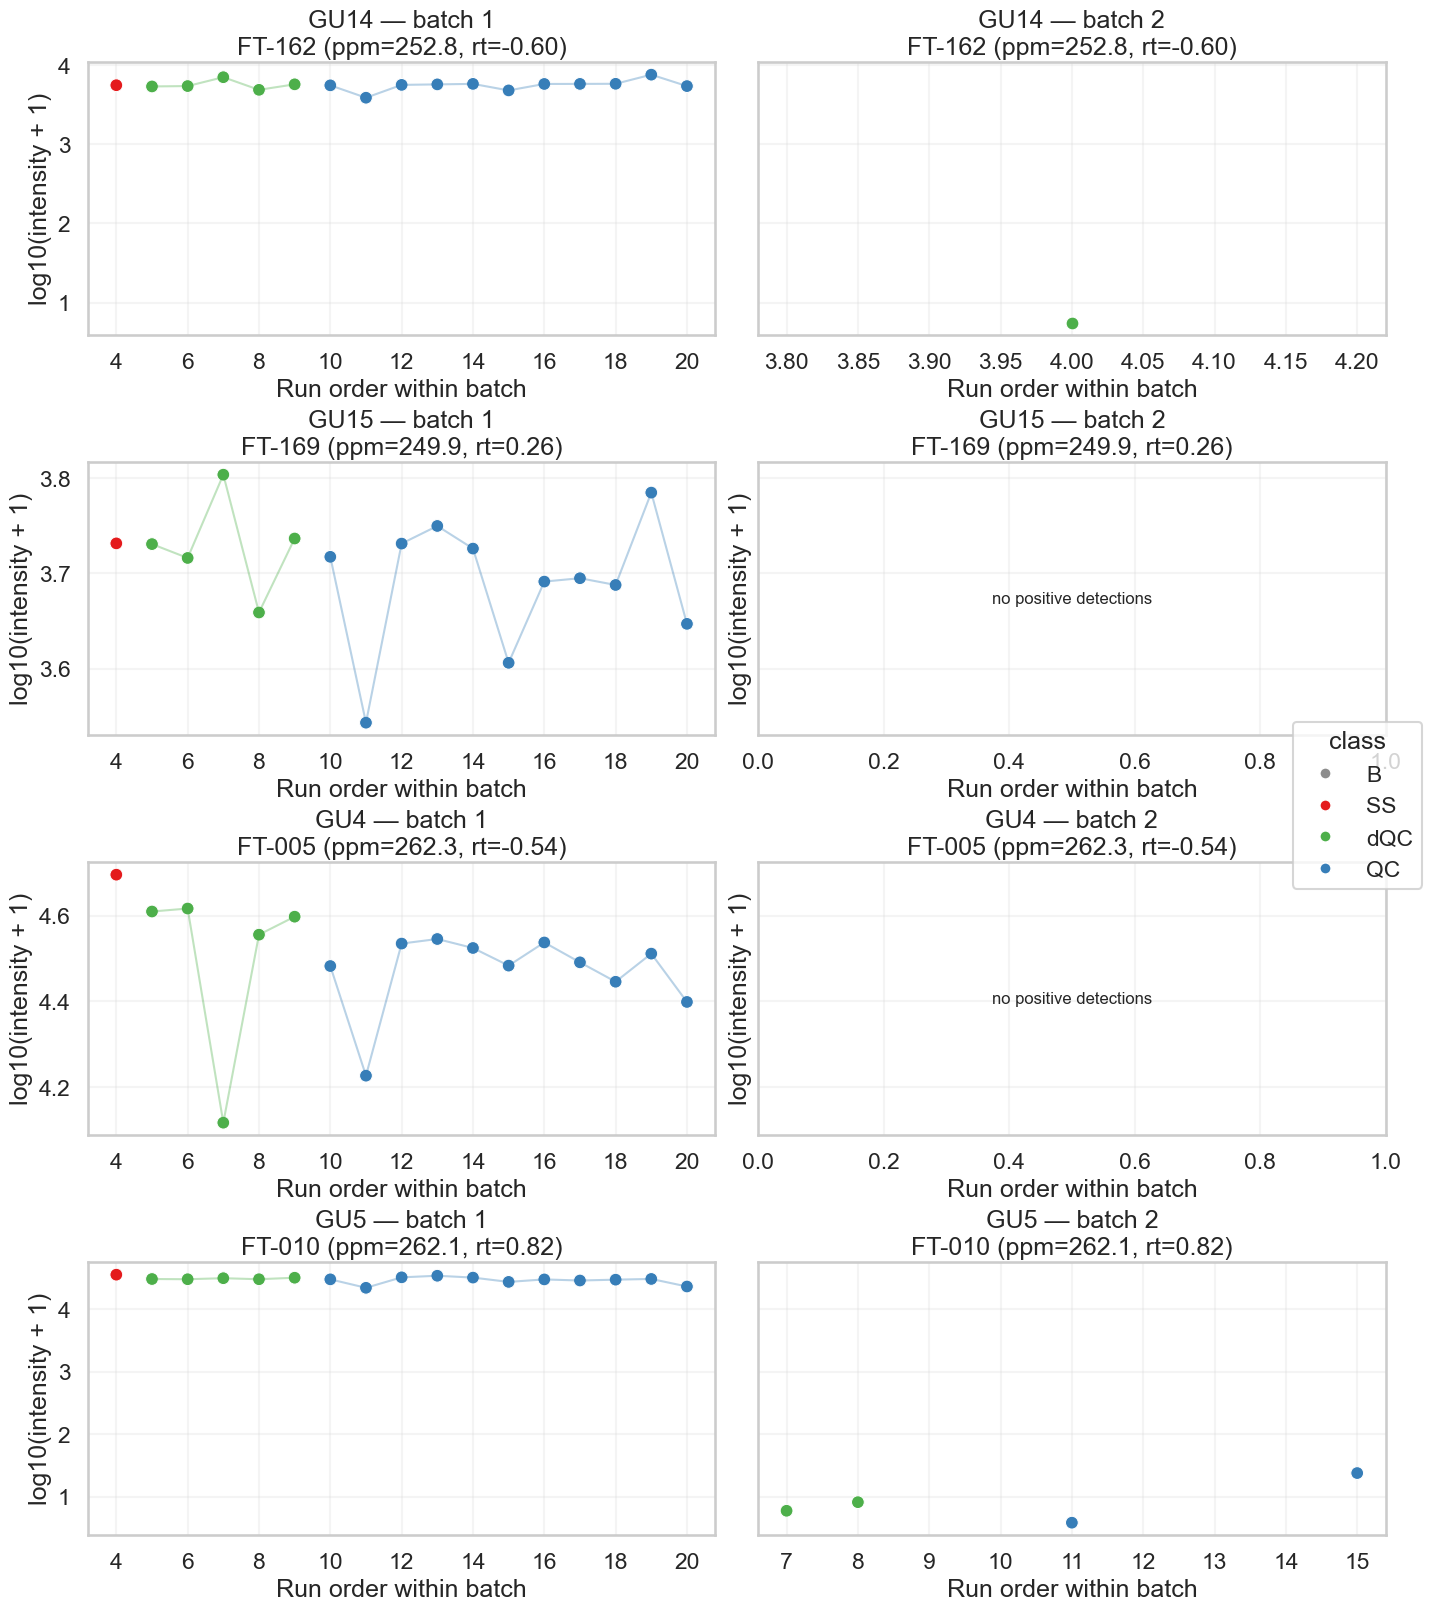

In [17]:
fig = plot_standard_tracking(
    standard_tracking,
    classes=("SS", "dQC", "QC", "B"),
    positive_only=True,
    use_within_batch_order=True,
)
plt.show()

## Interpretation — exogenous standards and system suitability

The standard matching itself is convincing. All four standards were matched to observed features with small RT deviations and small ppm deviations, so the selected features are plausible technical surrogates for the expected standards.

In batch 1, the matched standard features are detected consistently in the system-suitability sample and in the QC-like samples, with strong and fairly stable intensities. This supports the view that batch 1 is technically usable.

In batch 2, the picture changes sharply. For `GU14`, `GU15`, and `GU4`, the matched features are absent or almost absent in the technical samples. `GU5` shows only trace-level signal. This is not consistent with a stable detector across the whole experiment.

Importantly, the problem is not feature identity drift: the matched RT and m/z values remain plausible. The problem is **signal loss / detectability**, especially in batch 2.

**Conclusion:** standards are detected consistently in batch 1 but not across the full experiment. This strongly reinforces the decision to treat batch 2 as technically unreliable for downstream discovery.

In [18]:
from src.eda import (
    find_isomer_candidates,
    find_isotope_adduct_candidates,
    compute_candidate_pair_correlations,
    plot_pair_correlation_distributions,
    plot_top_pair_intensity_scatter,
    compute_technical_biological_metrics,
    compute_acceptance_counts,
    plot_technical_vs_biological_metrics,
    plot_acceptance_counts,
    compute_global_pca,
    flag_pca_outliers,
    plot_global_pca,
)

## Step 7 — Structural redundancy: isomers, isotopes, adducts

We identify candidate feature pairs that may reflect structurally related signals rather than independent biomarkers.

Two classes of candidate pairs are considered:
- putative isomers: nearly identical m/z with different RT,
- putative isotope/adduct pairs: nearly identical RT with mass shifts compatible with common isotope/adduct differences.

We then quantify their intensity correlations across all samples, QC-like samples, and biological samples.

In [19]:
ISOMER_PPM_TOLERANCE = 20.0
ISOMER_MIN_RT_DELTA = 0.10

ISOTOPE_RT_TOLERANCE = 0.15
ISOTOPE_DELTA_TOLERANCE = 0.10

isomer_candidates = find_isomer_candidates(
    feature_metadata=feature_metadata,
    ppm_tolerance=ISOMER_PPM_TOLERANCE,
    min_rt_delta=ISOMER_MIN_RT_DELTA,
)

isomer_candidates = compute_candidate_pair_correlations(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    candidate_pairs=isomer_candidates,
    method="spearman",
)

isotope_adduct_candidates = find_isotope_adduct_candidates(
    feature_metadata=feature_metadata,
    rt_tolerance=ISOTOPE_RT_TOLERANCE,
    delta_tolerance=ISOTOPE_DELTA_TOLERANCE,
)

isotope_adduct_candidates = compute_candidate_pair_correlations(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    candidate_pairs=isotope_adduct_candidates,
    method="spearman",
)

display(isomer_candidates.head(20))
display(isomer_candidates.sort_values("corr_spearman__batch1_biological", ascending=False).head(20))
display(isotope_adduct_candidates.head(20))
display(isotope_adduct_candidates.sort_values("corr_spearman__batch1_biological", ascending=False).head(20))

,feature_a,feature_b,mz_a,mz_b,rt_a,rt_b,ppm_delta,rt_delta,n_samples__all,corr_spearman__all,n_samples__qc_like,corr_spearman__qc_like,n_samples__biological_all,corr_spearman__biological_all,n_samples__batch1_biological,corr_spearman__batch1_biological
0,FT-143,FT-144,1632.548454,1632.548478,1455.163167,1473.171102,0.014177,18.007934,124,0.880538,32,0.952680,79,0.794231,79,0.794231
1,FT-035,FT-036,924.125817,924.125833,1057.660785,1071.432189,0.017278,13.771405,124,0.982922,32,0.914589,79,0.965458,79,0.965458
2,FT-060,FT-061,1251.815295,1251.815198,1252.015698,1273.952846,-0.077337,21.937148,124,0.910638,32,0.935880,79,0.793939,79,0.793939
3,FT-066,FT-068,1150.252305,1150.252473,1199.613617,1279.788424,0.145982,80.174807,124,0.782082,32,0.960785,79,0.478384,79,0.478384
4,FT-147,FT-148,1633.043676,1633.043389,1455.247732,1473.397160,-0.175576,18.149428,124,0.903742,32,0.955409,79,0.816498,79,0.816498
5,FT-128,FT-129,1559.500181,1559.499841,1419.269720,1455.369833,-0.217894,36.100113,124,0.872053,32,0.988693,79,0.677556,79,0.677556
6,FT-084,FT-085,1224.297876,1224.297597,1257.737601,1299.562235,-0.227750,41.824635,124,0.821740,32,0.780792,79,0.565531,79,0.565531
7,FT-112,FT-113,1295.833758,1295.834057,1284.725857,1325.935889,0.230823,41.210032,124,0.902679,32,0.962108,79,0.757765,79,0.757765
8,FT-012,FT-247,1210.824056,1210.823728,874.606710,886.037193,-0.270156,11.430483,124,0.815353,32,0.996801,79,0.537634,79,0.537634
9,FT-190,FT-191,996.159854,996.160124,1120.079080,1136.386403,0.270814,16.307323,124,0.862074,32,0.978533,79,0.631865,79,0.631865


,feature_a,feature_b,mz_a,mz_b,rt_a,rt_b,ppm_delta,rt_delta,n_samples__all,corr_spearman__all,n_samples__qc_like,corr_spearman__qc_like,n_samples__biological_all,corr_spearman__biological_all,n_samples__batch1_biological,corr_spearman__batch1_biological
38,FT-031,FT-032,923.623393,923.624248,1057.596400,1071.516348,0.926396,13.919948,124,0.987993,32,0.984671,79,0.969377,79,0.969377
34,FT-044,FT-045,923.121256,923.122020,1057.620517,1071.585928,0.828302,13.965411,124,0.983956,32,0.954093,79,0.965628,79,0.965628
1,FT-035,FT-036,924.125817,924.125833,1057.660785,1071.432189,0.017278,13.771405,124,0.982922,32,0.914589,79,0.965458,79,0.965458
35,FT-033,FT-034,924.627631,924.628457,1057.724634,1071.194489,0.892685,13.469854,124,0.975125,32,0.948124,79,0.939679,79,0.939679
30,FT-156,FT-201,1560.001369,1560.002568,1419.237135,1385.959127,0.768438,33.278008,124,0.945714,32,0.965686,79,0.879674,79,0.879674
96,FT-206,FT-212,1034.656076,1034.652489,1386.038646,1419.535596,-3.466770,33.496950,124,0.950033,32,0.988275,79,0.870545,79,0.870545
41,FT-028,FT-029,1845.267570,1845.265745,1057.465323,1070.965957,-0.989092,13.500634,124,0.933508,32,0.974456,79,0.860607,79,0.860607
98,FT-078,FT-080,1077.205729,1077.201976,1164.908119,1212.614389,-3.483494,47.706269,124,0.942488,32,0.946211,79,0.858861,79,0.858861
61,FT-202,FT-203,1033.987006,1033.985125,1386.152000,1419.599417,-1.818816,33.447418,124,0.936387,32,0.954657,79,0.858204,79,0.858204
28,FT-039,FT-040,1024.686709,1024.685940,1095.258555,1107.617016,-0.750475,12.358461,124,0.936090,32,0.987337,79,0.844158,79,0.844158


,feature_a,feature_b,mz_a,mz_b,rt_a,rt_b,rt_delta,mz_delta,delta_type,expected_delta,delta_error,n_samples__all,corr_spearman__all,n_samples__qc_like,corr_spearman__qc_like,n_samples__biological_all,corr_spearman__biological_all,n_samples__batch1_biological,corr_spearman__batch1_biological
0,FT-019,FT-017,1683.166365,1684.170802,963.045316,963.044552,0.000764,1.004437,M+1 isotope,1.003355,0.001082,124,0.987140,32,0.997487,79,0.969572,79,0.969572
1,FT-018,FT-023,1372.919112,1373.922510,980.422438,980.421287,0.001151,1.003398,M+1 isotope,1.003355,0.000043,124,0.967330,32,0.933136,79,0.929869,79,0.929869
2,FT-055,FT-194,1105.732768,1106.736190,1180.358617,1180.360779,0.002163,1.003422,M+1 isotope,1.003355,0.000067,124,0.979693,32,0.911079,79,0.954601,79,0.954601
3,FT-145,FT-147,1632.042224,1633.043676,1455.244908,1455.247732,0.002824,1.001451,M+1 isotope,1.003355,-0.001904,124,0.971629,32,0.972914,79,0.935658,79,0.935658
4,FT-012,FT-011,1210.824056,1211.827915,874.606710,874.613343,0.006633,1.003860,M+1 isotope,1.003355,0.000505,124,0.938256,32,0.940136,79,0.871470,79,0.871470
5,FT-001,FT-000,357.109546,359.108768,543.839157,543.846374,0.007216,1.999222,2x M+1 isotope,2.006710,-0.007488,124,0.846812,32,0.686950,79,0.899051,79,0.899051
6,FT-064,FT-070,1149.750094,1150.753810,1245.272856,1245.288152,0.015295,1.003717,M+1 isotope,1.003355,0.000362,124,0.992479,32,0.949792,79,0.989143,79,0.989143
7,FT-030,FT-024,943.640776,944.643481,1013.782161,1013.805439,0.023278,1.002705,M+1 isotope,1.003355,-0.000650,124,0.989334,32,0.886719,79,0.990093,79,0.990093
8,FT-046,FT-043,1004.167127,1005.172042,1156.358765,1156.385535,0.026770,1.004915,M+1 isotope,1.003355,0.001560,124,0.989975,32,0.928122,79,0.987196,79,0.987196
9,FT-067,FT-114,1150.251970,1151.256806,1245.308684,1245.281315,0.027369,1.004837,M+1 isotope,1.003355,0.001482,124,0.987379,32,0.932561,79,0.985735,79,0.985735


,feature_a,feature_b,mz_a,mz_b,rt_a,rt_b,rt_delta,mz_delta,delta_type,expected_delta,delta_error,n_samples__all,corr_spearman__all,n_samples__qc_like,corr_spearman__qc_like,n_samples__biological_all,corr_spearman__biological_all,n_samples__batch1_biological,corr_spearman__batch1_biological
39,FT-006,FT-004,887.640372,888.645365,609.387459,609.255652,0.131807,1.004993,M+1 isotope,1.003355,0.001638,124,0.993457,32,0.934153,79,0.992575,79,0.992575
7,FT-030,FT-024,943.640776,944.643481,1013.782161,1013.805439,0.023278,1.002705,M+1 isotope,1.003355,-0.000650,124,0.989334,32,0.886719,79,0.990093,79,0.990093
24,FT-005,FT-006,886.632460,887.640372,609.461289,609.387459,0.073831,1.007912,M+1 isotope,1.003355,0.004557,124,0.993254,32,0.966852,79,0.989362,79,0.989362
6,FT-064,FT-070,1149.750094,1150.753810,1245.272856,1245.288152,0.015295,1.003717,M+1 isotope,1.003355,0.000362,124,0.992479,32,0.949792,79,0.989143,79,0.989143
8,FT-046,FT-043,1004.167127,1005.172042,1156.358765,1156.385535,0.026770,1.004915,M+1 isotope,1.003355,0.001560,124,0.989975,32,0.928122,79,0.987196,79,0.987196
37,FT-031,FT-033,923.623393,924.627631,1057.596400,1057.724634,0.128234,1.004239,M+1 isotope,1.003355,0.000884,124,0.990909,32,0.926145,79,0.987123,79,0.987123
13,FT-021,FT-025,842.075679,843.080106,963.278928,963.243959,0.034970,1.004427,M+1 isotope,1.003355,0.001072,124,0.987833,32,0.924051,79,0.987074,79,0.987074
9,FT-067,FT-114,1150.251970,1151.256806,1245.308684,1245.281315,0.027369,1.004837,M+1 isotope,1.003355,0.001482,124,0.987379,32,0.932561,79,0.985735,79,0.985735
16,FT-044,FT-035,923.121256,924.125817,1057.620517,1057.660785,0.040267,1.004561,M+1 isotope,1.003355,0.001206,124,0.986467,32,0.857417,79,0.983009,79,0.983009
38,FT-108,FT-106,1230.806547,1231.808476,1298.911468,1298.781969,0.129499,1.001929,M+1 isotope,1.003355,-0.001426,124,0.987760,32,0.919482,79,0.979479,79,0.979479


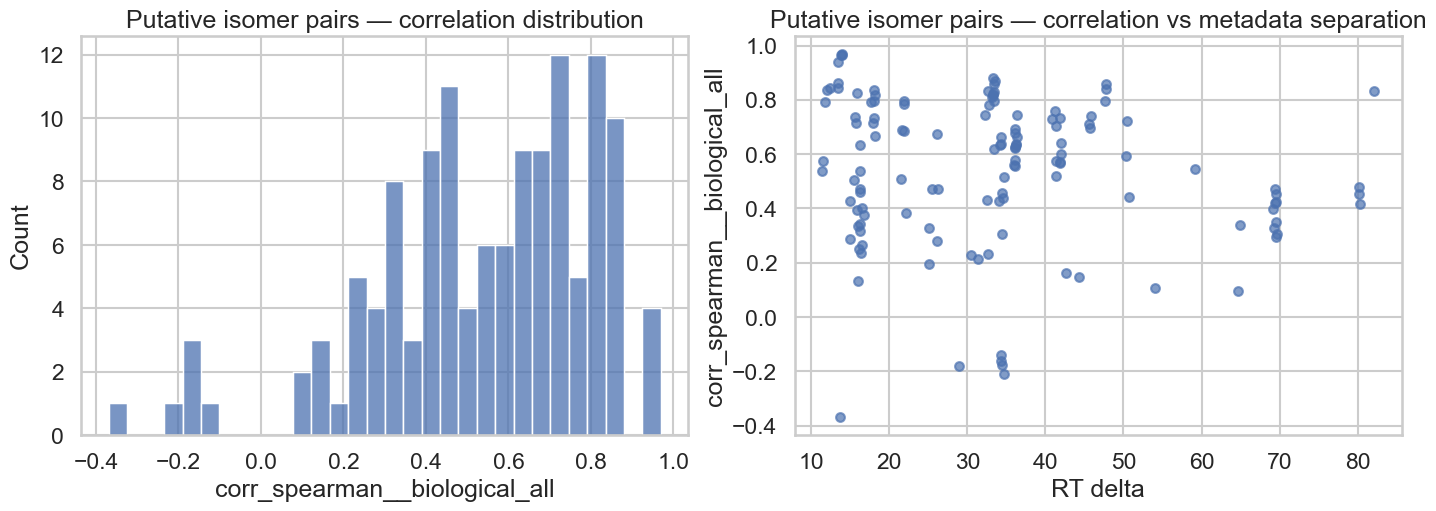

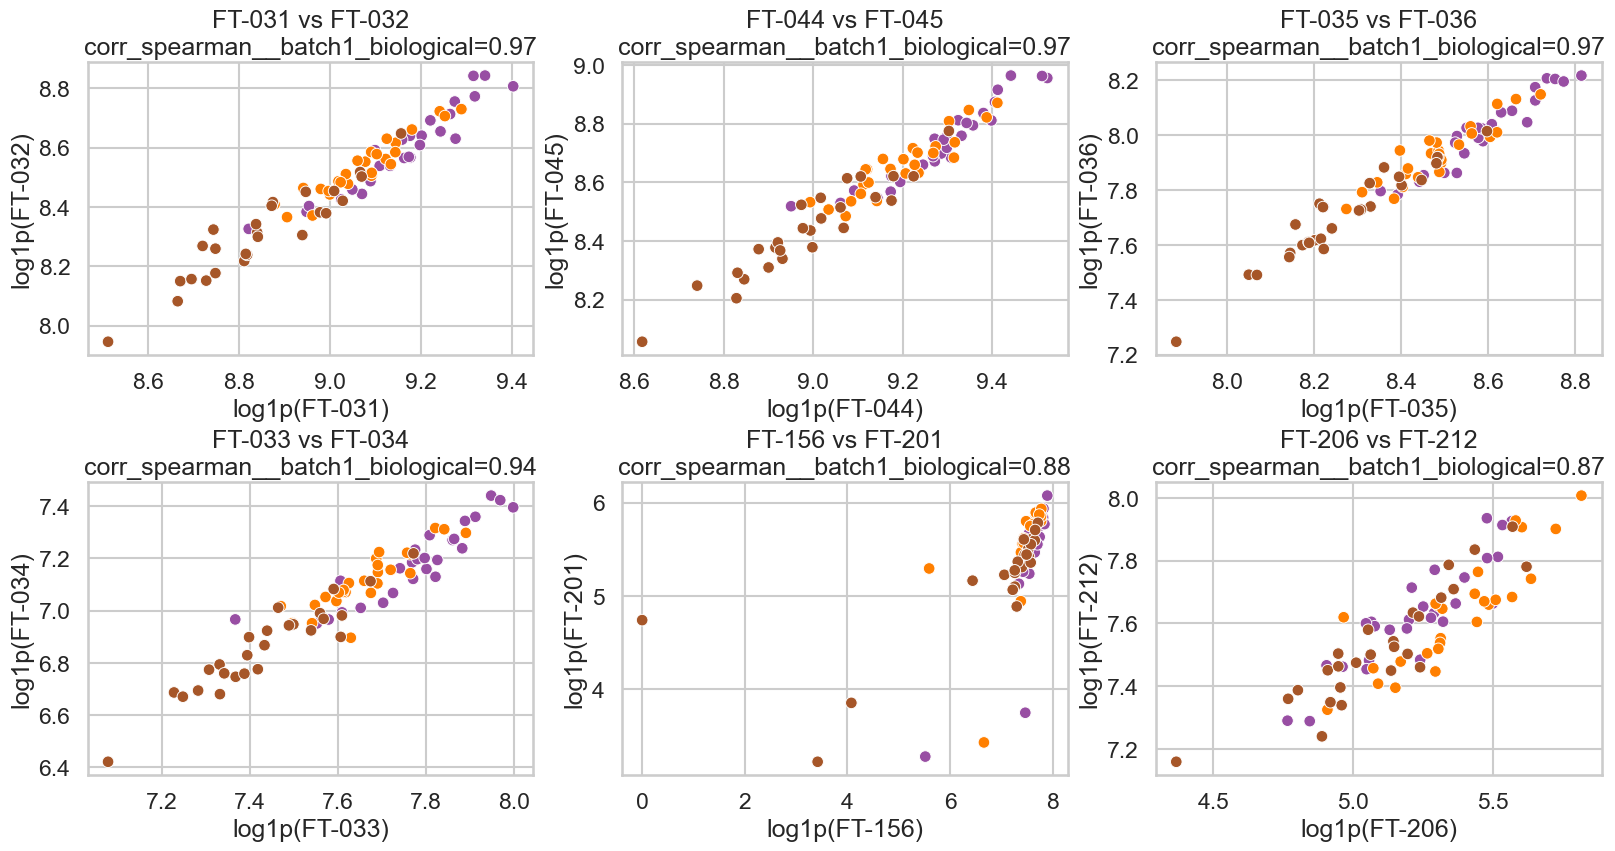

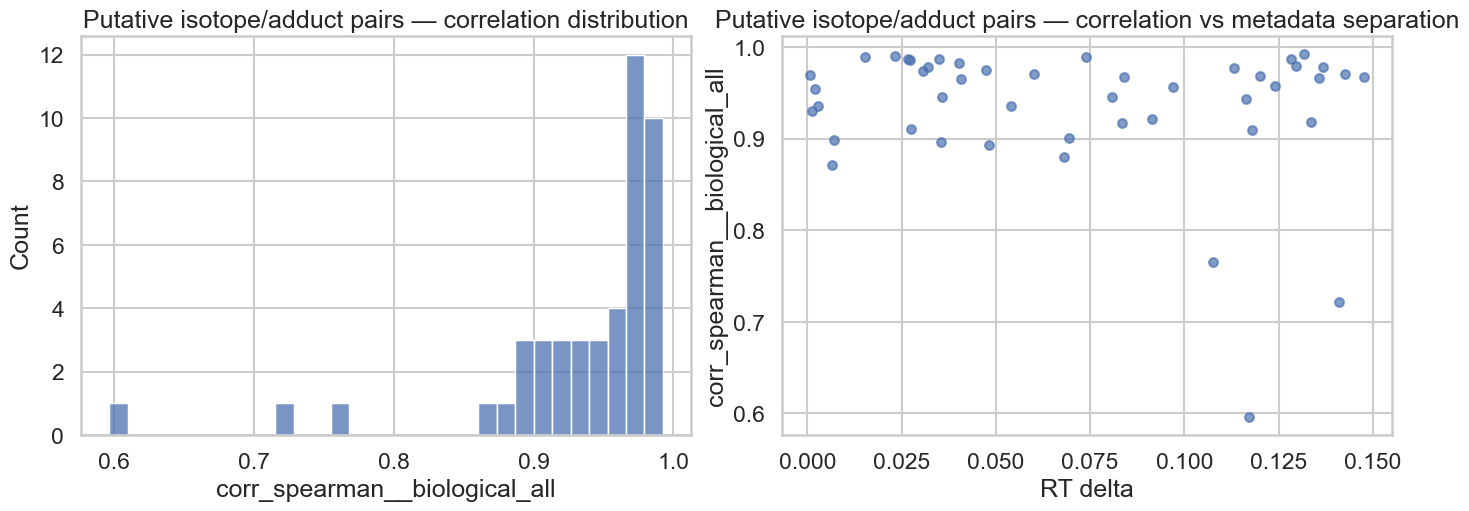

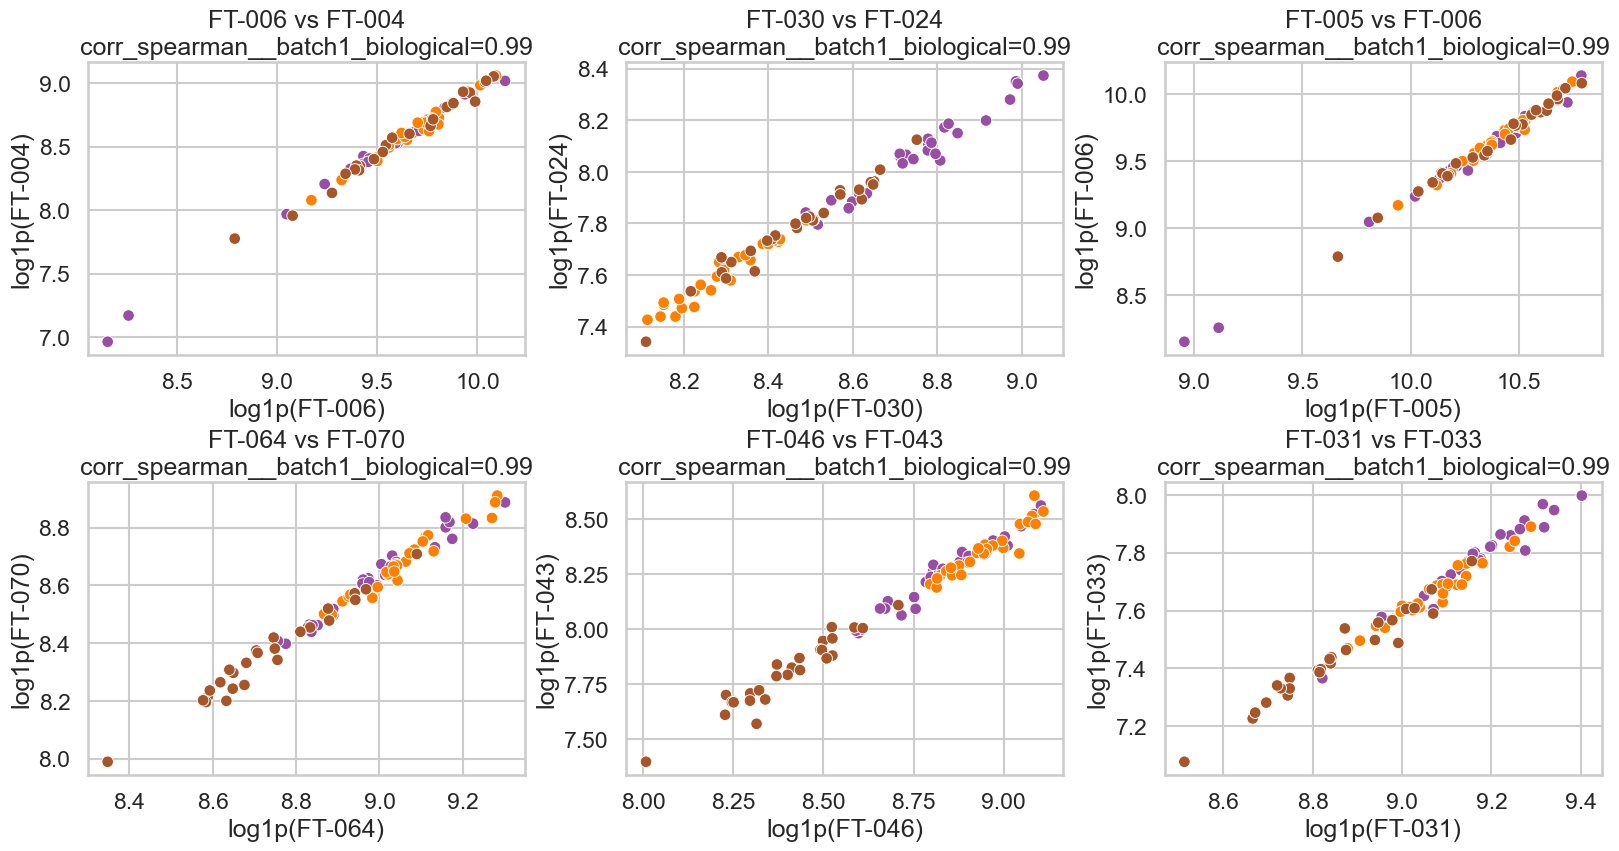

In [20]:
if not isomer_candidates.empty:
    fig = plot_pair_correlation_distributions(
        isomer_candidates,
        title="Putative isomer pairs",
        corr_col="corr_spearman__biological_all",
    )
    plt.show()

    fig = plot_top_pair_intensity_scatter(
        data_matrix=data_matrix,
        acquisition_list=acquisition_list,
        candidate_pairs=isomer_candidates,
        top_n=6,
        corr_col="corr_spearman__batch1_biological",
    )
    plt.show()

if not isotope_adduct_candidates.empty:
    fig = plot_pair_correlation_distributions(
        isotope_adduct_candidates,
        title="Putative isotope/adduct pairs",
        corr_col="corr_spearman__biological_all",
    )
    plt.show()

    fig = plot_top_pair_intensity_scatter(
        data_matrix=data_matrix,
        acquisition_list=acquisition_list,
        candidate_pairs=isotope_adduct_candidates,
        top_n=6,
        corr_col="corr_spearman__batch1_biological",
    )
    plt.show()

## Interpretation — isomers, isotopes/adducts, and feature redundancy

### Q1 — Are there features that could correspond to isomers?
Yes. Under the current tolerance rules, we identified 129 putative isomer-like pairs: pairs with nearly identical m/z but separated in RT. This is a strong indication that the feature table contains retention-time-separated signal families rather than only isolated peaks.

### Q2 — Are there features that could correspond to isotopes or adducts?
Yes. We identified 46 putative isotope/adduct-like pairs, many with mass differences very close to the expected +1.003 or +2.007 isotope shifts and with very small RT differences. This is exactly the type of pattern expected for isotopic relationships.

### Q3 — Is there any correlation between isomers? Between isotopes?
Yes, and often very strong. Many putative isomer pairs show high positive correlations across the biological samples, and the isotope-like pairs are even more strongly correlated in many cases. The strongest isotope-like pairs are close to near-linear relationships.

The key interpretation is that many features are **not independent pieces of evidence**. Some are likely different manifestations of the same underlying molecular family.

**Conclusion:** later biomarker discovery should report correlated feature families carefully and avoid over-counting multiple highly related peaks as separate discoveries.

## Step 8 — Technical versus biological variance

We compare technical variability measured from QC-like samples against within-class biological variability measured from the batch 1 biological classes (`Dunn`, `French`, `LMU`).

This step computes:
- feature-wise QC CV,
- within-class biological CV,
- D-ratio-style technical-to-biological variability summaries,
- and counts of retained features under increasingly strict technical criteria.

In [21]:
technical_biological_metrics = compute_technical_biological_metrics(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    feature_metadata=feature_metadata,
    qc_feature_metrics=qc_feature_metrics,
)

acceptance_counts = compute_acceptance_counts(
    technical_biological_metrics=technical_biological_metrics,
    qc_thresholds=(20.0, 30.0, 40.0),
    d_ratio_thresholds=(0.5, 0.75, 1.0, 1.25),
    detection_thresholds=(0.5, 0.7, 0.9),
    mz_min=500.0,
)

display(technical_biological_metrics.head(20))
display(
    technical_biological_metrics.sort_values("d_ratio_log", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(
    technical_biological_metrics.sort_values("qc_cv_pct", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(acceptance_counts)

,feature,qc_mean_intensity,qc_cv_pct,qc_detection_rate,qc_order_spearman_rho,qc_order_spearman_abs,mz,rt,qc_log_sd,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,Dunn_detection_rate,French_mean_intensity,French_std_intensity,French_cv_pct,French_log_sd,French_detection_rate,LMU_mean_intensity,LMU_std_intensity,LMU_cv_pct,LMU_log_sd,LMU_detection_rate,bio_cv_pct_median,bio_cv_pct_max,bio_log_sd_median,bio_detection_rate_median,bio_detection_rate_min,d_ratio_cv,d_ratio_log,passes_qc_cv_30,passes_detection_70,passes_mz_500,passes_basic_part_b_screen
0,FT-013,180.579324,242.703043,0.43750,-0.699498,0.699498,1210.827050,899.723393,2.789369,778.958998,315.454966,40.496992,1.523784,0.962963,101.366011,98.631542,97.302381,2.529283,0.615385,145.303086,328.371028,225.990401,2.568833,0.615385,97.302381,225.990401,2.529283,0.615385,0.615385,2.494318,1.102830,False,False,True,False
1,FT-174,18.969562,190.425338,0.53125,-0.758452,0.758452,1210.830470,928.694830,1.740368,17.294270,53.963066,312.028582,1.473552,0.629630,97.204163,23.251326,23.920093,0.238938,1.000000,34.369061,60.612707,176.358343,1.912361,0.615385,176.358343,312.028582,1.473552,0.629630,0.615385,1.079764,1.181070,False,False,True,False
2,FT-210,283.143913,111.800810,0.87500,0.710879,0.710879,293.183141,674.618163,2.005365,163.068057,111.897690,68.620239,1.484152,0.925926,103.891076,42.903901,41.297003,1.372459,0.923077,105.235221,26.205451,24.901787,0.232459,1.000000,41.297003,68.620239,1.372459,0.925926,0.923077,2.707238,1.461147,False,True,False,False
3,FT-251,9.210994,175.459895,0.34375,-0.549077,0.549077,887.647221,674.305633,1.562134,2.583768,4.026075,155.821832,1.013800,0.370370,71.614194,19.327524,26.988398,0.288576,1.000000,4.368391,6.740384,154.299021,1.174632,0.461538,154.299021,155.821832,1.013800,0.461538,0.370370,1.137142,1.540870,False,False,True,False
4,FT-172,22.431692,154.066497,0.40625,-0.612038,0.612038,886.635261,674.188516,1.956177,115.374844,198.801157,172.308928,2.055261,0.851852,189.970263,38.220214,20.119051,0.202301,1.000000,8.819351,10.504444,119.106765,1.213560,0.730769,119.106765,172.308928,1.213560,0.851852,0.730769,1.293516,1.611933,False,True,True,False
5,FT-181,610.546819,124.708755,0.46875,-0.750474,0.750474,1846.270343,1070.925202,3.580084,1625.241353,535.310429,32.937288,1.765078,0.962963,1467.392423,485.062092,33.056058,0.758223,1.000000,983.295681,566.077587,57.569417,2.392103,0.884615,33.056058,57.569417,1.765078,0.962963,0.884615,3.772644,2.028287,False,True,True,False
6,FT-173,1072.336656,374.980304,0.46875,-0.632418,0.632418,887.645627,639.907400,2.972962,792.283836,3130.176503,395.082716,1.403611,0.962963,252.814094,84.308017,33.347831,0.359735,1.000000,12.772049,19.394674,151.852494,1.720334,0.384615,151.852494,395.082716,1.403611,0.962963,0.384615,2.469372,2.118082,False,False,True,False
7,FT-180,201.807700,121.867182,0.50000,-0.757735,0.757735,1846.271291,1057.533399,3.002351,541.136000,208.484448,38.527181,1.397225,0.962963,469.566460,160.252446,34.127746,0.563251,1.000000,328.003821,174.576223,53.223838,1.976784,0.884615,38.527181,53.223838,1.397225,0.962963,0.884615,3.163148,2.148796,False,True,True,False
8,FT-028,210.829122,128.012120,0.50000,-0.742846,0.742846,1845.267570,1057.465323,3.010869,639.351551,184.401834,28.842009,0.817646,1.000000,551.074800,188.960670,34.289478,1.283249,0.961538,397.599913,186.545224,46.917823,1.356387,0.961538,34.289478,46.917823,1.283249,0.961538,0.961538,3.733277,2.346285,False,True,True,False
9,FT-188,40.132352,106.441482,0.59375,-0.744471,0.744471,931.123316,1102.187969,2.097943,153.373854,282.512535,184.198628,0.591367,1.000000,360.948334,635.399220,176.036059,1.352206,1.000000,204.009392,337.470041,165.418875,0.882706,1.000000,176.036059,184.198628,0.882706,1.000000,1.000000,0.604657,2.376718,False,True,True,False


,feature,qc_mean_intensity,qc_cv_pct,qc_detection_rate,qc_order_spearman_rho,qc_order_spearman_abs,mz,rt,qc_log_sd,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,Dunn_detection_rate,French_mean_intensity,French_std_intensity,French_cv_pct,French_log_sd,French_detection_rate,LMU_mean_intensity,LMU_std_intensity,LMU_cv_pct,LMU_log_sd,LMU_detection_rate,bio_cv_pct_median,bio_cv_pct_max,bio_log_sd_median,bio_detection_rate_median,bio_detection_rate_min,d_ratio_cv,d_ratio_log,passes_qc_cv_30,passes_detection_70,passes_mz_500,passes_basic_part_b_screen
0,FT-101,21619.542269,103.255236,0.50000,-0.741671,0.741671,1222.780065,1300.021421,5.419205,45557.490997,4420.148443,9.702353,0.097370,1.0,43120.127374,2960.182092,6.864966,0.068664,1.0,44610.316055,4225.289316,9.471552,0.097369,1.0,9.471552,9.702353,0.097369,1.0,1.0,10.901617,55.656218,False,True,True,False
1,FT-142,15105.102446,104.054676,0.50000,-0.742846,0.742846,1223.287005,1299.845174,5.235513,32271.204774,3220.580037,9.979733,0.101548,1.0,30474.971319,2160.877159,7.090662,0.070734,1.0,31597.492667,3067.458728,9.707918,0.099091,1.0,9.707918,9.979733,0.099091,1.0,1.0,10.718537,52.835508,False,True,True,False
2,FT-105,20707.693296,103.507655,0.50000,-0.745589,0.745589,1222.279260,1300.115492,5.396763,43079.303681,4733.557043,10.988007,0.108691,1.0,41117.416639,3427.654260,8.336259,0.083561,1.0,42261.014808,4771.840522,11.291353,0.112455,1.0,10.988007,11.291353,0.108691,1.0,1.0,9.420057,49.652509,False,True,True,False
3,FT-088,8209.992144,104.379596,0.78125,-0.715927,0.715927,1223.793769,1299.760101,4.318749,17521.122370,1899.723631,10.842477,0.109700,1.0,16445.755923,1281.447841,7.791967,0.077468,1.0,17006.907218,1624.175816,9.550095,0.098195,1.0,9.550095,10.842477,0.098195,1.0,1.0,10.929692,43.981454,False,True,True,False
4,FT-010,14694.339250,102.678921,0.62500,-0.828269,0.828269,1048.724800,753.824614,5.006236,30190.928197,3678.606832,12.184477,0.123717,1.0,30941.181922,2643.950324,8.545085,0.085035,1.0,30036.333139,3928.457749,13.079019,0.136225,1.0,12.184477,13.079019,0.123717,1.0,1.0,8.427027,40.465342,False,True,True,False
5,FT-080,10256.916986,106.606994,0.56250,-0.748725,0.748725,1077.201976,1212.614389,4.933037,23565.274066,3078.401259,13.063295,0.132316,1.0,22038.134177,1826.100100,8.286092,0.081905,1.0,19634.724123,2751.192250,14.011871,0.139688,1.0,13.063295,14.011871,0.132316,1.0,1.0,8.160804,37.282149,False,True,True,False
6,FT-009,7988.533141,102.895059,0.50000,-0.852941,0.852941,1049.732664,753.593752,4.914093,16370.722414,2183.547282,13.338124,0.133395,1.0,16811.464003,1526.281338,9.078813,0.089873,1.0,16213.887084,2212.431103,13.645285,0.141651,1.0,13.338124,13.645285,0.133395,1.0,1.0,7.714358,36.838578,False,True,True,False
7,FT-076,10479.286370,106.391697,0.53125,-0.718982,0.718982,1076.700249,1212.729814,5.034682,24068.696872,3404.750672,14.145970,0.140337,1.0,22539.698180,2140.616770,9.497096,0.093045,1.0,20273.604282,2976.373679,14.681029,0.143087,1.0,14.145970,14.681029,0.140337,1.0,1.0,7.520990,35.875607,False,True,True,False
8,FT-096,881.740815,104.845873,0.53125,-0.742974,0.742974,815.525261,1299.357741,3.745913,1832.956715,204.262899,11.143902,0.112529,1.0,1701.086048,169.433131,9.960292,0.101687,1.0,1756.647299,198.622495,11.306908,0.119233,1.0,11.143902,11.306908,0.112529,1.0,1.0,9.408363,33.288550,False,True,True,False
9,FT-082,797.582980,105.287051,0.50000,-0.745589,0.745589,815.191452,1299.390261,3.739995,1654.498407,187.104495,11.308835,0.112474,1.0,1577.499345,160.483552,10.173288,0.104518,1.0,1622.361488,224.875745,13.861014,0.138958,1.0,11.308835,13.861014,0.112474,1.0,1.0,9.310159,33.252212,False,True,True,False


,feature,qc_mean_intensity,qc_cv_pct,qc_detection_rate,qc_order_spearman_rho,qc_order_spearman_abs,mz,rt,qc_log_sd,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,Dunn_detection_rate,French_mean_intensity,French_std_intensity,French_cv_pct,French_log_sd,French_detection_rate,LMU_mean_intensity,LMU_std_intensity,LMU_cv_pct,LMU_log_sd,LMU_detection_rate,bio_cv_pct_median,bio_cv_pct_max,bio_log_sd_median,bio_detection_rate_median,bio_detection_rate_min,d_ratio_cv,d_ratio_log,passes_qc_cv_30,passes_detection_70,passes_mz_500,passes_basic_part_b_screen
0,FT-173,1072.336656,374.980304,0.46875,-0.632418,0.632418,887.645627,639.907400,2.972962,792.283836,3130.176503,395.082716,1.403611,0.962963,252.814094,84.308017,33.347831,0.359735,1.000000,12.772049,19.394674,151.852494,1.720334,0.384615,151.852494,395.082716,1.403611,0.962963,0.384615,2.469372,2.118082,False,False,True,False
1,FT-132,91.700575,272.134662,0.53125,-0.807984,0.807984,1088.354986,1438.809837,2.418971,117.602807,35.562768,30.239727,0.321753,1.000000,92.461580,20.396998,22.059971,0.225203,1.000000,90.048999,30.532437,33.906471,0.398620,1.000000,30.239727,33.906471,0.321753,1.000000,1.000000,8.999243,7.518089,False,True,True,False
2,FT-141,444.298491,254.085062,0.50000,-0.787903,0.787903,1223.295151,1273.683493,3.089227,429.801504,892.677494,207.695293,0.639740,1.000000,638.583814,1430.458220,224.004772,1.113554,1.000000,946.457216,1637.692557,173.033976,1.264804,1.000000,207.695293,224.004772,1.113554,1.000000,1.000000,1.223355,2.774206,False,True,True,False
3,FT-199,104.093348,243.764487,0.90625,-0.733407,0.733407,1223.794330,1273.446642,1.795391,166.957149,33.315503,19.954523,0.206503,1.000000,145.276921,34.597370,23.814774,0.232189,1.000000,381.856435,768.026547,201.129659,1.142319,1.000000,23.814774,201.129659,0.232189,1.000000,1.000000,10.235851,7.732443,False,True,True,False
4,FT-013,180.579324,242.703043,0.43750,-0.699498,0.699498,1210.827050,899.723393,2.789369,778.958998,315.454966,40.496992,1.523784,0.962963,101.366011,98.631542,97.302381,2.529283,0.615385,145.303086,328.371028,225.990401,2.568833,0.615385,97.302381,225.990401,2.529283,0.615385,0.615385,2.494318,1.102830,False,False,True,False
5,FT-126,58.840599,220.363418,0.75000,-0.706708,0.706708,1089.358935,1439.054183,1.919181,83.079534,22.353544,26.906198,0.262662,1.000000,66.700655,14.095404,21.132332,0.222759,1.000000,94.399882,175.054666,185.439496,0.633825,1.000000,26.906198,185.439496,0.262662,1.000000,1.000000,8.190061,7.306645,False,True,True,False
6,FT-079,43.035127,191.915647,0.56250,-0.726326,0.726326,1077.209362,1186.459409,2.116110,89.287519,24.885817,27.871552,0.313875,1.000000,62.654572,23.916146,38.171429,0.416282,1.000000,78.200788,159.045181,203.380536,0.860746,1.000000,38.171429,203.380536,0.416282,1.000000,1.000000,5.027730,5.083357,False,True,True,False
7,FT-174,18.969562,190.425338,0.53125,-0.758452,0.758452,1210.830470,928.694830,1.740368,17.294270,53.963066,312.028582,1.473552,0.629630,97.204163,23.251326,23.920093,0.238938,1.000000,34.369061,60.612707,176.358343,1.912361,0.615385,176.358343,312.028582,1.473552,0.629630,0.615385,1.079764,1.181070,False,False,True,False
8,FT-246,95.605104,181.921531,0.37500,-0.563585,0.563585,886.640677,640.780607,2.567142,468.883422,180.034365,38.396402,0.515263,1.000000,628.632636,131.300520,20.886685,0.213646,1.000000,19.486687,52.870948,271.318297,1.712987,0.423077,38.396402,271.318297,0.515263,1.000000,0.423077,4.737984,4.982201,False,False,True,False
9,FT-183,203.332574,176.179467,0.96875,-0.673021,0.673021,1026.192891,1107.040420,1.844951,372.138148,392.712854,105.528782,0.622422,1.000000,323.009290,368.655251,114.131470,0.641551,1.000000,364.244994,369.435318,101.424954,0.739400,1.000000,105.528782,114.131470,0.641551,1.000000,1.000000,1.669492,2.875766,False,True,True,False


,criterion_type,threshold,n_features
0,qc_cv_threshold,20.00,0
1,qc_cv_threshold,30.00,0
2,qc_cv_threshold,40.00,0
3,d_ratio_log_threshold,0.50,0
4,d_ratio_log_threshold,0.75,0
5,d_ratio_log_threshold,1.00,0
6,d_ratio_log_threshold,1.25,0
7,bio_detection_threshold,0.50,0
8,bio_detection_threshold,0.70,0
9,bio_detection_threshold,0.90,0


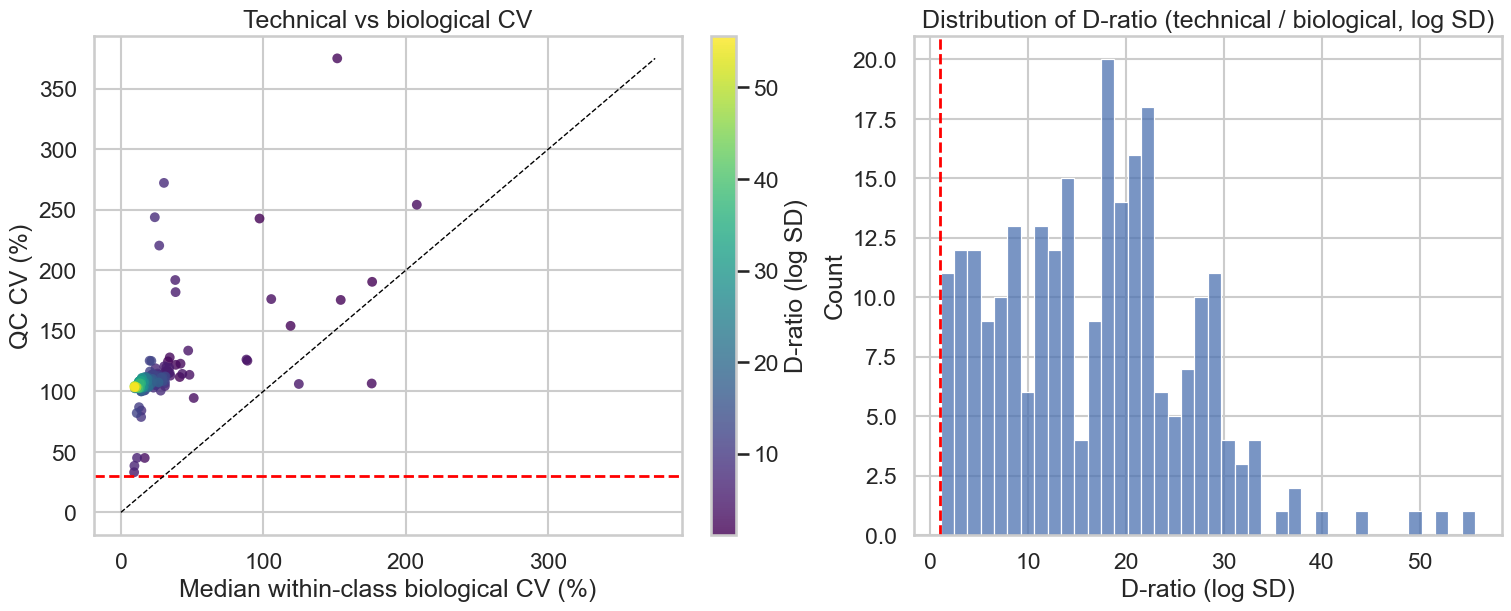

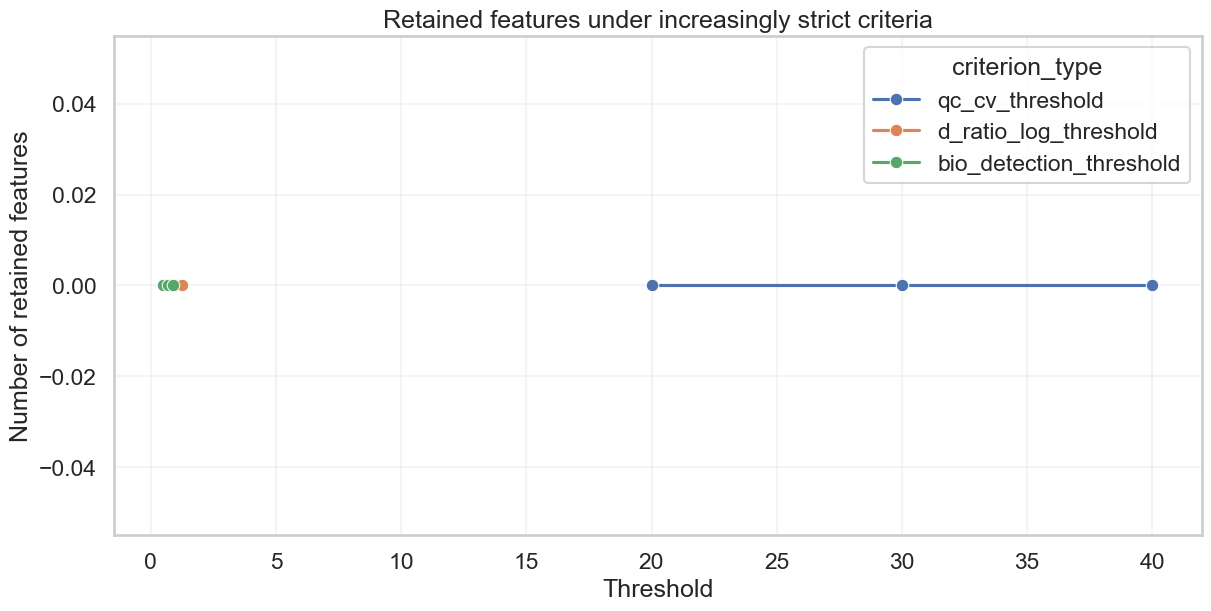

In [22]:
fig = plot_technical_vs_biological_metrics(
    technical_biological_metrics=technical_biological_metrics,
    qc_cv_threshold=30.0,
)
plt.show()

fig = plot_acceptance_counts(acceptance_counts)
plt.show()

## Interpretation — technical versus biological variance

Taken at face value, the combined-batch technical metrics are poor: no feature satisfies the <30% QC-CV target and no feature passes the current all-batch acceptance grid. The D-ratio-style summaries also show that technical spread frequently exceeds biological spread when both batches are pooled together.

However, this result must be interpreted correctly. It does **not** mean that the biology in batch 1 is unusable. It means that **cross-batch technical variation dominates once batch 2 is included**, which is exactly what we already saw in the QC heatmap, QC PCA, and standard-tracking plots.

So this step gives a valuable conclusion, but not the naive one:
- the current full-experiment QC definition is too heterogeneous for direct feature filtering,
- batch 2 should not be pooled with batch 1 for biomarker selection,
- and Part B filtering should be recomputed on a batch 1 technical reference, or after an explicit batch-normalization strategy.

A smaller methodological observation also follows from the threshold-sensitivity table: a modest positive detection threshold is likely helpful, but simple transformation alone will not solve the batch 2 problem. The batch effect is too large.

**Conclusion:** technical variability dominates biological variability when both batches are combined. For downstream discovery, the correct move is to restrict the filtering logic to batch 1 rather than declaring the whole study unusable.

## Step 9 — Multivariate overview of samples

We compute PCA views of:
- all samples,
- batch 1 only,
- and batch 1 biological samples only.

This provides a global view of whether variation is dominated by class, batch, run order, or technical sample type, and helps flag multivariate outliers that were not obvious from univariate summaries.

In [23]:
pca_all_scores, pca_all_explained = compute_global_pca(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
)

pca_batch1_scores, pca_batch1_explained = compute_global_pca(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    batches=(1,),
)

pca_batch1_bio_scores, pca_batch1_bio_explained = compute_global_pca(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
    classes=("Dunn", "French", "LMU"),
    batches=(1,),
)

pca_all_scores = flag_pca_outliers(pca_all_scores)
pca_batch1_scores = flag_pca_outliers(pca_batch1_scores)
pca_batch1_bio_scores = flag_pca_outliers(pca_batch1_bio_scores)

display(pca_all_scores.loc[pca_all_scores["pca_outlier_flag"]].sort_values("pca_distance", ascending=False))
display(pca_batch1_scores.loc[pca_batch1_scores["pca_outlier_flag"]].sort_values("pca_distance", ascending=False))
display(pca_batch1_bio_scores.loc[pca_batch1_bio_scores["pca_outlier_flag"]].sort_values("pca_distance", ascending=False))

,sample,class,batch,order,PC1,PC2,pca_distance,pca_distance_robust_z,pca_outlier_flag
100,20241106-297-Blank5,B,1,103,-30.591059,-5.910269,39.011130,32.792630,True
101,20241106-297-Blank6,B,1,104,-30.482169,-5.874756,38.898173,32.694836,True
99,20241106-297-Blank4,B,1,102,-30.458388,-5.529192,38.824909,32.631407,True
0,20241106-297-Blank1,B,1,1,-30.325640,-5.902589,38.747533,32.564417,True
1,20241106-297-Blank2,B,1,2,-30.356917,-5.466767,38.715747,32.536898,True
102,20241113-300-Blank1,B,2,105,-30.234878,-5.442970,38.591589,32.429406,True
2,20241106-297-Blank3,B,1,3,-30.064898,-5.793640,38.473493,32.327163,True
123,20241113-300-Blank6,B,2,126,-30.215698,-4.531972,38.457209,32.313064,True
122,20241113-300-Blank5,B,2,125,-30.175225,-4.496421,38.412928,32.274727,True
121,20241113-300-Blank4,B,2,124,-30.172141,-3.911580,38.347466,32.218052,True


,sample,class,batch,order,PC1,PC2,pca_distance,pca_distance_robust_z,pca_outlier_flag
100,20241106-297-Blank5,B,1,103,-57.203850,-2.897324,61.264997,74.767430,True
101,20241106-297-Blank6,B,1,104,-57.046356,-3.195332,61.121149,74.588310,True
99,20241106-297-Blank4,B,1,102,-56.994573,-2.858597,61.054262,74.505022,True
1,20241106-297-Blank2,B,1,2,-56.822666,-2.994881,60.888440,74.298538,True
0,20241106-297-Blank1,B,1,1,-56.801735,-3.326941,60.883260,74.292087,True
2,20241106-297-Blank3,B,1,3,-56.405568,-3.466220,60.494776,73.808343,True
3,20241106-297-Experimental_Blank,SS,1,4,-45.418996,21.354960,53.950863,65.659794,True
4,20241106-297-Diluted-QC1,dQC,1,7,-0.356495,2.038627,4.938319,4.628859,True
61,20241106-297-LMU-6,LMU,1,64,0.698368,3.127952,4.746598,4.390125,True
60,20241106-297-Dunn-13,Dunn,1,63,-0.152801,1.858230,4.674249,4.300036,True


,sample,class,batch,order,PC1,PC2,pca_distance,pca_distance_robust_z,pca_outlier_flag
52,20241106-297-LMU-21,LMU,1,71,-28.391230,0.834669,27.575810,4.097623,True
9,20241106-297-Dunn-21,Dunn,1,24,24.785887,1.223221,25.663828,3.673838,True


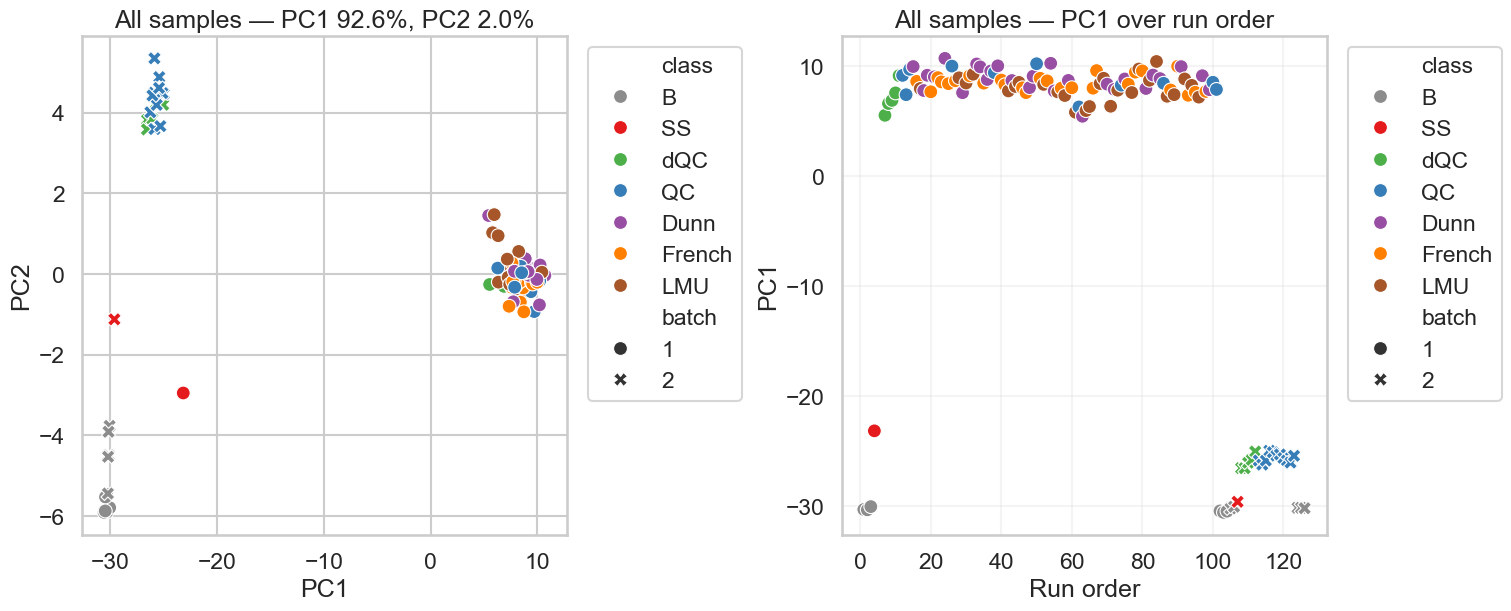

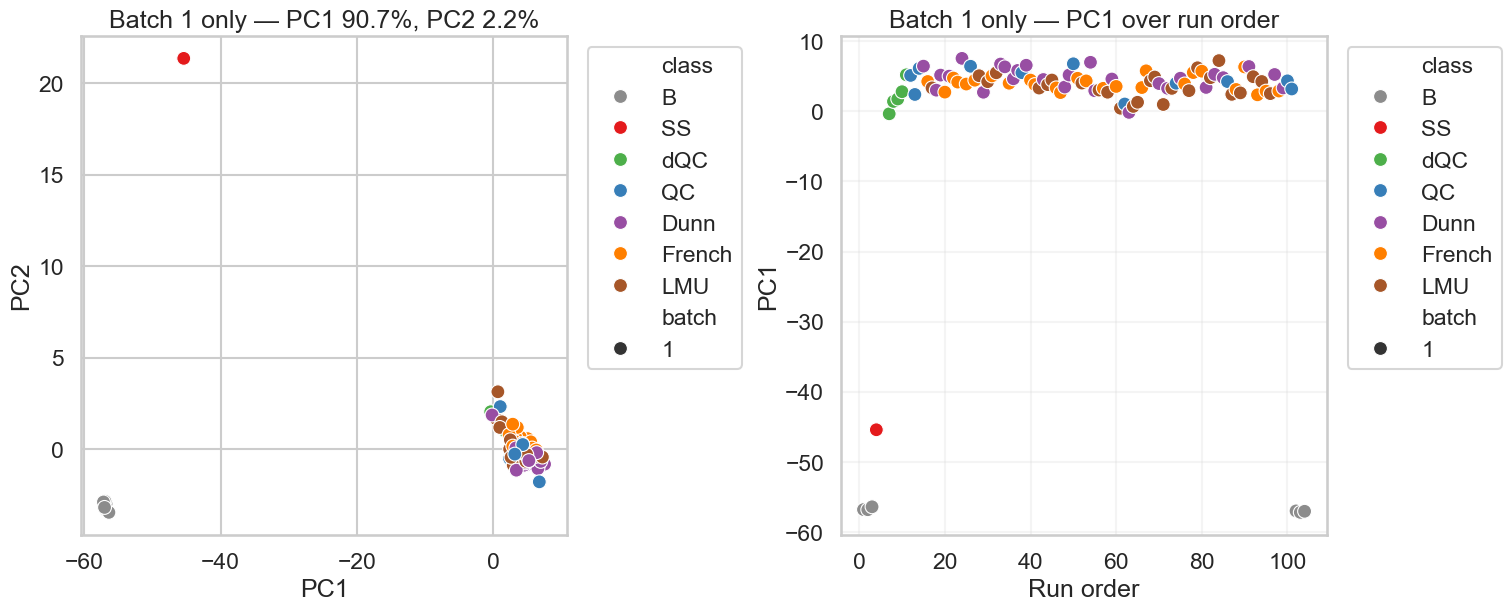

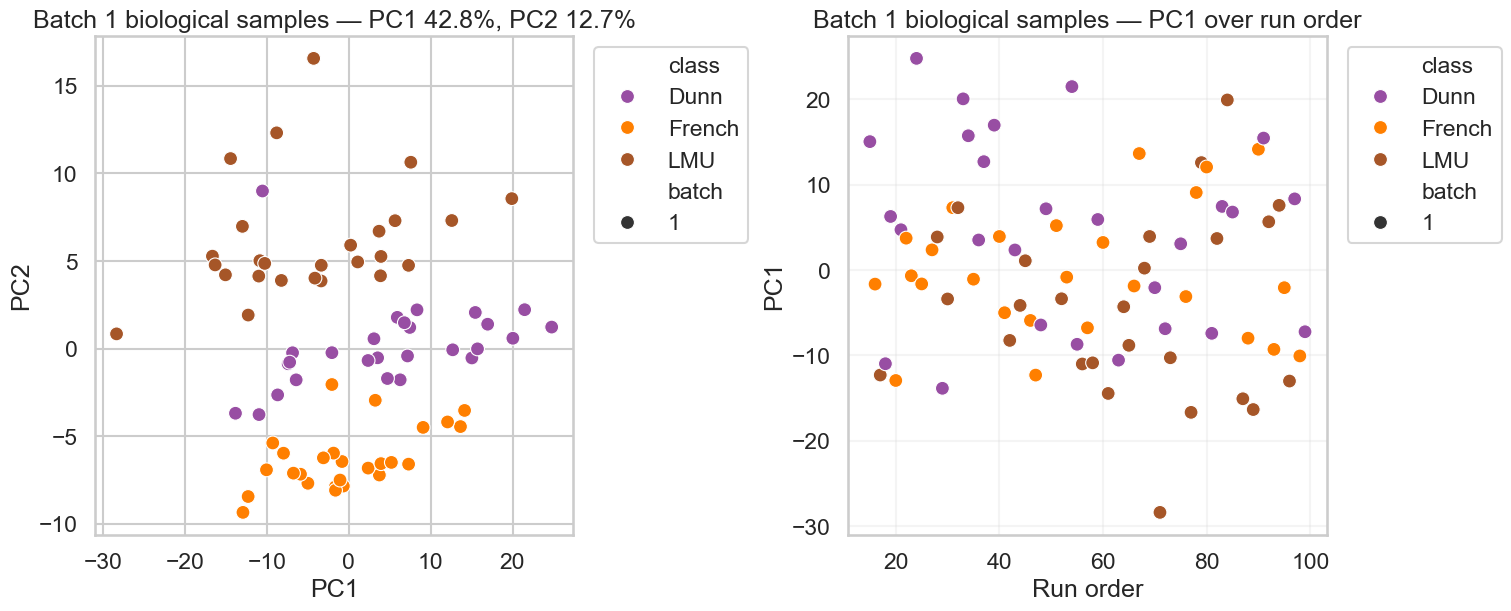

In [24]:
fig = plot_global_pca(
    pca_scores=pca_all_scores,
    explained_variance_ratio=pca_all_explained,
    title_prefix="All samples",
)
plt.show()

fig = plot_global_pca(
    pca_scores=pca_batch1_scores,
    explained_variance_ratio=pca_batch1_explained,
    title_prefix="Batch 1 only",
)
plt.show()

fig = plot_global_pca(
    pca_scores=pca_batch1_bio_scores,
    explained_variance_ratio=pca_batch1_bio_explained,
    title_prefix="Batch 1 biological samples",
)
plt.show()

## Interpretation — multivariate structure and sample outliers

The PCA views summarize the experiment very clearly.

For all samples together, the dominant structure is technical: blanks, system-suitability samples, and batch 2 QC-like samples separate strongly from batch 1 biological samples. This confirms that the main axis of variation in the full dataset is not disease biology but sample type / batch state.

For batch 1 only, technical sample types still separate from biological samples, but the biological cloud is much more coherent. When we restrict further to batch 1 biological samples only, the class structure becomes visible: the three biological classes are not perfectly separated, but they do not collapse into one indistinguishable cloud either. That is compatible with a realistic biomarker-discovery setting.

The PCA outlier table also needs context. Blanks and experimental blanks are expected multivariate outliers because they are intentionally different sample types. Among batch 1 biological samples, only a very small number of points look unusual enough to warrant sensitivity analysis, not automatic removal.

**Conclusion:** multivariate structure supports biomarker discovery in batch 1. The dominant artifact in the full dataset is the batch 2 technical shift, not an absence of biological signal.

## Part A synthesis — decision memo

### Is the experiment exploitable for biomarker discovery?
**Yes, but only after restricting the biological discovery workflow to batch 1.**  
Batch 1 contains the biological samples, has strong signal intensity, high feature detection, consistent standard detection, and interpretable biological structure. Batch 2, in contrast, shows a major loss of signal and standard detectability and should be treated as a technical-only diagnostic batch rather than pooled with batch 1.

### Main findings by assignment question

1. **Isomers:** yes, many putative isomer-like pairs are present.
2. **Isotopes / adducts:** yes, many putative isotope-like pairs are present.
3. **Correlation between related peaks:** often strong, especially for isotope-like pairs; these features are not all independent.
4. **Detection support:** excellent in batch 1 biology and batch 1 QC-like samples; poor in batch 2 QC-like samples.
5. **Contamination:** present but limited; not the dominant issue.
6. **Standards:** consistent in batch 1, largely lost in batch 2.
7. **Intensity distributions / run-order trends:** batch 1 is broadly stable; the dominant shift is between batches rather than gradual within-batch drift.
8. **QCs between batches / measurement stability:** poor across both batches combined, acceptable enough within batch 1.

### Practical consequence for Part B
For biomarker discovery and processing, the defensible strategy is:
- keep only **batch 1 biological samples** (`Dunn`, `French`, `LMU`) for class comparison,
- use **batch 1 QC / dQC** as the technical reference for filtering,
- avoid pooling batch 2 into QC-CV or D-ratio filtering,
- flag blank-associated and carryover-prone features,
- prioritize features with strong biological detection support and m/z in the target glycan range,
- and be careful not to over-count highly correlated feature families.

### Bottom line
The study contains usable biological signal, but only after acknowledging that batch 2 is technically inconsistent with batch 1. The central Part A conclusion is therefore not “the experiment failed,” but rather: **the experiment is exploitable for biomarker discovery in batch 1, while batch 2 mainly serves as evidence of platform instability.**

In [25]:
from src.eda import (
    subset_task1_inputs,
    make_batch1_operational_subset,
)

# Part A.2 — Batch-1 operational EDA for downstream filtering

The full-experiment EDA showed that batch 2 is technically inconsistent with batch 1 and does not contain biological samples. For downstream filtering and biomarker discovery, we therefore re-derive the key operational metrics on batch 1 only.

This second pass is not a replacement for the full Part A analysis. It is the operational extension of Part A that provides the actual inputs for Part B and Part C.


A key result from Part A is that the combined-batch technical summaries are dominated by the batch 2 signal collapse. Therefore, the feature filtering logic for Part B should be derived from **batch 1 only**, using batch 1 biological samples for class support and batch 1 QC-like samples for technical reproducibility. This keeps the filtering criteria aligned with the actual biomarker-discovery setting.

## Build the batch-1 operational subset

We keep all batch 1 classes needed for operational filtering:
- blanks (`B`)
- system suitability (`SS`)
- diluted QC / QC (`dQC`, `QC`)
- biological classes (`Dunn`, `French`, `LMU`)

In [26]:
batch1_data_matrix, batch1_acquisition_list = make_batch1_operational_subset(
    data_matrix=data_matrix,
    acquisition_list=acquisition_list,
)

display(batch1_acquisition_list.head())
display(
    batch1_acquisition_list.groupby("class")
    .size()
    .rename("n_samples")
    .reset_index()
    .sort_values("class")
)

,sample,class,id,order,batch
0,20241106-297-Blank1,B,20241106-297-Blank1,1,1
1,20241106-297-Blank2,B,20241106-297-Blank2,2,1
2,20241106-297-Blank3,B,20241106-297-Blank3,3,1
3,20241106-297-Experimental_Blank,SS,20241106-297-Experimental_Blank,4,1
4,20241106-297-Diluted-QC1,dQC,20241106-297-Diluted-QC1,7,1


,class,n_samples
0,B,6
1,Dunn,27
2,French,26
3,LMU,26
4,QC,11
5,SS,1
6,dQC,5


## Batch-1 operational Step 2 — sample-level signal checks

We recompute the sample-level global metrics on batch 1 only so that outlier screening and class summaries are not distorted by the batch 2 technical collapse.

In [27]:
batch1_sample_metrics = compute_sample_metrics(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    detection_threshold=0.0,
)

batch1_sample_metrics = flag_sample_outliers(batch1_sample_metrics)
batch1_sample_summary = summarise_sample_metrics(batch1_sample_metrics)

display(batch1_sample_summary)
display(
    batch1_sample_metrics.loc[
        batch1_sample_metrics["class"].isin(["Dunn", "French", "LMU"]) &
        batch1_sample_metrics["any_outlier_flag"]
    ].sort_values(["class", "order"])
)

,batch,class,n_samples,median_total_signal,mean_total_signal,median_detected_features,mean_detected_features,median_zero_fraction,mean_corr_to_class_median
0,1,B,6,24.680257,26.663723,5.5,4.833333,0.978175,0.382450
1,1,Dunn,27,813127.569783,815796.883189,251.0,250.407407,0.003968,0.983770
2,1,French,26,768329.059938,774511.868791,252.0,251.500000,0.000000,0.984857
3,1,LMU,26,741400.934603,747289.831068,249.0,248.384615,0.011905,0.969052
4,1,QC,11,773821.399796,795185.964492,251.0,250.545455,0.003968,0.973148
5,1,SS,1,241703.338905,241703.338905,64.0,64.000000,0.746032,1.000000
6,1,dQC,5,633451.301376,663226.167046,251.0,250.200000,0.003968,0.980668


,sample,total_signal,log10_total_signal_plus1,detected_features,detection_rate,zero_fraction,mean_feature_intensity_nonzero,class,id,order,batch,spearman_corr_to_class_median,log10_total_signal_plus1_robust_z,detected_features_robust_z,zero_fraction_robust_z,spearman_corr_to_class_median_robust_z,outlier_total_signal,outlier_detected_features,outlier_zero_fraction,outlier_class_profile,any_outlier_flag
60,20241106-297-Dunn-13,691702.114806,5.839920,245,0.972222,0.027778,2823.273938,Dunn,20241106-297-Dunn-13,63,1,0.846488,-0.662769,-4.0470,4.0470,-13.684949,False,True,True,True,True
92,20241106-297-French-23,745072.402200,5.872199,250,0.992063,0.007937,2980.289609,French,20241106-297-French-23,95,1,0.943366,-0.193894,-0.6745,0.6745,-4.292230,False,False,False,True,True
58,20241106-297-LMU-9,634675.543229,5.802552,247,0.980159,0.019841,2569.536612,LMU,20241106-297-LMU-9,61,1,0.883631,-1.205550,-2.6980,2.6980,-10.083756,False,False,False,True,True
61,20241106-297-LMU-6,777244.619973,5.890558,243,0.964286,0.035714,3198.537531,LMU,20241106-297-LMU-6,64,1,0.852426,0.072784,-5.3960,5.3960,-13.109211,False,True,True,True,True
62,20241106-297-LMU-23,698043.031233,5.843883,243,0.964286,0.035714,2872.605067,LMU,20241106-297-LMU-23,65,1,0.882478,-0.605203,-5.3960,5.3960,-10.195548,False,True,True,True,True
91,20241106-297-LMU-16,843317.433482,5.925992,246,0.976190,0.023810,3428.119648,LMU,20241106-297-LMU-16,94,1,0.949337,0.587473,-3.3725,3.3725,-3.713369,False,False,False,True,True
93,20241106-297-LMU-18,657632.785734,5.817984,244,0.968254,0.031746,2695.216335,LMU,20241106-297-LMU-18,96,1,0.967815,-0.981396,-4.7215,4.7215,-1.921882,False,True,True,False,True


C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:273: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:301: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:313: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


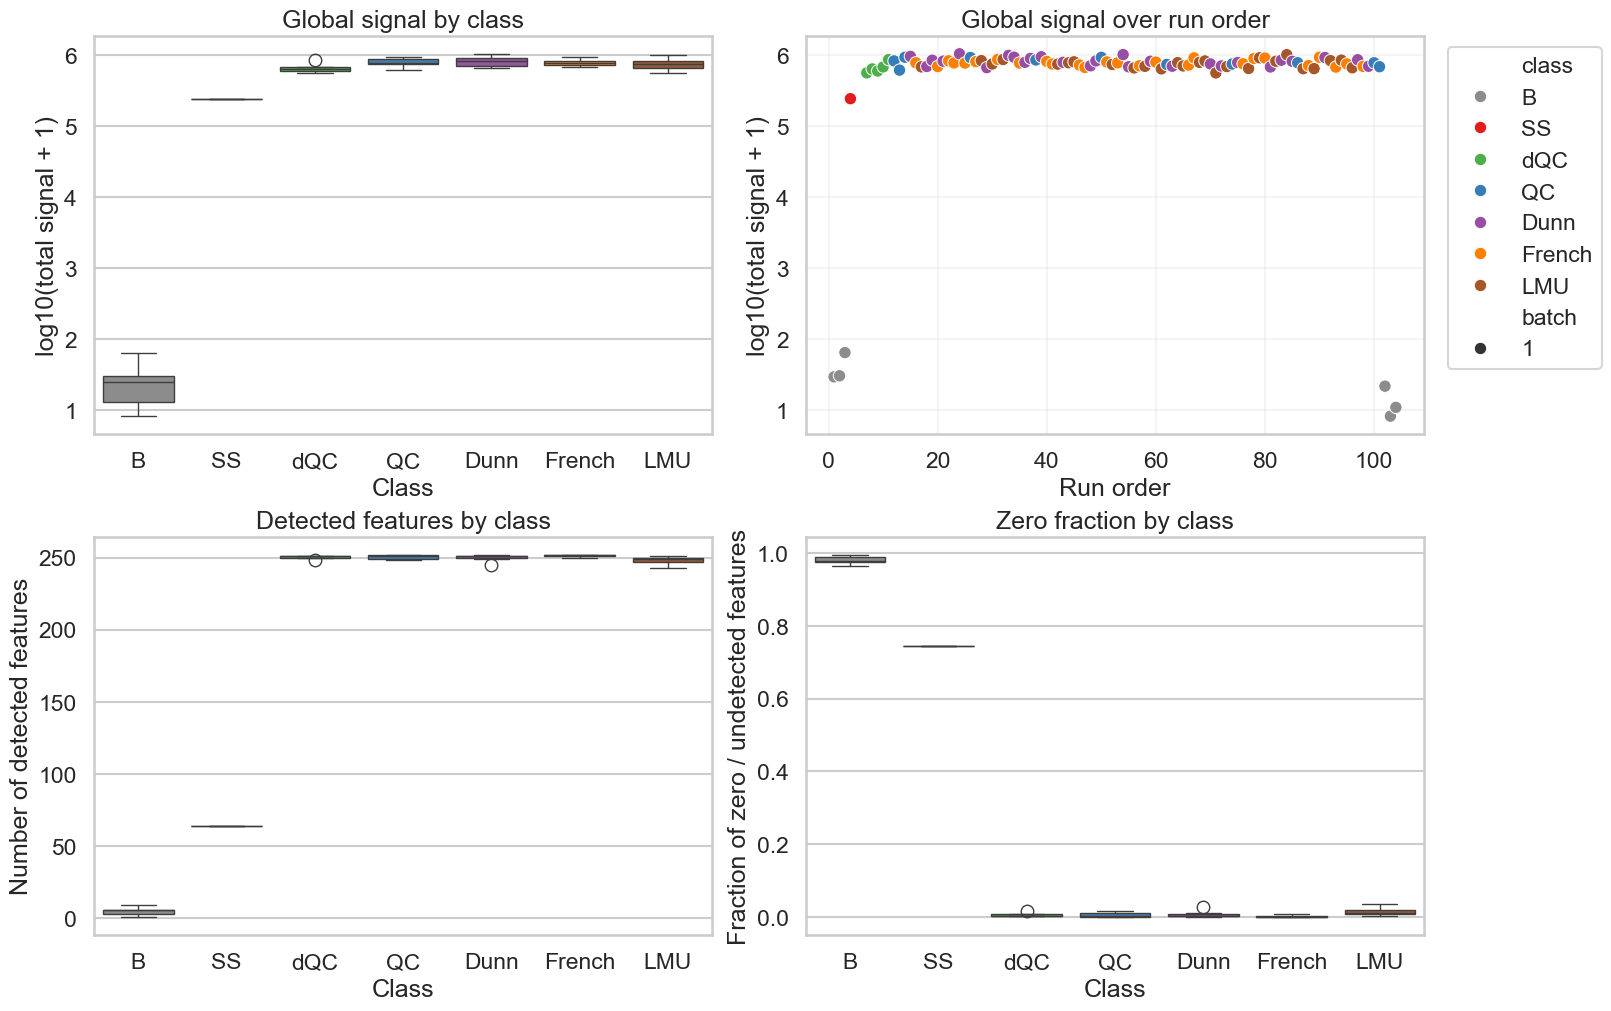

In [28]:
fig = plot_global_signal_health(batch1_sample_metrics)
plt.show()

## Batch-1 operational Step 3 — QC-centered stability analysis

We recompute the QC reproducibility metrics using only batch 1 `QC` and `dQC` samples. These are the operational technical references that should feed downstream feature filtering.

In [29]:
batch1_qc_feature_metrics = compute_qc_feature_metrics(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    feature_metadata=feature_metadata,
    qc_classes=("QC", "dQC"),
    detection_threshold=0.0,
)

batch1_qc_summary = summarise_qc_metrics(
    batch1_qc_feature_metrics,
    cv_threshold=30.0,
)

batch1_qc_corr, batch1_qc_sample_info = compute_qc_sample_correlations(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    qc_classes=("QC", "dQC"),
    method="spearman",
)

batch1_qc_pca_scores, batch1_qc_pca_explained = compute_qc_pca(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    qc_classes=("QC", "dQC"),
)

display(batch1_qc_summary)
display(batch1_qc_feature_metrics.head(20))
display(
    batch1_qc_feature_metrics.sort_values("qc_cv_pct", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(batch1_qc_sample_info)
display(batch1_qc_pca_scores.head())

n_features                                 252.000000
median_qc_cv_pct                            27.695695
mean_qc_cv_pct                              33.428469
n_features_qc_cv_below_threshold           159.000000
fraction_features_qc_cv_below_threshold      0.630952
median_qc_detection_rate                     1.000000
Name: value, dtype: float64

,feature,n_qc_samples,qc_detection_rate,qc_mean_intensity,qc_median_intensity,qc_std_intensity,qc_cv_pct,qc_mean_intensity_batch1,qc_cv_pct_batch1,qc_order_spearman_rho,qc_order_spearman_abs,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-001,16,1.0,2225.536944,2201.166438,176.581812,7.934346,2225.536944,7.934346,0.197059,0.197059,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
1,FT-003,16,1.0,3676.387148,3701.451652,309.733126,8.424932,3676.387148,8.424932,0.308824,0.308824,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
2,FT-000,16,1.0,1524.569351,1507.524169,130.053821,8.530528,1524.569351,8.530528,0.341176,0.341176,359.108768,359.130591,359.090122,0.010955,543.846374,561.270879,546.697803,539.941156,528.714227,1.683901
3,FT-010,16,1.0,29386.320269,29919.911886,3159.446340,10.751419,29386.320269,10.751419,-0.347059,0.347059,1048.724800,1048.785954,1048.669876,0.030825,753.824614,789.134640,756.436012,751.049814,736.919631,1.286855
4,FT-009,16,1.0,15977.066281,16465.635063,1868.837336,11.696999,15977.066281,11.696999,-0.379412,0.379412,1049.732664,1049.793639,1049.679381,0.030903,753.593752,783.262112,756.185217,751.129772,737.980813,1.236249
5,FT-008,16,1.0,6149.202168,6336.595825,762.996827,12.408062,6149.202168,12.408062,-0.405882,0.405882,1050.739664,1050.800543,1050.686090,0.031277,753.457003,778.235971,756.242861,750.762498,739.039389,1.297824
6,FT-012,16,1.0,1649.266788,1662.347705,217.115990,13.164395,1649.266788,13.164395,-0.270588,0.270588,1210.824056,1210.895560,1210.762440,0.034826,874.606710,886.937566,876.938569,872.100685,862.293499,1.250548
7,FT-101,16,1.0,43239.084538,44013.196836,5722.976997,13.235657,43239.084538,13.235657,0.455882,0.455882,1222.780065,1222.853416,1222.716915,0.035492,1300.021421,1340.645171,1302.407114,1297.540547,1283.562887,1.204843
8,FT-089,16,1.0,2032.678385,1940.479729,270.379265,13.301625,2032.678385,13.301625,0.241176,0.241176,1233.281672,1233.354455,1233.218062,0.035494,1299.489633,1318.851755,1301.533847,1296.959919,1284.791292,1.216343
9,FT-007,16,1.0,1879.438144,1946.941407,256.183133,13.630836,1879.438144,13.630836,-0.482353,0.482353,1051.742823,1051.806842,1051.688477,0.029811,753.193130,769.283091,755.954962,750.532679,740.815522,1.293041


,feature,n_qc_samples,qc_detection_rate,qc_mean_intensity,qc_median_intensity,qc_std_intensity,qc_cv_pct,qc_mean_intensity_batch1,qc_cv_pct_batch1,qc_order_spearman_rho,qc_order_spearman_abs,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-173,16,0.7500,2140.430822,162.121326,5566.127295,260.047054,2140.430822,260.047054,-0.097780,0.097780,887.645627,887.678467,887.600614,0.023116,639.907400,651.919421,643.893839,635.770774,634.336944,1.909012
1,FT-132,16,1.0000,183.035962,94.625573,333.020087,181.942435,183.035962,181.942435,-0.129412,0.129412,1088.354986,1088.423559,1088.296632,0.034139,1438.809837,1443.922299,1441.288860,1435.897107,1431.058061,1.160635
2,FT-199,16,1.0000,200.389576,122.071196,336.497149,167.921484,200.389576,167.921484,0.114706,0.114706,1223.794330,1223.847789,1223.732886,0.032090,1273.446642,1280.967369,1276.269530,1270.774468,1268.557217,1.287028
3,FT-141,16,1.0000,888.596981,245.982178,1487.498154,167.398515,888.596981,167.398515,0.108824,0.108824,1223.295151,1223.368163,1223.223485,0.037032,1273.683493,1281.605744,1276.293562,1270.708652,1268.696712,1.306203
4,FT-013,16,0.8125,360.905665,157.695694,572.361271,158.590271,360.905665,158.590271,-0.227140,0.227140,1210.827050,1210.896593,1210.757497,0.034829,899.723393,910.341839,902.505364,896.739952,892.597835,1.520345
5,FT-126,16,1.0000,113.854181,74.147350,168.139271,147.679487,113.854181,147.679487,0.176471,0.176471,1089.358935,1089.414818,1089.302112,0.031465,1439.054183,1443.902579,1441.775372,1435.925620,1431.709453,1.587631
6,FT-174,16,0.9375,37.484657,26.054441,44.315036,118.221798,37.484657,118.221798,-0.029412,0.029412,1210.830470,1210.900611,1210.763404,0.039324,928.694830,936.654435,933.254237,923.405274,921.758979,2.229371
7,FT-079,16,1.0000,85.729076,58.752507,101.033196,117.851727,85.729076,117.851727,0.376471,0.376471,1077.209362,1077.278063,1077.145710,0.033821,1186.459409,1193.399425,1189.507364,1183.667336,1179.035132,1.460963
8,FT-183,16,1.0000,385.206653,210.185543,440.829586,114.439764,385.206653,114.439764,0.191176,0.191176,1026.192891,1026.253869,1026.133604,0.029959,1107.040420,1118.291007,1109.781604,1104.496140,1102.969804,1.482488
9,FT-246,16,0.7500,191.210208,126.023377,207.407813,108.471098,191.210208,108.471098,0.352602,0.352602,886.640677,886.688516,886.593355,0.025146,640.780607,655.650127,645.218960,636.134805,634.661402,1.843087


,sample,batch,class,order
0,20241106-297-Diluted-QC1,1,dQC,7
1,20241106-297-Diluted-QC2,1,dQC,8
2,20241106-297-Diluted-QC3,1,dQC,9
3,20241106-297-Diluted-QC4,1,dQC,10
4,20241106-297-Diluted-QC5,1,dQC,11
5,20241106-297-QC1,1,QC,12
6,20241106-297-QC2,1,QC,13
7,20241106-297-QC3,1,QC,14
8,20241106-297-QC4,1,QC,26
9,20241106-297-QC5,1,QC,38


,sample,batch,class,order,PC1,PC2
0,20241106-297-Diluted-QC1,1,dQC,7,-25.459088,0.953626
1,20241106-297-Diluted-QC2,1,dQC,8,-15.717630,2.704423
2,20241106-297-Diluted-QC3,1,dQC,9,-17.326664,5.401250
3,20241106-297-Diluted-QC4,1,dQC,10,-7.605578,2.705571
4,20241106-297-Diluted-QC5,1,dQC,11,5.733188,5.795562


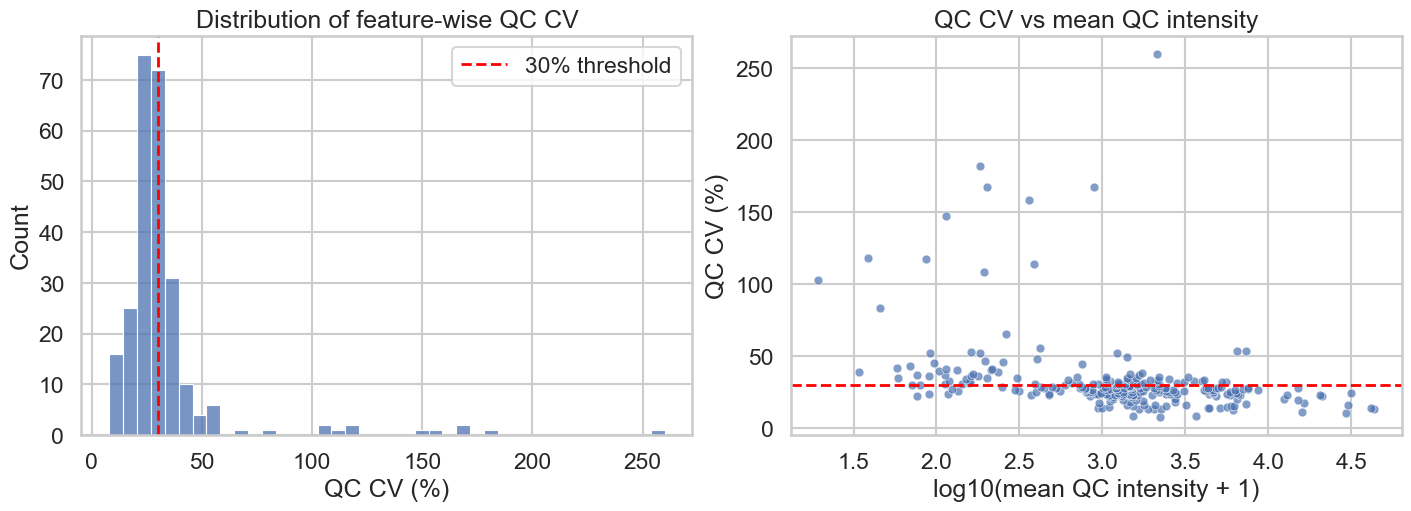

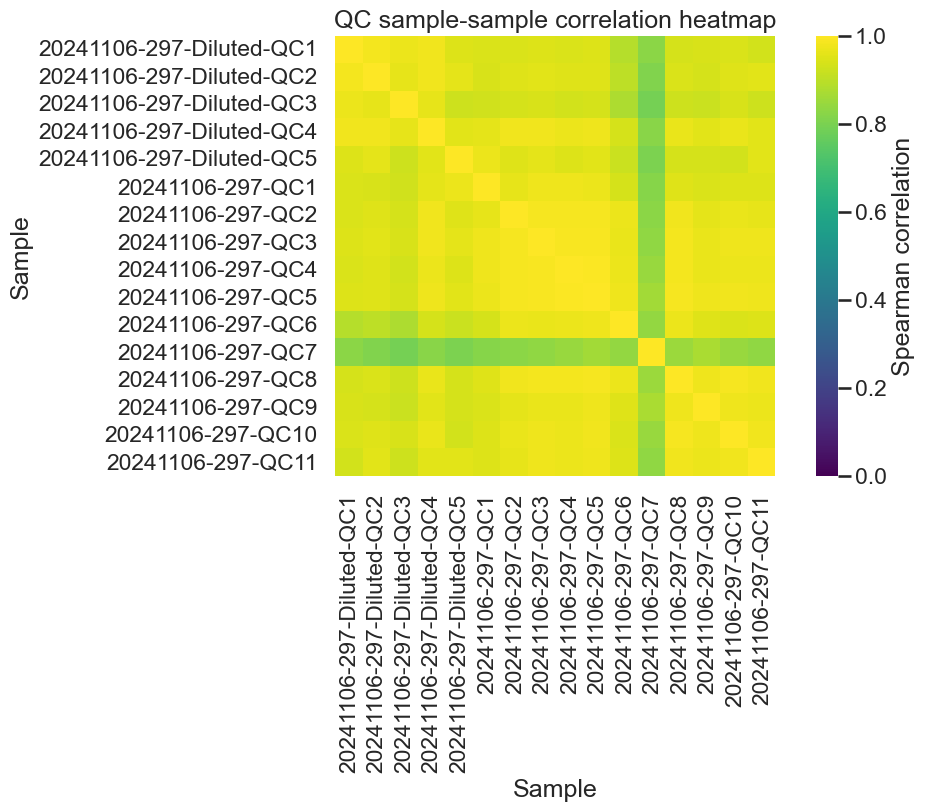

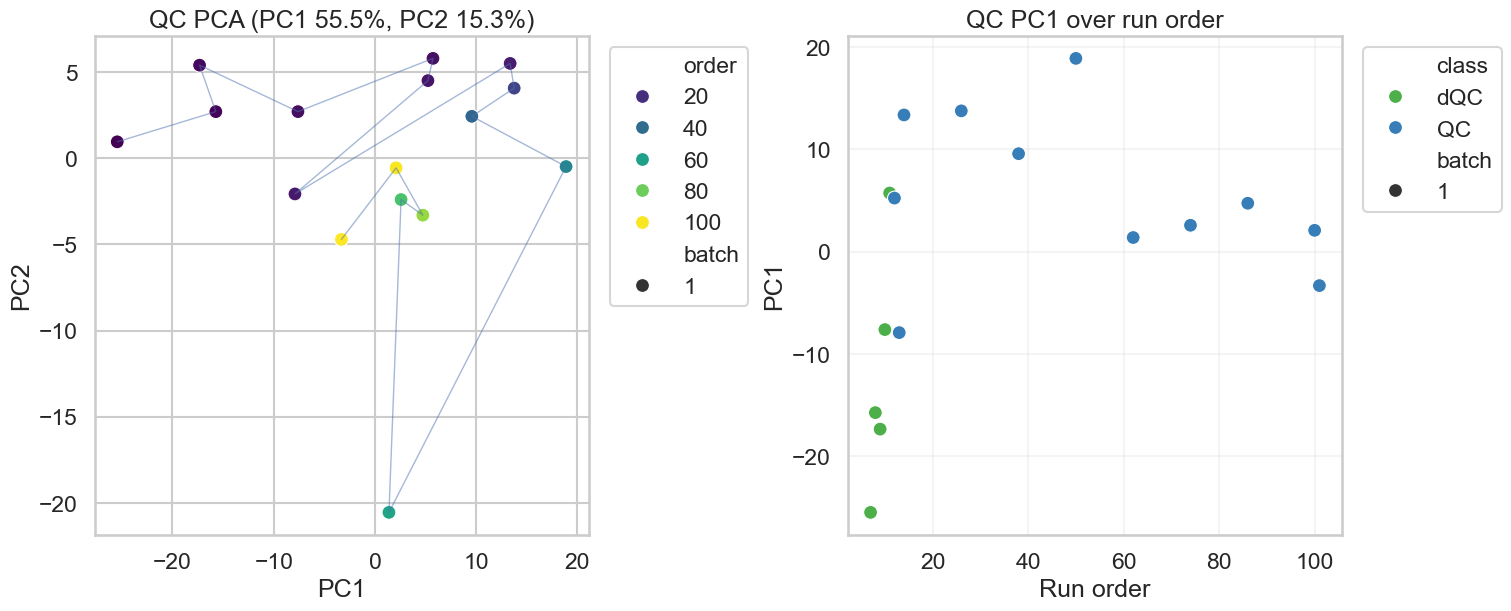

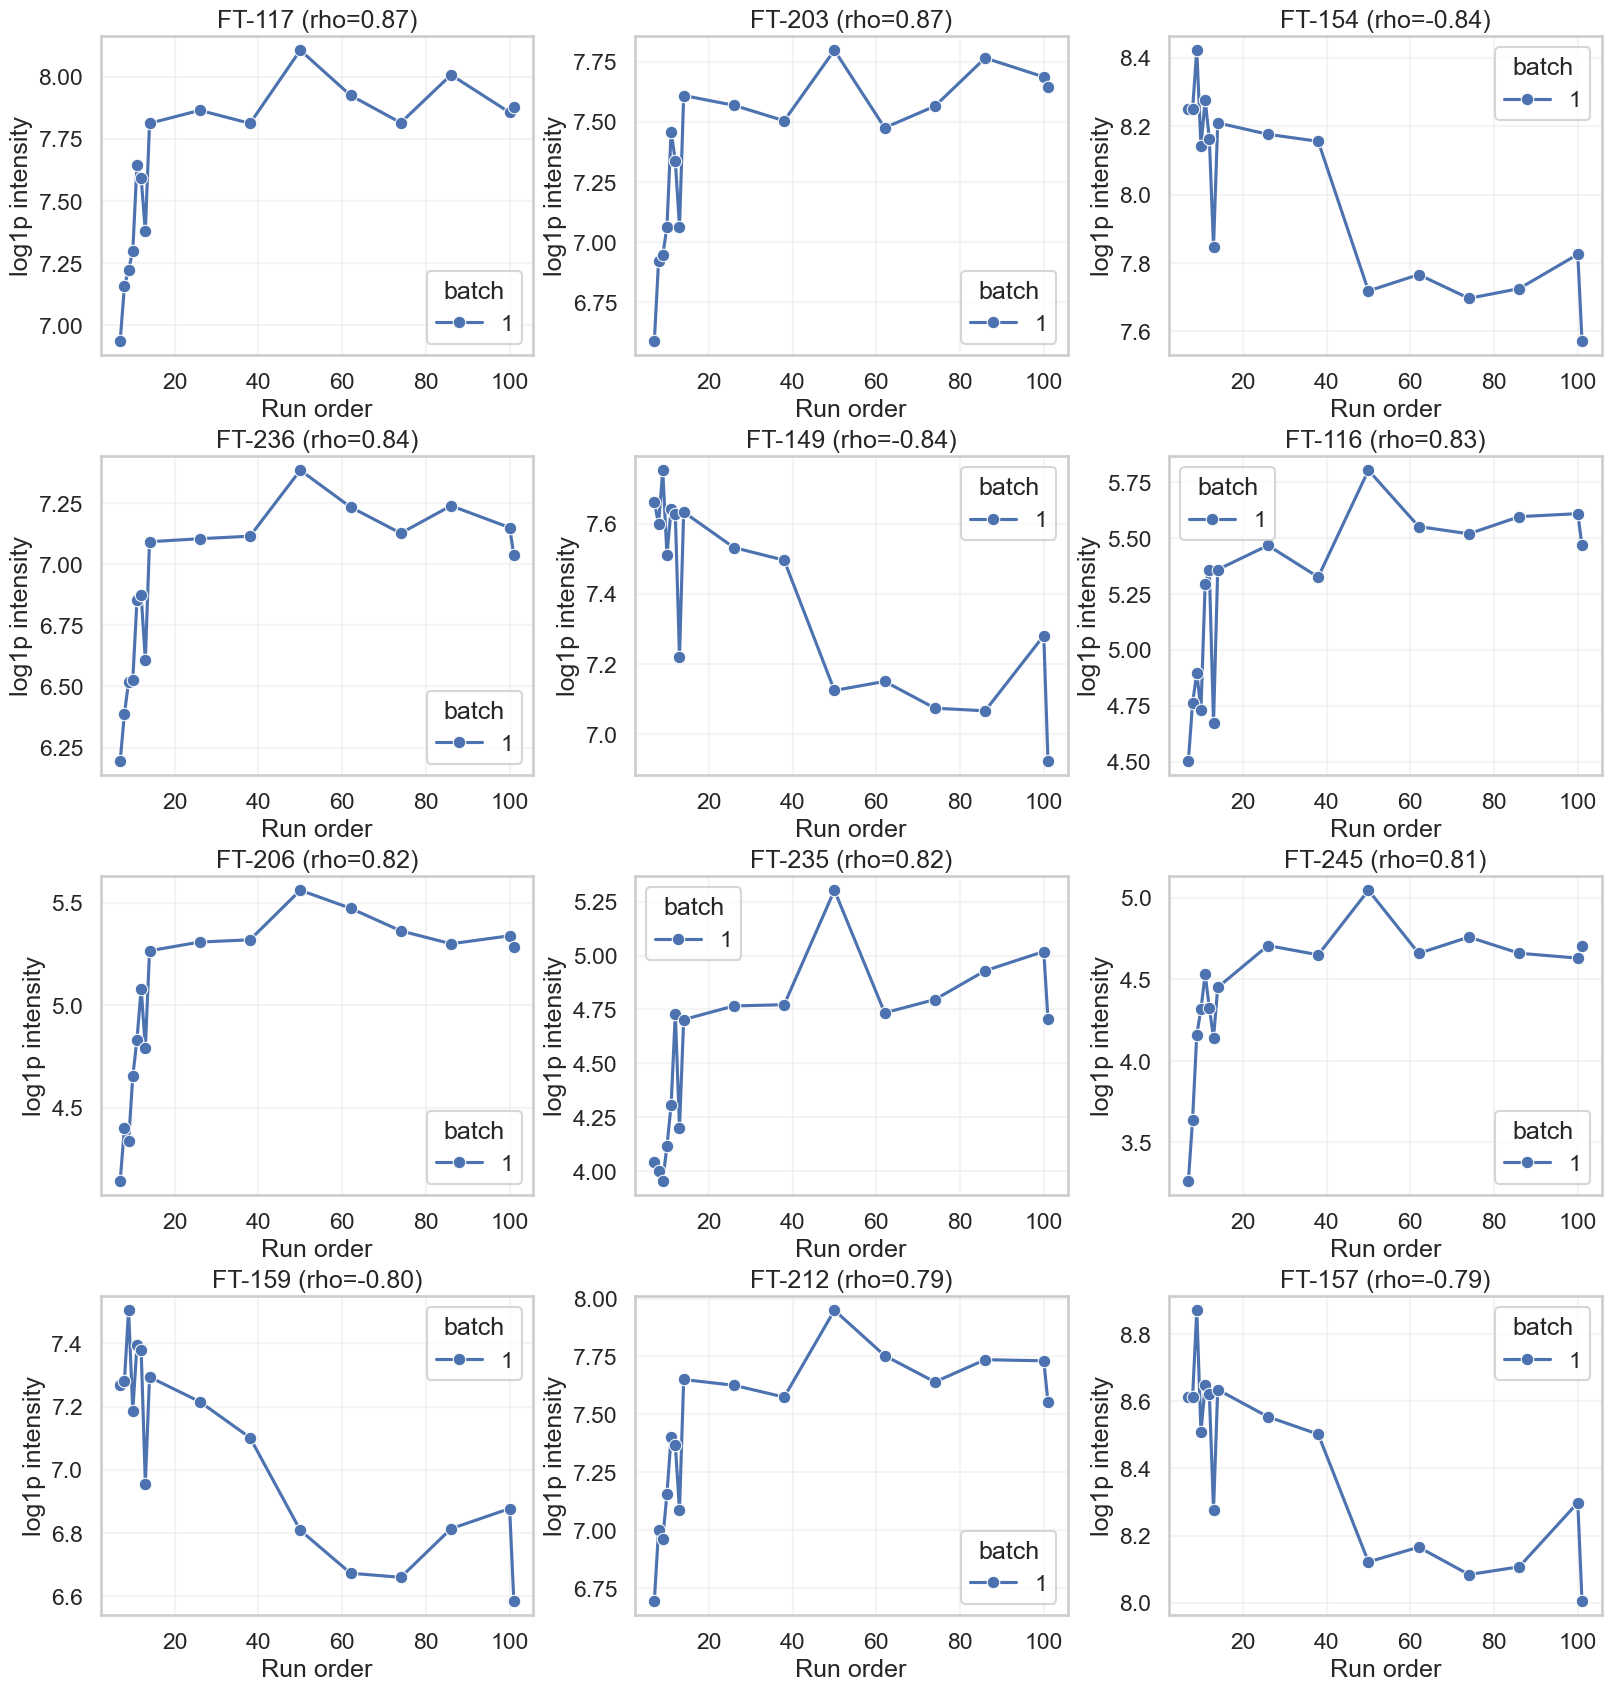

In [30]:
fig = plot_qc_cv_distribution(
    batch1_qc_feature_metrics,
    cv_threshold=30.0,
)
plt.show()

fig = plot_qc_correlation_heatmap(
    batch1_qc_corr,
    batch1_qc_sample_info,
)
plt.show()

fig = plot_qc_pca(
    batch1_qc_pca_scores,
    batch1_qc_pca_explained,
)
plt.show()

fig = plot_top_qc_drift_features(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    qc_feature_metrics=batch1_qc_feature_metrics,
    qc_classes=("QC", "dQC"),
    top_n=12,
)
plt.show()

## Batch-1 operational Step 4 — detection support and missingness

We recompute class-wise detection support and the RT/m/z detection landscape on batch 1 only. This makes the detection summaries relevant to the actual biological discovery cohort.

In [31]:
batch1_threshold_table = threshold_sensitivity_table(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    thresholds=(0.0, 1.0, 10.0, 100.0, 1000.0),
)

batch1_feature_detection_metrics = compute_feature_detection_metrics(
    data_matrix=batch1_data_matrix,
    feature_metadata=feature_metadata,
    acquisition_list=batch1_acquisition_list,
    detection_threshold=0.0,
)

display(batch1_threshold_table)
display(batch1_feature_detection_metrics.head(20))
display(
    batch1_feature_detection_metrics.sort_values("detection_rate__biological", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

,class,batch,mean,median,min,max,threshold
0,B,1,0.019180,0.021825,0.003968,0.035714,0.0
1,Dunn,1,0.993680,0.996032,0.972222,1.000000,0.0
2,French,1,0.998016,1.000000,0.992063,1.000000,0.0
3,LMU,1,0.985653,0.988095,0.964286,0.996032,0.0
4,QC,1,0.994228,0.996032,0.984127,1.000000,0.0
5,SS,1,0.253968,0.253968,0.253968,0.253968,0.0
6,dQC,1,0.992857,0.996032,0.984127,0.996032,0.0
7,B,1,0.018519,0.019841,0.003968,0.035714,1.0
8,Dunn,1,0.993533,0.996032,0.968254,1.000000,1.0
9,French,1,0.998016,1.000000,0.992063,1.000000,1.0


,feature,detection_rate__all,detection_rate__B,detection_rate__SS,detection_rate__dQC,detection_rate__QC,detection_rate__Dunn,detection_rate__French,detection_rate__LMU,detection_rate__biological,detection_rate__qc_like,detection_rate__blank,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-216,0.970588,0.666667,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.666667,1089.030600,1089.095920,1088.972675,0.031323,1438.932118,1444.116680,1440.781202,1436.371539,1431.385181,1.168489
1,FT-215,0.960784,0.500000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.500000,1089.027713,1089.084097,1088.973816,0.031877,1422.771628,1429.112757,1425.693322,1419.283552,1415.301223,1.443795
2,FT-001,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
3,FT-003,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-021,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,842.075679,842.122404,842.033148,0.024741,963.278928,991.406565,965.900100,960.787869,946.024793,1.272372
5,FT-035,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,924.125817,924.180160,924.077759,0.027241,1057.660785,1064.725997,1060.338482,1055.031178,1043.029404,1.238042
6,FT-078,0.950980,0.333333,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.333333,1077.205729,1077.269749,1077.150718,0.031513,1164.908119,1176.015187,1167.311426,1162.498746,1152.201798,1.193688
7,FT-079,0.950980,0.333333,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.333333,1077.209362,1077.278063,1077.145710,0.033821,1186.459409,1193.399425,1189.507364,1183.667336,1179.035132,1.460963
8,FT-135,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,1173.230112,1173.299758,1173.174174,0.033876,1442.994779,1461.533593,1446.522010,1439.689041,1429.716635,1.550736
9,FT-176,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,871.097203,871.146450,871.052143,0.026114,967.075674,981.001498,969.588802,964.557588,954.524106,1.183189


,feature,detection_rate__all,detection_rate__B,detection_rate__SS,detection_rate__dQC,detection_rate__QC,detection_rate__Dunn,detection_rate__French,detection_rate__LMU,detection_rate__biological,detection_rate__qc_like,detection_rate__blank,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-216,0.970588,0.666667,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.666667,1089.030600,1089.095920,1088.972675,0.031323,1438.932118,1444.116680,1440.781202,1436.371539,1431.385181,1.168489
1,FT-215,0.960784,0.500000,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.500000,1089.027713,1089.084097,1088.973816,0.031877,1422.771628,1429.112757,1425.693322,1419.283552,1415.301223,1.443795
2,FT-001,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,357.109546,357.130018,357.091871,0.010668,543.839157,563.021530,546.948017,540.038924,528.530311,1.662290
3,FT-003,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,355.111928,355.132772,355.093653,0.010508,543.995269,566.951285,547.164503,540.681882,526.943213,1.609071
4,FT-021,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,842.075679,842.122404,842.033148,0.024741,963.278928,991.406565,965.900100,960.787869,946.024793,1.272372
5,FT-035,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,924.125817,924.180160,924.077759,0.027241,1057.660785,1064.725997,1060.338482,1055.031178,1043.029404,1.238042
6,FT-078,0.950980,0.333333,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.333333,1077.205729,1077.269749,1077.150718,0.031513,1164.908119,1176.015187,1167.311426,1162.498746,1152.201798,1.193688
7,FT-079,0.950980,0.333333,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.333333,1077.209362,1077.278063,1077.145710,0.033821,1186.459409,1193.399425,1189.507364,1183.667336,1179.035132,1.460963
8,FT-135,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,1173.230112,1173.299758,1173.174174,0.033876,1442.994779,1461.533593,1446.522010,1439.689041,1429.716635,1.550736
9,FT-176,0.950980,0.166667,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.166667,871.097203,871.146450,871.052143,0.026114,967.075674,981.001498,969.588802,964.557588,954.524106,1.183189


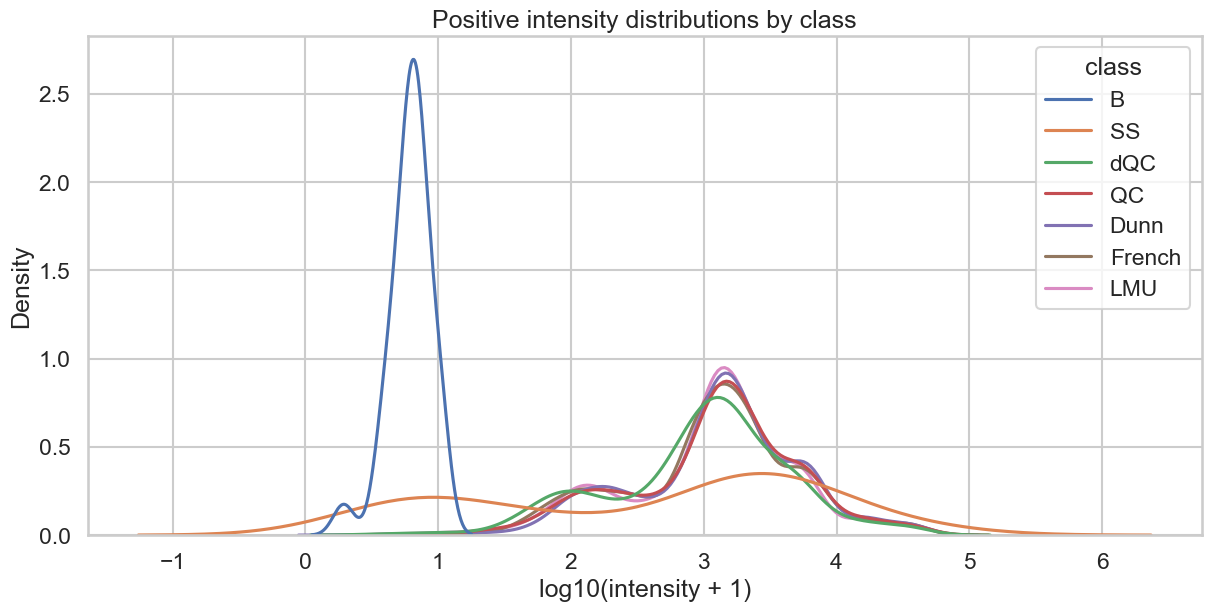

C:\Users\zakar\OneDrive\Bureau\ml-internship\src\eda.py:816: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


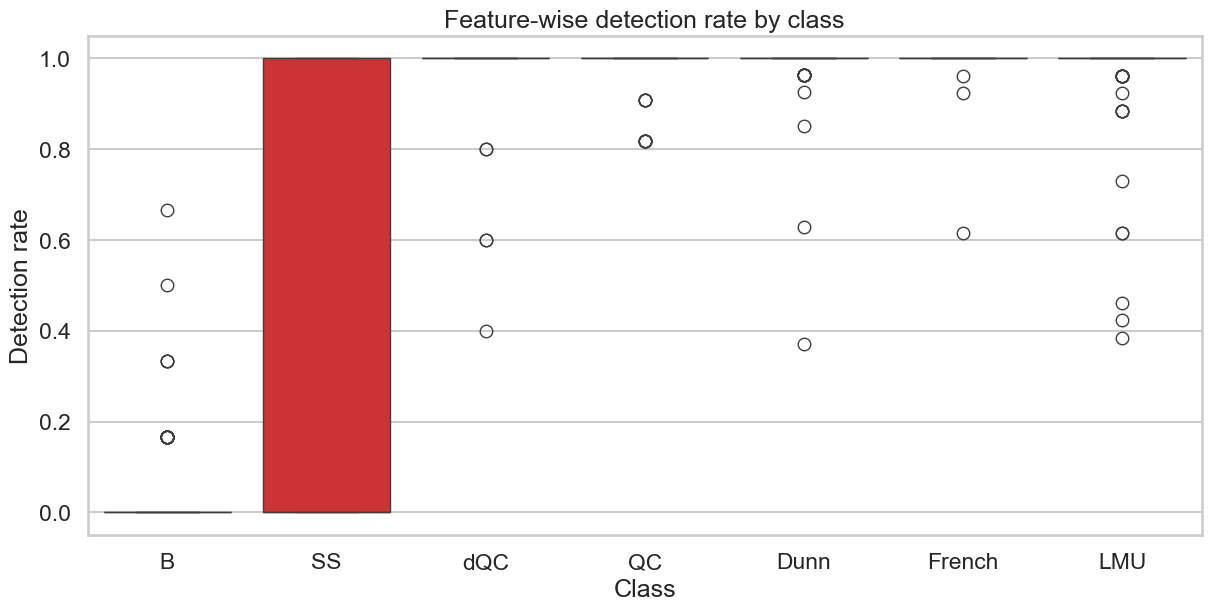

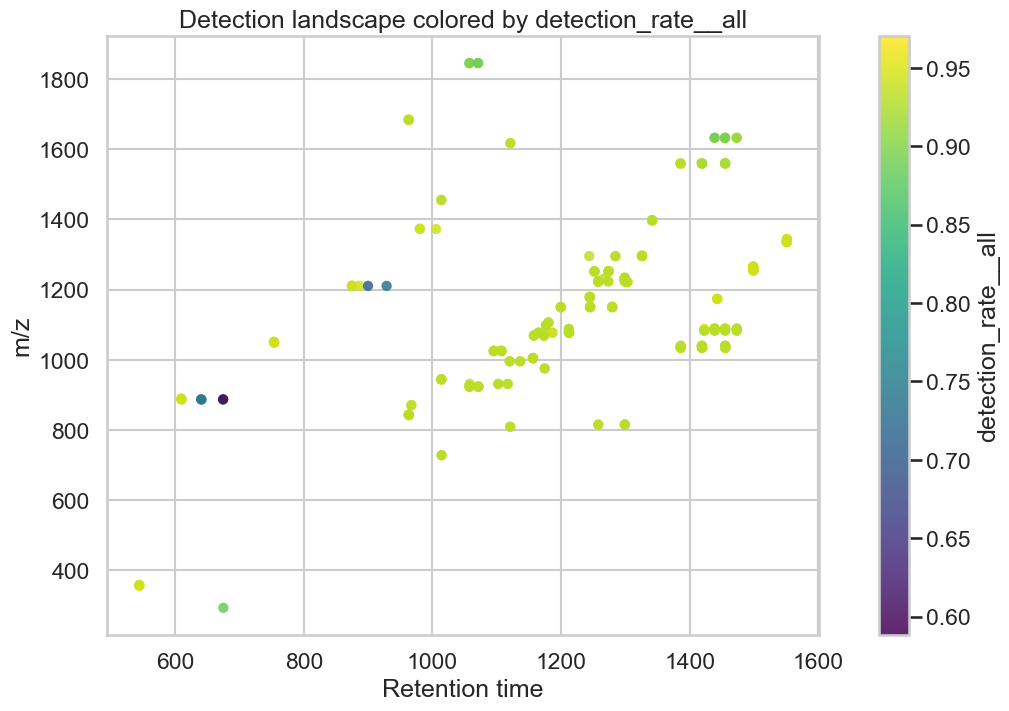

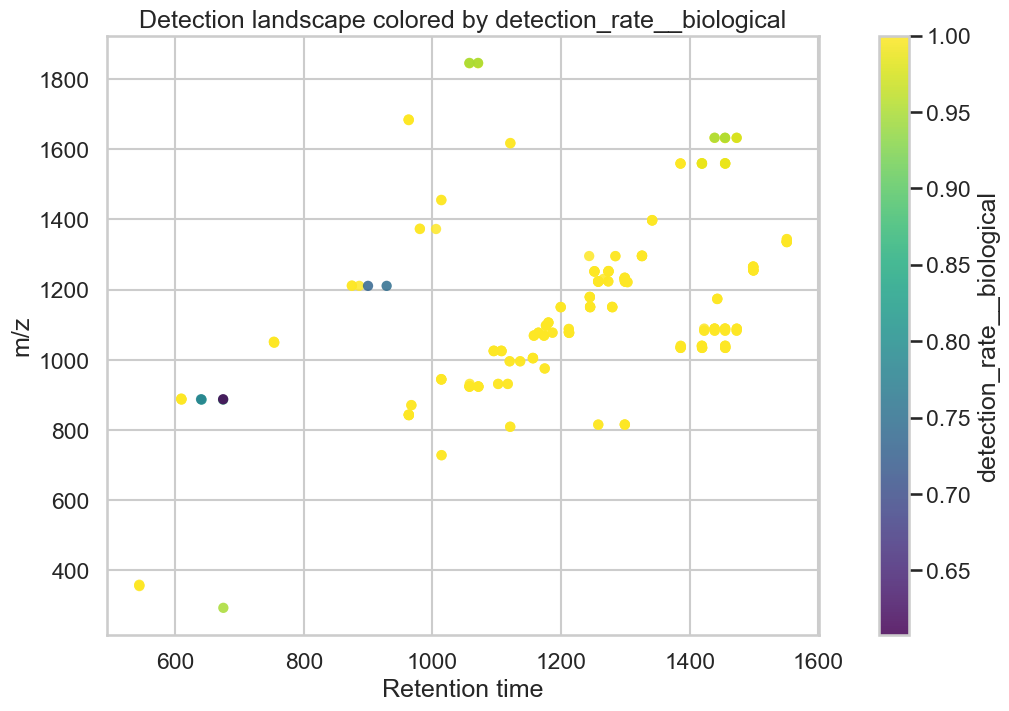

In [32]:
fig = plot_positive_intensity_distributions(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
)
plt.show()

fig = plot_detection_rate_by_class(batch1_feature_detection_metrics)
plt.show()

fig = plot_detection_landscape(
    batch1_feature_detection_metrics,
    rate_col="detection_rate__all",
)
plt.show()

fig = plot_detection_landscape(
    batch1_feature_detection_metrics,
    rate_col="detection_rate__biological",
)
plt.show()

## Batch-1 operational Step 5 — contamination and blank behavior

We recompute blank-vs-QC and blank-vs-biology metrics using batch 1 only, so that the contamination screen is aligned with the actual discovery cohort rather than the full experiment.

In [33]:
batch1_contamination_metrics = compute_contamination_metrics(
    data_matrix=batch1_data_matrix,
    feature_metadata=feature_metadata,
    acquisition_list=batch1_acquisition_list,
    detection_threshold=0.0,
    blank_classes=("B",),
    qc_classes=("QC", "dQC"),
    bio_classes=("Dunn", "French", "LMU"),
    blank_ratio_threshold=1.0,
    min_blank_detection_rate=0.1,
)

batch1_blank_carryover_proxy = compute_blank_carryover_proxy(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    blank_classes=("B",),
)

display(batch1_contamination_metrics.head(20))
display(
    batch1_contamination_metrics.loc[batch1_contamination_metrics["blank_dominant_flag"]]
    .reset_index(drop=True)
)
display(batch1_blank_carryover_proxy.head(20))

,feature,blank_mean_intensity,blank_median_intensity,blank_detection_rate,qc_mean_intensity,qc_median_intensity,qc_detection_rate,bio_mean_intensity,bio_median_intensity,bio_detection_rate,blank_to_qc_ratio,blank_to_bio_ratio,log10_blank_to_qc_ratio,log10_blank_to_bio_ratio,blank_dominant_flag,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std
0,FT-215,2.808757,1.378030,0.500000,33.187575,35.771070,1.0000,36.013865,34.986762,1.000000,0.111408,0.102901,-0.953085,-0.987581,False,1089.027713,1089.084097,1088.973816,0.031877,1422.771628,1429.112757,1425.693322,1419.283552,1415.301223,1.443795
1,FT-079,2.551127,0.000000,0.333333,85.729076,58.752507,1.0000,76.873448,66.683905,1.000000,0.040945,0.045601,-1.387798,-1.341023,False,1077.209362,1077.278063,1077.145710,0.033821,1186.459409,1193.399425,1189.507364,1183.667336,1179.035132,1.460963
2,FT-216,3.568328,3.656742,0.666667,113.672808,102.491118,1.0000,121.223660,116.462451,1.000000,0.039838,0.037377,-1.399703,-1.427398,False,1089.030600,1089.095920,1088.972675,0.031323,1438.932118,1444.116680,1440.781202,1436.371539,1431.385181,1.168489
3,FT-251,0.000000,0.000000,0.000000,18.421989,14.352055,0.6875,25.889987,6.363869,0.607595,0.051488,0.037189,-1.288294,-1.429591,False,887.647221,887.681260,887.589508,0.025487,674.305633,681.823713,677.574583,670.838965,666.880031,1.658414
4,FT-174,0.000000,0.000000,0.000000,37.484657,26.054441,0.9375,49.213280,12.789079,0.746835,0.025984,0.019915,-1.585288,-1.700819,False,1210.830470,1210.900611,1210.763404,0.039324,928.694830,936.654435,933.254237,923.405274,921.758979,2.229371
5,FT-235,1.039118,0.000000,0.166667,102.785731,110.879059,1.0000,112.904326,112.337173,1.000000,0.019647,0.017902,-1.706695,-1.747098,False,1034.987123,1035.047920,1034.930173,0.030774,1385.999104,1394.432953,1388.520781,1383.260473,1376.625657,1.282938
6,FT-238,0.000000,0.000000,0.000000,74.777225,78.494585,1.0000,69.264723,65.105015,1.000000,0.013197,0.014232,-1.879539,-1.846737,False,1083.342210,1083.415665,1083.287606,0.033256,1423.037280,1429.803952,1425.293978,1420.203550,1414.910642,1.413258
7,FT-249,0.000000,0.000000,0.000000,57.445800,56.931924,1.0000,69.505563,68.855068,1.000000,0.017110,0.014183,-1.766753,-1.848223,False,1069.709184,1069.780424,1069.644986,0.032195,1158.068152,1163.637293,1160.474373,1155.226101,1149.945018,1.242633
8,FT-225,0.000000,0.000000,0.000000,56.889543,56.908198,1.0000,72.080948,65.996045,1.000000,0.017274,0.013683,-1.762600,-1.863804,False,1077.714333,1077.774000,1077.655267,0.031126,1186.963737,1193.886183,1190.508464,1183.686588,1179.199534,1.644479
9,FT-126,0.000000,0.000000,0.000000,113.854181,74.147350,1.0000,81.414701,66.702593,1.000000,0.008707,0.012134,-2.060147,-1.916005,False,1089.358935,1089.414818,1089.302112,0.031465,1439.054183,1443.902579,1441.775372,1435.925620,1431.709453,1.587631


,feature,blank_mean_intensity,blank_median_intensity,blank_detection_rate,qc_mean_intensity,qc_median_intensity,qc_detection_rate,bio_mean_intensity,bio_median_intensity,bio_detection_rate,blank_to_qc_ratio,blank_to_bio_ratio,log10_blank_to_qc_ratio,log10_blank_to_bio_ratio,blank_dominant_flag,mz,mz max,mz min,mz std,rt,rt end,rt max,rt min,rt start,rt std


,feature,carryover_spearman_rho,n_blank_contexts
0,FT-001,0.707107,5
1,FT-141,0.707107,5
2,FT-027,0.707107,5
3,FT-218,0.707107,5
4,FT-189,0.707107,5
5,FT-235,0.353553,5
6,FT-176,0.353553,5
7,FT-135,0.353553,5
8,FT-118,0.353553,5
9,FT-079,0.353553,5


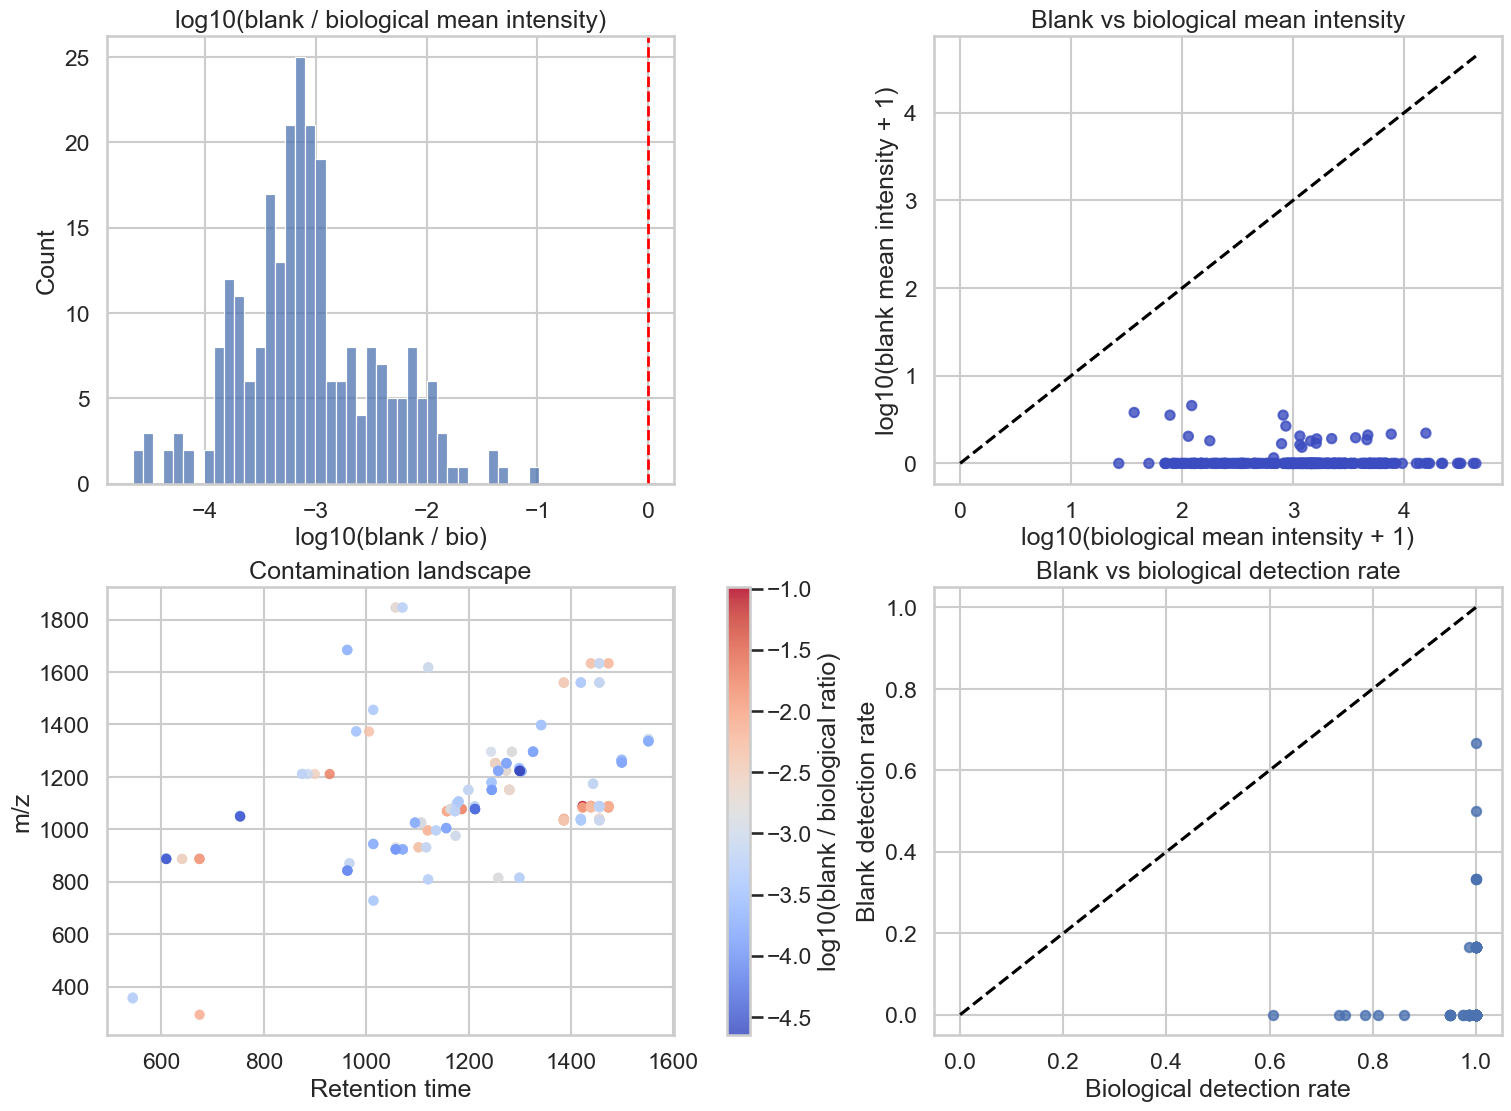

In [34]:
fig = plot_contamination_overview(batch1_contamination_metrics)
plt.show()

## Batch-1 operational Step 8 — technical versus biological variance

We recompute the technical-vs-biological variability summaries using batch 1 `QC` / `dQC` as the technical reference and batch 1 `Dunn`, `French`, `LMU` samples as the biological reference.

These outputs will be used as the operational basis for downstream feature filtering.

In [35]:
batch1_technical_biological_metrics = compute_technical_biological_metrics(
    data_matrix=batch1_data_matrix,
    acquisition_list=batch1_acquisition_list,
    feature_metadata=feature_metadata,
    qc_feature_metrics=batch1_qc_feature_metrics,
)

batch1_acceptance_counts = compute_acceptance_counts(
    technical_biological_metrics=batch1_technical_biological_metrics,
    qc_thresholds=(20.0, 30.0, 40.0),
    d_ratio_thresholds=(0.5, 0.75, 1.0, 1.25),
    detection_thresholds=(0.5, 0.7, 0.9),
    mz_min=500.0,
)

display(batch1_technical_biological_metrics.head(20))
display(
    batch1_technical_biological_metrics.sort_values("d_ratio_log", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(
    batch1_technical_biological_metrics.sort_values("qc_cv_pct", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(batch1_acceptance_counts)

,feature,qc_mean_intensity,qc_cv_pct,qc_detection_rate,qc_order_spearman_rho,qc_order_spearman_abs,mz,rt,qc_log_sd,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,Dunn_detection_rate,French_mean_intensity,French_std_intensity,French_cv_pct,French_log_sd,French_detection_rate,LMU_mean_intensity,LMU_std_intensity,LMU_cv_pct,LMU_log_sd,LMU_detection_rate,bio_cv_pct_median,bio_cv_pct_max,bio_log_sd_median,bio_detection_rate_median,bio_detection_rate_min,d_ratio_cv,d_ratio_log,passes_qc_cv_30,passes_detection_70,passes_mz_500,passes_basic_part_b_screen
0,FT-118,1217.939933,30.773850,1.0000,0.055882,0.055882,1560.001794,1455.408862,0.432526,1292.254531,338.413583,26.187843,1.270994,1.000000,1013.206477,191.802206,18.930219,0.220218,1.0,1146.353213,487.506041,42.526687,1.671517,0.961538,26.187843,42.526687,1.270994,1.000000,0.961538,1.175120,0.340306,False,True,True,False
1,FT-188,78.814777,30.273342,1.0000,0.247059,0.247059,931.123316,1102.187969,0.313227,153.373854,282.512535,184.198628,0.591367,1.000000,360.948334,635.399220,176.036059,1.352206,1.0,204.009392,337.470041,165.418875,0.882706,1.000000,176.036059,184.198628,0.882706,1.000000,1.000000,0.171972,0.354849,False,True,True,False
2,FT-214,724.315160,30.579788,1.0000,0.020588,0.020588,1560.510688,1455.278519,0.465985,770.276304,211.188307,27.417215,1.295855,0.962963,625.432052,112.531952,17.992674,0.202083,1.0,722.144328,223.438560,30.940984,1.083724,1.000000,27.417215,30.940984,1.083724,1.000000,0.962963,1.115350,0.429985,False,True,True,False
3,FT-217,115.946752,23.936714,1.0000,-0.185294,0.185294,1089.028799,1473.438882,0.241677,109.456430,32.717332,29.890736,0.307383,1.000000,112.397574,178.924855,159.189249,0.577091,1.0,163.519598,204.238496,124.901540,0.528579,1.000000,124.901540,159.189249,0.528579,1.000000,1.000000,0.191645,0.457221,True,True,True,True
4,FT-180,403.615401,48.373532,1.0000,0.335294,0.335294,1846.271291,1057.533399,0.831123,541.136000,208.484448,38.527181,1.397225,0.962963,469.566460,160.252446,34.127746,0.563251,1.0,328.003821,174.576223,53.223838,1.976784,0.884615,38.527181,53.223838,1.397225,0.962963,0.884615,1.255569,0.594839,False,True,True,False
5,FT-247,1464.074230,37.887163,1.0000,-0.258824,0.258824,1210.823728,886.037193,0.608324,926.091341,230.998962,24.943432,0.227037,1.000000,1413.395827,649.354852,45.942887,0.953990,1.0,1447.587232,623.861695,43.096656,1.080771,1.000000,43.096656,45.942887,0.953990,1.000000,1.000000,0.879121,0.637663,False,True,True,False
6,FT-097,7306.008277,53.893080,1.0000,-0.108824,0.108824,1221.782718,1303.388213,0.705368,5826.099807,5134.451276,88.128447,1.035705,1.000000,6642.741861,4895.024142,73.689814,1.001555,1.0,5656.255007,5465.508021,96.627681,1.073433,1.000000,88.128447,96.627681,1.035705,1.000000,1.000000,0.611529,0.681051,False,True,True,False
7,FT-168,4360.541665,14.218347,1.0000,-0.158824,0.158824,1336.326245,1551.287736,0.144779,4228.605097,811.531355,19.191467,0.206962,1.000000,4544.164145,573.141654,12.612697,0.123846,1.0,4226.153285,1065.088415,25.202314,0.565577,1.000000,19.191467,25.202314,0.206962,1.000000,1.000000,0.740868,0.699546,True,True,True,True
8,FT-094,6472.473962,53.872092,1.0000,-0.079412,0.079412,1221.278586,1303.481737,0.731130,5146.338999,4570.016505,88.801311,1.040914,1.000000,5910.014271,4413.152552,74.672452,1.020494,1.0,5054.140190,4953.369232,98.006170,1.113923,1.000000,88.801311,98.006170,1.040914,1.000000,1.000000,0.606659,0.702393,False,True,True,False
9,FT-147,1243.284008,32.204648,1.0000,-0.135294,0.135294,1633.043676,1455.247732,0.943609,990.000591,257.447924,26.004825,1.342014,0.962963,793.604825,191.820098,24.170732,0.398988,1.0,1372.779047,557.996027,40.647184,2.394953,0.884615,26.004825,40.647184,1.342014,0.962963,0.884615,1.238410,0.703129,False,True,True,False


,feature,qc_mean_intensity,qc_cv_pct,qc_detection_rate,qc_order_spearman_rho,qc_order_spearman_abs,mz,rt,qc_log_sd,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,Dunn_detection_rate,French_mean_intensity,French_std_intensity,French_cv_pct,French_log_sd,French_detection_rate,LMU_mean_intensity,LMU_std_intensity,LMU_cv_pct,LMU_log_sd,LMU_detection_rate,bio_cv_pct_median,bio_cv_pct_max,bio_log_sd_median,bio_detection_rate_median,bio_detection_rate_min,d_ratio_cv,d_ratio_log,passes_qc_cv_30,passes_detection_70,passes_mz_500,passes_basic_part_b_screen
0,FT-246,191.210208,108.471098,0.75,0.352602,0.352602,886.640677,640.780607,2.610644,468.883422,180.034365,38.396402,0.515263,1.0,628.632636,131.300520,20.886685,0.213646,1.0,19.486687,52.870948,271.318297,1.712987,0.423077,38.396402,271.318297,0.515263,1.0,0.423077,2.825033,5.066628,False,False,True,False
1,FT-199,200.389576,167.921484,1.00,0.114706,0.114706,1223.794330,1273.446642,0.823899,166.957149,33.315503,19.954523,0.206503,1.0,145.276921,34.597370,23.814774,0.232189,1.0,381.856435,768.026547,201.129659,1.142319,1.000000,23.814774,201.129659,0.232189,1.0,1.000000,7.051147,3.548392,False,True,True,False
2,FT-109,2167.684235,33.667331,1.00,0.352941,0.352941,1396.899302,1341.797287,0.548609,2553.355199,457.291926,17.909452,0.193243,1.0,2248.066697,266.941389,11.874265,0.117781,1.0,2349.458973,396.337524,16.869310,0.172214,1.000000,16.869310,17.909452,0.172214,1.0,1.000000,1.995774,3.185624,False,True,True,False
3,FT-156,1732.661080,38.268818,1.00,0.273529,0.273529,1560.001369,1419.237135,1.404104,1988.401514,464.982020,23.384715,0.431486,1.0,1868.912320,482.228124,25.802608,0.444973,1.0,1479.586431,630.004312,42.579757,1.728392,0.961538,25.802608,42.579757,0.444973,1.0,0.961538,1.483138,3.155484,False,True,True,False
4,FT-126,113.854181,147.679487,1.00,0.176471,0.176471,1089.358935,1439.054183,0.810136,83.079534,22.353544,26.906198,0.262662,1.0,66.700655,14.095404,21.132332,0.222759,1.0,94.399882,175.054666,185.439496,0.633825,1.000000,26.906198,185.439496,0.262662,1.0,1.000000,5.488679,3.084325,False,True,True,False
5,FT-190,160.336416,52.988034,1.00,0.414706,0.414706,996.159854,1120.079080,0.659587,176.696030,35.705657,20.207391,0.213982,1.0,128.185657,20.615684,16.082676,0.159329,1.0,135.204754,32.374013,23.944434,0.238406,1.000000,20.207391,23.944434,0.213982,1.0,1.000000,2.622211,3.082439,False,True,True,False
6,FT-047,182.788085,52.437011,1.00,0.535294,0.535294,995.656926,1120.178213,0.571536,208.399539,44.566023,21.384895,0.216623,1.0,137.899332,23.060451,16.722670,0.171192,1.0,149.299002,35.157614,23.548459,0.223171,1.000000,21.384895,23.548459,0.216623,1.0,1.000000,2.452058,2.638391,False,True,True,False
7,FT-046,5583.736965,32.021405,1.00,0.600000,0.600000,1004.167127,1156.358765,0.379478,6917.041037,1029.681352,14.886154,0.147754,1.0,7712.581032,751.197877,9.739903,0.096840,1.0,4497.696905,660.852745,14.693136,0.149633,1.000000,14.693136,14.886154,0.147754,1.0,1.000000,2.179344,2.568306,False,True,True,False
8,FT-050,5273.683061,32.144195,1.00,0.588235,0.588235,1004.669624,1156.392579,0.377894,6581.135257,976.598696,14.839365,0.150439,1.0,7323.356624,729.265419,9.958076,0.100053,1.0,4250.654481,631.908308,14.866141,0.151029,1.000000,14.839365,14.866141,0.150439,1.0,1.000000,2.166144,2.511950,False,True,True,False
9,FT-132,183.035962,181.942435,1.00,-0.129412,0.129412,1088.354986,1438.809837,0.803764,117.602807,35.562768,30.239727,0.321753,1.0,92.461580,20.396998,22.059971,0.225203,1.0,90.048999,30.532437,33.906471,0.398620,1.000000,30.239727,33.906471,0.321753,1.0,1.000000,6.016669,2.498073,False,True,True,False


,feature,qc_mean_intensity,qc_cv_pct,qc_detection_rate,qc_order_spearman_rho,qc_order_spearman_abs,mz,rt,qc_log_sd,Dunn_mean_intensity,Dunn_std_intensity,Dunn_cv_pct,Dunn_log_sd,Dunn_detection_rate,French_mean_intensity,French_std_intensity,French_cv_pct,French_log_sd,French_detection_rate,LMU_mean_intensity,LMU_std_intensity,LMU_cv_pct,LMU_log_sd,LMU_detection_rate,bio_cv_pct_median,bio_cv_pct_max,bio_log_sd_median,bio_detection_rate_median,bio_detection_rate_min,d_ratio_cv,d_ratio_log,passes_qc_cv_30,passes_detection_70,passes_mz_500,passes_basic_part_b_screen
0,FT-173,2140.430822,260.047054,0.7500,-0.097780,0.097780,887.645627,639.907400,3.066792,792.283836,3130.176503,395.082716,1.403611,0.962963,252.814094,84.308017,33.347831,0.359735,1.000000,12.772049,19.394674,151.852494,1.720334,0.384615,151.852494,395.082716,1.403611,0.962963,0.384615,1.712498,2.184931,False,False,True,False
1,FT-132,183.035962,181.942435,1.0000,-0.129412,0.129412,1088.354986,1438.809837,0.803764,117.602807,35.562768,30.239727,0.321753,1.000000,92.461580,20.396998,22.059971,0.225203,1.000000,90.048999,30.532437,33.906471,0.398620,1.000000,30.239727,33.906471,0.321753,1.000000,1.000000,6.016669,2.498073,False,True,True,False
2,FT-199,200.389576,167.921484,1.0000,0.114706,0.114706,1223.794330,1273.446642,0.823899,166.957149,33.315503,19.954523,0.206503,1.000000,145.276921,34.597370,23.814774,0.232189,1.000000,381.856435,768.026547,201.129659,1.142319,1.000000,23.814774,201.129659,0.232189,1.000000,1.000000,7.051147,3.548392,False,True,True,False
3,FT-141,888.596981,167.398515,1.0000,0.108824,0.108824,1223.295151,1273.683493,1.289681,429.801504,892.677494,207.695293,0.639740,1.000000,638.583814,1430.458220,224.004772,1.113554,1.000000,946.457216,1637.692557,173.033976,1.264804,1.000000,207.695293,224.004772,1.113554,1.000000,1.000000,0.805981,1.158167,False,True,True,False
4,FT-013,360.905665,158.590271,0.8125,-0.227140,0.227140,1210.827050,899.723393,2.448183,778.958998,315.454966,40.496992,1.523784,0.962963,101.366011,98.631542,97.302381,2.529283,0.615385,145.303086,328.371028,225.990401,2.568833,0.615385,97.302381,225.990401,2.529283,0.615385,0.615385,1.629870,0.967936,False,False,True,False
5,FT-126,113.854181,147.679487,1.0000,0.176471,0.176471,1089.358935,1439.054183,0.810136,83.079534,22.353544,26.906198,0.262662,1.000000,66.700655,14.095404,21.132332,0.222759,1.000000,94.399882,175.054666,185.439496,0.633825,1.000000,26.906198,185.439496,0.262662,1.000000,1.000000,5.488679,3.084325,False,True,True,False
6,FT-174,37.484657,118.221798,0.9375,-0.029412,0.029412,1210.830470,928.694830,1.220053,17.294270,53.963066,312.028582,1.473552,0.629630,97.204163,23.251326,23.920093,0.238938,1.000000,34.369061,60.612707,176.358343,1.912361,0.615385,176.358343,312.028582,1.473552,0.629630,0.615385,0.670350,0.827967,False,False,True,False
7,FT-079,85.729076,117.851727,1.0000,0.376471,0.376471,1077.209362,1186.459409,0.704994,89.287519,24.885817,27.871552,0.313875,1.000000,62.654572,23.916146,38.171429,0.416282,1.000000,78.200788,159.045181,203.380536,0.860746,1.000000,38.171429,203.380536,0.416282,1.000000,1.000000,3.087433,1.693549,False,True,True,False
8,FT-183,385.206653,114.439764,1.0000,0.191176,0.191176,1026.192891,1107.040420,0.786580,372.138148,392.712854,105.528782,0.622422,1.000000,323.009290,368.655251,114.131470,0.641551,1.000000,364.244994,369.435318,101.424954,0.739400,1.000000,105.528782,114.131470,0.641551,1.000000,1.000000,1.084441,1.226060,False,True,True,False
9,FT-246,191.210208,108.471098,0.7500,0.352602,0.352602,886.640677,640.780607,2.610644,468.883422,180.034365,38.396402,0.515263,1.000000,628.632636,131.300520,20.886685,0.213646,1.000000,19.486687,52.870948,271.318297,1.712987,0.423077,38.396402,271.318297,0.515263,1.000000,0.423077,2.825033,5.066628,False,False,True,False


,criterion_type,threshold,n_features
0,qc_cv_threshold,20.00,35
1,qc_cv_threshold,30.00,156
2,qc_cv_threshold,40.00,217
3,d_ratio_log_threshold,0.50,4
4,d_ratio_log_threshold,0.75,11
5,d_ratio_log_threshold,1.00,32
6,d_ratio_log_threshold,1.25,65
7,bio_detection_threshold,0.50,156
8,bio_detection_threshold,0.70,156
9,bio_detection_threshold,0.90,156


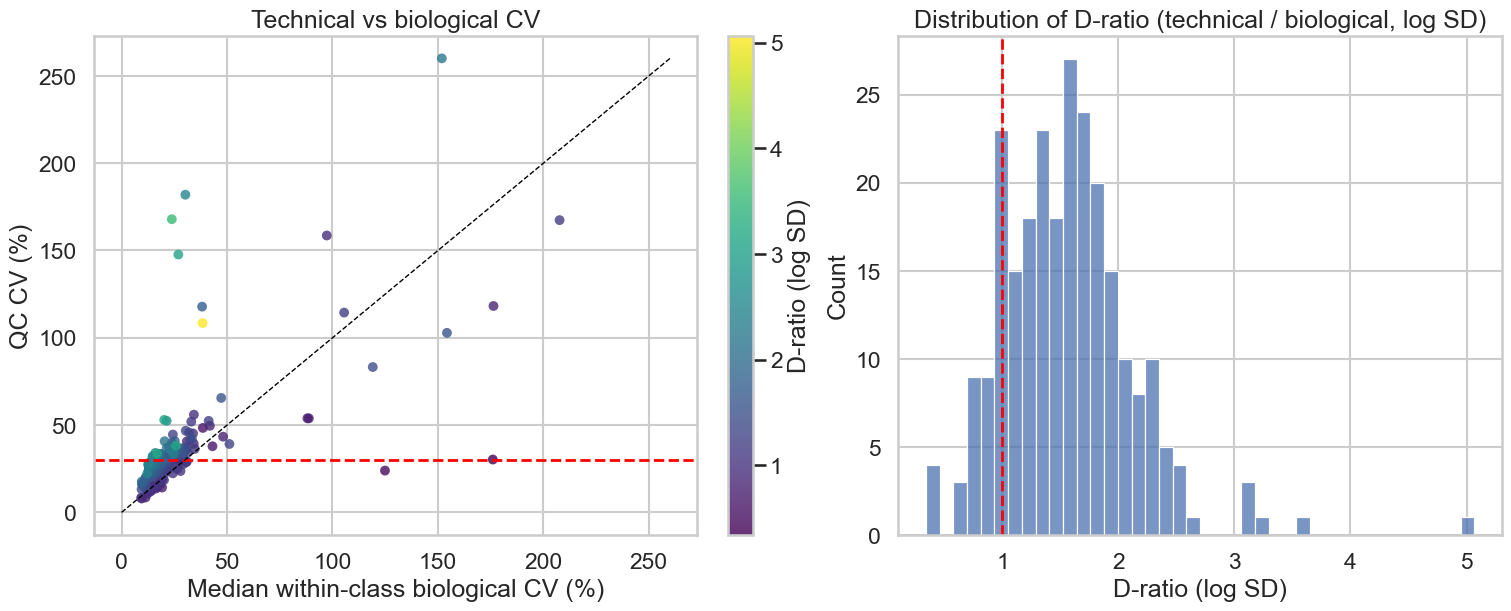

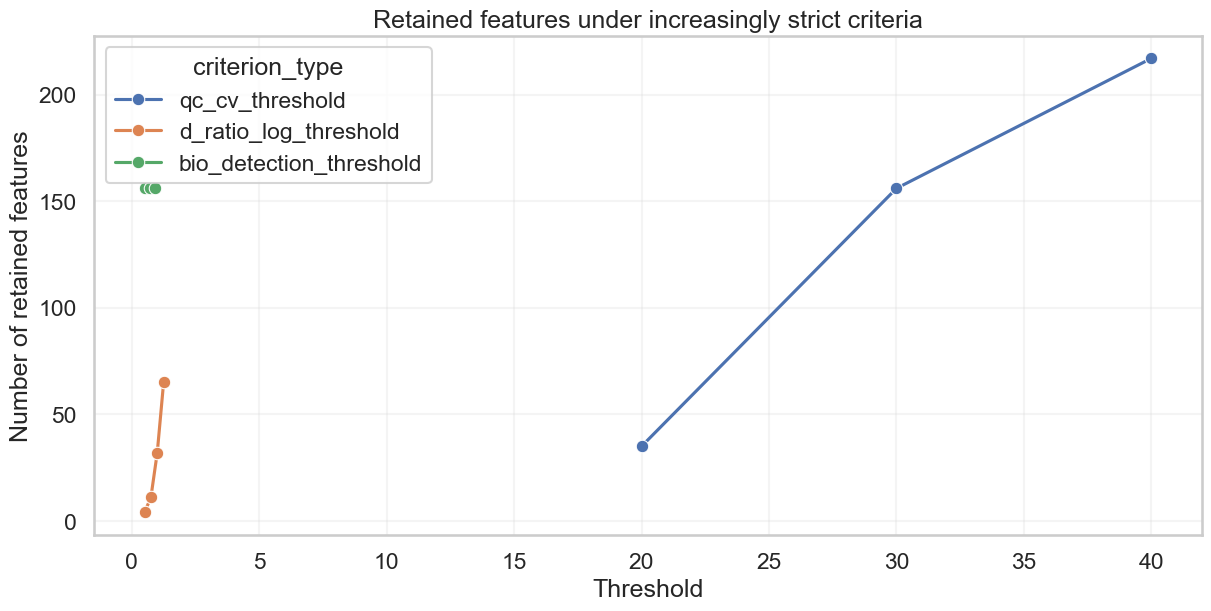

In [36]:
fig = plot_technical_vs_biological_metrics(
    technical_biological_metrics=batch1_technical_biological_metrics,
    qc_cv_threshold=30.0,
)
plt.show()

fig = plot_acceptance_counts(batch1_acceptance_counts)
plt.show()

## Batch-1 operational artifact inventory

The following batch-1-only outputs are the operational EDA artifacts that will feed the downstream feature and sample selection steps.

In [37]:
batch1_operational_artifacts = {
    "batch1_sample_metrics": batch1_sample_metrics,
    "batch1_sample_summary": batch1_sample_summary,
    "batch1_qc_feature_metrics": batch1_qc_feature_metrics,
    "batch1_qc_sample_info": batch1_qc_sample_info,
    "batch1_qc_pca_scores": batch1_qc_pca_scores,
    "batch1_threshold_table": batch1_threshold_table,
    "batch1_feature_detection_metrics": batch1_feature_detection_metrics,
    "batch1_contamination_metrics": batch1_contamination_metrics,
    "batch1_blank_carryover_proxy": batch1_blank_carryover_proxy,
    "batch1_technical_biological_metrics": batch1_technical_biological_metrics,
    "batch1_acceptance_counts": batch1_acceptance_counts,
}

batch1_operational_inventory = pd.DataFrame(
    {
        "artifact": list(batch1_operational_artifacts.keys()),
        "type": [type(v).__name__ for v in batch1_operational_artifacts.values()],
        "n_rows": [len(v) if hasattr(v, "__len__") else np.nan for v in batch1_operational_artifacts.values()],
    }
)

display(batch1_operational_inventory)

,artifact,type,n_rows
0,batch1_sample_metrics,DataFrame,102
1,batch1_sample_summary,DataFrame,7
2,batch1_qc_feature_metrics,DataFrame,252
3,batch1_qc_sample_info,DataFrame,16
4,batch1_qc_pca_scores,DataFrame,16
5,batch1_threshold_table,DataFrame,35
6,batch1_feature_detection_metrics,DataFrame,252
7,batch1_contamination_metrics,DataFrame,252
8,batch1_blank_carryover_proxy,DataFrame,252
9,batch1_technical_biological_metrics,DataFrame,252


## Save batch-1 operational outputs

We save the operational EDA tables to `data/processed/task1_batch1_operational/` so that downstream filtering and modeling can reuse them without recomputing the entire notebook state.

In [39]:
from pathlib import Path

processed_dir = PROJECT_ROOT / "data" / "processed" / "task1_batch1_operational"
processed_dir.mkdir(parents=True, exist_ok=True)

for name, obj in batch1_operational_artifacts.items():
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(processed_dir / f"{name}.csv", index=False)
    elif isinstance(obj, pd.Series):
        obj.to_frame(name="value").to_csv(processed_dir / f"{name}.csv")

print(f"Saved batch-1 operational artifacts to: {processed_dir}")

Saved batch-1 operational artifacts to: C:\Users\zakar\OneDrive\Bureau\ml-internship\data\processed\task1_batch1_operational


### Conclusion of batch-1-only operational rerun

Restricting the exploratory and quality-control analyses to batch 1 substantially improved interpretability. Class-level signal structure, QC behavior, detection support, and contamination patterns are now technically coherent and suitable for downstream processing. In particular, the batch-1 rerun removes the artificial instability introduced by batch 2 and provides a defensible operational basis for Part B filtering.

Two refinements remain before final feature filtering:
1. compute the final QC variability threshold using QC samples only, because dQC samples form a partially distinct diluted subgroup;
2. use a small positive detection threshold (10) rather than 0 to avoid counting trace near-zero signals as detected.

With these refinements, batch 1 is suitable for downstream biomarker discovery.